# Краткий обзор (Executive Summary)

Мы провели оценку эксперимента по внедрению персонализированных скидок (СПП), финансируемых Wildberries, в категории «Джинсы». **Главный вывод: эксперимент признан неудачным с финансовой точки зрения.** Модель машинного обучения, назначавшая скидки, не смогла достичь своей цели — роста выручки.

1. **Общий финансовый результат отрицательный:** Несмотря на то, что техническая часть эксперимента (рандомизация, сбор данных) выполнена корректно, экономика не сошлась. Затраты Wildberries на оплату скидок для покупателей значительно превысили выручку от продаж. Чистый убыток платформы за период эксперимента составил **-290 млн рублей**.
2. **Скидки не влияют на спрос:** В категории «Джинсы» спрос оказался неэластичным. Снижение цены (увеличение скидки) не приводит к значимому росту числа покупок. Люди покупают джинсы, когда они нужны, а не потому что они стали на 5% дешевле.
3. **Лучшая стратегия — не давать скидку:** Наибольшую выручку на одного пользователя показала группа, в которой скидка была **уменьшена на 5%** (группа `5prc_increase`). Рост выручки в этой группе составил всего +1.5% по сравнению с контрольной группой. Этот эффект находится на грани статистической значимости и слишком мал, чтобы окупить затраты на разработку и поддержку модели.
4. **Деньги тратятся впустую:** Почти треть пользователей (28%) в эксперименте вообще ничего не выкупили, но при этом получили скидку. Это прямые убытки. Еще 37% «обычных» покупателей также не увеличили свои траты в ответ на скидки. Каждый вложенный в скидку рубль приносит платформе **убыток в размере 1.1 рубля**.


**Рекомендация:** В текущем виде запускать ML-модель на всю категорию «Джинсы» нельзя — это приведет к прямым убыткам. Мы рекомендуем остановить эксперимент, откатить изменения и пересмотреть подход к управлению скидками для товаров с низкой ценовой эластичностью.

---

### 1. Контекст и цель эксперимента

Мы тестировали гипотезу: если давать некоторым покупателям персональные скидки (СПП) за счет Wildberries, они начнут покупать больше, и итоговая выручка платформы вырастет. Для этого была разработана ML-модель, которая предсказывала оптимальный уровень скидки для каждого пользователя.

Пользователи были разделены на 7 групп: одна контрольная (без изменений) и шесть тестовых, где модель назначала изменение скидки от -5% (уменьшение) до +5% (увеличение) относительно базового уровня.

---
### 2. Ключевые результаты
#### 2.1. Финансовый итог: убыток

Финансовый результат оказался отрицательным.
* **Общая выручка:** 434 млн ₽
* **Общие затраты на СПП:** 725 млн ₽
* **Чистый убыток:** **-291 млн ₽**

Это означает, что на каждый заработанный рубль мы потратили 1.67 рубля на скидки. Эксперимент оказался убыточным для компании.

#### 2.2. Влияние на выручку: эффект не обнаружен

В среднем по всем тестовым группам выручка на пользователя изменилась незначительно (менее чем на 1%) и осталась на уровне контрольной группы. Мы не смогли обнаружить статистически значимого положительного эффекта.

* **Контрольная группа:** 1 627 ₽ на пользователя.
* **Тестовые группы:** от 1 592 ₽ до 1 650 ₽ на пользователя (средняя 1620 ₽).

Даже максимальный прирост (+24 ₽, или +1.5%) оказался ниже минимального порога, который мы можем надежно измерить (MDE = 31 ₽). Это говорит о том, что скидки не являются драйвером роста выручки в этой категории.

#### 2.3. Почему это произошло? (Анализ "размена")

Мы разложили выручку на две составляющие: конверсию (доля купивших) и средний чек.

* **Конверсия** осталась стабильной во всех группах (~70%). Скидки не смогли убедить "сомневающихся" пользователей совершить покупку или вернуть в магазин тех, кто ушел без выкупа.
* **Средний чек** упал там, где давали большие скидки. Это ожидаемо: если мы снижаем цену, люди платят меньше.
* **Итог:** Небольшой рост числа покупателей не смог компенсировать падение среднего чека.

**Простыми словами:** Мы раздали скидки, люди не стали покупать чаще, а те, кто купил, заплатили меньше. В итоге мы потеряли маржинальную прибыль на скидках.

#### 2.4. Почему это произошло? (Эластичность спроса)

Мы построили кривую спроса и оценили эластичность. Коэффициент эластичности составил **-0.38**. Это значит, что снижение цены на 10% приводит к росту спроса только на 3.8%.

**Для категории «Джинсы» это очень низкая чувствительность к цене.** Покупатели не охотятся за скидкой в несколько процентов, чтобы купить джинсы. Их решение о покупке зависит от других факторов.

---

### 3. Сегментный анализ: кому мы давали скидки?

Чтобы понять, можно ли спасти ситуацию, мы разделили пользователей на три кластера по их поведению.

* **Кластер 1: «Невыкупившие» (28%).** Это пользователи, которые создали заказы, но ничего не выкупили. При этом они **получили скидки** (в среднем 1 100 ₽ на человека). Это прямые убытки.  
*Вывод:* Этому сегменту **нельзя давать СПП**. Нет смысла финансировать скидки для пользователей, которые не доводят покупку до конца. Здесь нужны другие механики (например, напоминания или бесплатная примерка).


* **Кластер 2: «Киты» (34%).** Пользователи с очень крупными корзинами, но невысокой конверсией в выкуп. Они получили самые большие скидки (в среднем 4 500 ₽ на человека). Однако их выручка не выросла, а затраты на них — максимальные.     
*Вывод:* Текущий уровень скидок для этого сегмента избыточен. Учитывая их низкую конверсию, возможно, для них важнее другие факторы (например, наличие размера или бренда), а не цена.


* **Кластер 3: «Обычные покупатели» (38%).** Основная масса лояльных покупателей с высокой конверсией. Они получают умеренные скидки (в среднем 1 000 ₽). Их поведение наиболее стабильно, но и они не реагируют ростом трат на скидки.     
*Вывод:* СПП для них — просто подарок, который не окупается.
---

### 4. Рекомендации
1. **Остановить эксперимент и внедрение.** Текущая модель управления скидками для категории «Джинсы» экономически неэффективна и приносит убытки. Необходимо отключить автоматическое назначение повышенных СПП.
2. **Использовать двухкомпонентную модель.** При разработке следующих версий модели необходимо прогнозировать не только размер скидки, но и **вероятность выкупа**. Если модель не уверена, что пользователь купит (кластер 1), не предлагать ему скидку.
3. **Пересмотреть политику скидок для категорий с неэластичным спросом.** Для таких товаров, как «Джинсы», базовая цена и так является "справедливой" в глазах покупателя. Гораздо эффективнее могут быть инструменты, повышающие лояльность без потери маржинальности (например, кешбэк баллами, бесплатная доставка, расширенный ассортимент).
4. **Провести дополнительный анализ.** В данных эксперимента присутствуют пользователи с отрицательными скидками (т.е. с ценой выше базовой). Несмотря на их малое количество, это может указывать на технические ошибки в работе модели, которые также требуют исправления.
---

# Расчеты

#### Библиотеки

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chisquare
from scipy.stats import f_oneway, kruskal
from scipy.stats import shapiro, normaltest, kstest
from scipy.stats import ttest_ind, chisquare
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')


# Настройка стилей
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

#### Загрузка данных и описание задачи

In [9]:
homogenuity = pd.read_parquet('homogenuity.parquet')
mde = pd.read_parquet('mde.parquet')
result = pd.read_parquet('result.parquet')

print('homogenuity:')
display(homogenuity.head(3))
print('mde:')
display(mde.head(3))
print('result:')
display(result.head(3))

homogenuity:


,user_id,grp,bu,parent_name,subject_name,created_orders_cnt,created_items_cnt,created_items_rub,bought_items_cnt,bought_items_rub,...,aiv,aov,upt,age,gender,profit,purchase_percent,purchase_sum,locale,region
0,A2CA63EB39325D4FC044FBFD2CC2FF33,control,Fashion,Одежда,Джинсы,10,10,22950.00,6,10833.75,...,2295.000,2295.000,1.0,<NA>,<NA>,51835198,42,170956900,ru-msk,<NA>
1,8045B13C76AEFFDA8BEBBB6127B06678,control,Fashion,Одежда,Джинсы,4,4,3640.00,2,1820.00,...,910.000,910.000,1.0,<NA>,<NA>,8426101,77,27377000,ru-sfo,<NA>
2,5D2F49AE4BB877B2F852D5C9E17F2E07,1prc_increase,Fashion,Одежда,Джинсы,2,2,2093.75,0,0.00,...,1046.875,1046.875,1.0,<NA>,<NA>,5172215,34,24521400,ru-pfo,<NA>


mde:


,grp,user_id,bu,parent_name,subject_name,orders_sum,gmv_sum,pre_week
0,3prc_decrease,3AA5131827F681CA1569B2C7BD9546FA,Fashion,Одежда,Джинсы,840.00,840.00,5
1,5prc_increase,8269A64F5696B36F1634A90BD4419377,Fashion,Одежда,Джинсы,1783.75,1783.75,7
2,control,921E6DE789878E1BC52FF621B1B86839,Fashion,Одежда,Джинсы,1497.50,0.00,4


result:


,grp,user_id,bu,parent_name,subject_name,created_items_cnt,spp_pct,spp_rub,orders_rub,sales_rub,supplier_price
0,5prc_decrease,2958380FD4A91A445780DE061A44E090,Fashion,Одежда,Джинсы,3,0.301519,2259.375,5643.75,0.000,7653.125
1,5prc_decrease,233982E5C3D7464C299B00605B460E9A,Fashion,Одежда,Джинсы,4,0.357019,5888.750,10742.50,2090.000,16631.250
2,1prc_decrease,EB001560B92FD8EA77C77AAA2F2A12EA,Fashion,Одежда,Джинсы,5,0.322821,1967.500,4281.25,803.125,6085.625


#### homogenuity — данные для проверки, что группы были одинаковыми до начала эксперимента (пол, возраст, регионы и т.д.)
#### mde — исторические данные до эксперимента (нужны, чтобы понять, какой минимальный эффект мы вообще можем обнаружить при таком размере выборки)
#### result — результаты эксперимента (кто сколько купил, с какой скидкой)

Wildberries хочет научиться умнее управлять скидками. Они придумали следующее: давать некоторым покупателям персональные скидки (СПП — Скидка Постоянного Покупателя), которые финансирует сам Wildberries (то есть продавец получает полную цену, а скидку WB даёт из своего кармана).

Чтобы понять, как правильно назначать такие скидки, команда разработала ML-модель, которая должна предсказывать, как изменится спрос при разных уровнях скидки (это и есть "кривые эластичности")

Команда ценообразования сделала:
1. Разделила всех пользователей на 7 групп (1 контрольная и 6 тестовых)
2. Запустила свою ML-модель, которая назначала разный уровень скидок в тестовых группах
3. Собрала данные о покупках
При этом они не делали предварительных статистических проверок — просто хотели набрать данных для обучения модели.

Нам нужно оценить результаты этого эксперимента:

1. Общий эффект — повлияли ли скидки на выручку в целом? Выросла она или упала?
2. Эффект по категориям — хотели посмотреть, какие категории товаров стали основным драйвером изменений
3. Анализ "размена" — понять, в каких категориях можно ещё подкрутить скидки, чтобы увеличить выручку (то есть найти баланс: дать скидку, но не потерять в деньгах)  
!Но так как в данных оказалась одна категория, пункт 2 исчезает (в 3 пункте можно посмотреть зависимости выручки от уровня скидки внутри единственной категории)

#### Ключевая метрика
Нас интересует выручка (sales_rub).   
Но есть нюанс: выручка = конверсия (купил/не купил) × средний чек (сколько потратил, если купил)  
В данных 32.8% пользователей ничего не купили (sales_rub = 0). Значит, скидка может влиять на два канала:
1. Увеличивать вероятность покупки (больше людей решатся купить)
2. Увеличивать сумму чека у тех, кто и так купил

### EDA homogenuity

#### Общая информация о датасете 

Размер датасета: 571,116 строк × 23 столбцов

Типы данных:
user_id               string[python]
grp                   string[python]
bu                    string[python]
parent_name           string[python]
subject_name          string[python]
created_orders_cnt            uint64
created_items_cnt             uint64
created_items_rub            float64
bought_items_cnt              uint64
bought_items_rub             float64
spp_rub                      float64
spp_pct                      float64
order_days_cnt                uint64
aiv                          float64
aov                          float64
upt                          float64
age                             Int8
gender                string[python]
profit                         int64
purchase_percent               int64
purchase_sum                   int64
locale                string[python]
region                string[python]
dtype: object

 Пропущенные значения (только >0):
age       571116
gender    571116
region

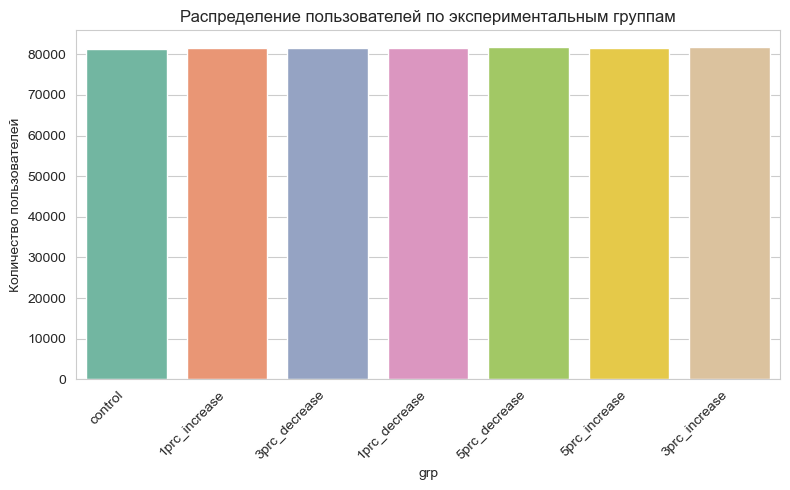

In [13]:
print(f"Размер датасета: {homogenuity.shape[0]:,} строк × {homogenuity.shape[1]} столбцов")
print(f"\nТипы данных:\n{homogenuity.dtypes}")
print(f"\n Пропущенные значения (только >0):")
missing = homogenuity.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "Нет пропусков ✓")

print(f"\nРаспределение пользователей по группам:")
print(homogenuity['grp'].value_counts().to_frame('count').assign(pct=lambda x: round(x['count']/x['count'].sum()*100, 2)))

print(f"\n Базовые статистики числовых метрик (первые 5 колонок):")
print(homogenuity.select_dtypes(include=[np.number]).describe().iloc[:, :5].round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=homogenuity, x='grp', hue='grp', palette='Set2', legend=False)
plt.title('Распределение пользователей по экспериментальным группам')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

In [14]:
homogenuity

,user_id,grp,bu,parent_name,subject_name,created_orders_cnt,created_items_cnt,created_items_rub,bought_items_cnt,bought_items_rub,...,aiv,aov,upt,age,gender,profit,purchase_percent,purchase_sum,locale,region
0,A2CA63EB39325D4FC044FBFD2CC2FF33,control,Fashion,Одежда,Джинсы,10,10,22950.00,6,10833.75,...,2295.000000,2295.000000,1.0,<NA>,<NA>,51835198,42,170956900,ru-msk,<NA>
1,8045B13C76AEFFDA8BEBBB6127B06678,control,Fashion,Одежда,Джинсы,4,4,3640.00,2,1820.00,...,910.000000,910.000000,1.0,<NA>,<NA>,8426101,77,27377000,ru-sfo,<NA>
2,5D2F49AE4BB877B2F852D5C9E17F2E07,1prc_increase,Fashion,Одежда,Джинсы,2,2,2093.75,0,0.00,...,1046.875000,1046.875000,1.0,<NA>,<NA>,5172215,34,24521400,ru-pfo,<NA>
3,5A8A8F7632509EBAA5CB1A672912BB67,3prc_decrease,Fashion,Одежда,Джинсы,10,10,8018.75,4,3050.00,...,801.875000,801.875000,1.0,<NA>,<NA>,29165097,92,418091400,ru-msk,<NA>
4,7EE6C41DABD189F30BBC3760C2A44D4C,3prc_decrease,Fashion,Одежда,Джинсы,16,16,26015.00,0,0.00,...,1625.937500,1625.937500,1.0,<NA>,<NA>,4681909,57,16541800,ru-spb,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571111,80DCA0FD76EB1A36E2E62E00F09BBDCA,control,Fashion,Одежда,Джинсы,2,2,2610.00,0,0.00,...,1305.000000,1305.000000,1.0,<NA>,<NA>,18449181,73,61554200,ru-sfo,<NA>
571112,2F3A90386E84CE5D7489246E57524A45,5prc_increase,Fashion,Одежда,Джинсы,4,4,5478.75,2,3941.25,...,1369.687500,1369.687500,1.0,<NA>,<NA>,6727819,38,30295000,ru-ufo,<NA>
571113,7EEC15824F37EA8B9EE744D0A6A60C0D,3prc_increase,Fashion,Одежда,Джинсы,2,2,2525.00,2,2525.00,...,1262.500000,1262.500000,1.0,<NA>,<NA>,759084,59,3538500,ru-dvfo,<NA>
571114,0F19710A88F4860DC32DFFFF3B22C737,5prc_decrease,Fashion,Одежда,Джинсы,6,6,9978.75,4,6343.75,...,1663.125000,1663.125000,1.0,<NA>,<NA>,1779332,66,8088200,ru-sfo,<NA>


Идеальная рандомизация: все 7 групп распределены равномерно (~14.3% каждая) \
Достаточный объем: ~81K пользователей в каждой группе - хорошая статистическая мощность \
**Проблемы:** \
Полное отсутствие демографии: `age`, `gender`, `region` пропущены у ВСЕХ записей \
Нельзя сделать стратификацию по демографии \
Придется полагаться только на поведенческие метрики \
Сильная асимметрия метрик: \
`created_items_rub`: mean=8,190 vs median=5,411 → long tail (выбросы) \
`bought_items_cnt`: mean=1.54, но min=0 → много нулей (не все заказы выкупаются) \
Низкий выкуп: \
Создано товаров: 5.24 шт на пользователя \
Выкуплено: 1.54 шт → конверсия в выкуп ~29% 

#### Категориальные переменные и проверка на константы


Категориальные колонки (8 шт.):
['user_id', 'grp', 'bu', 'parent_name', 'subject_name', 'gender', 'locale', 'region']

user_id: 571116 уникальных значений (ID пользователей) — пропускаем детальный вывод

 grp:
   Уникальных значений: 7
   Топ-10 значений:
   • 3prc_increase: 81,824 (14.33%)
   • 5prc_decrease: 81,786 (14.32%)
   • 5prc_increase: 81,618 (14.29%)
   • 1prc_increase: 81,551 (14.28%)
   • 3prc_decrease: 81,516 (14.27%)
   • 1prc_decrease: 81,450 (14.26%)
   • control: 81,371 (14.25%)

 bu:
   Уникальных значений: 1
   Топ-10 значений:
   • Fashion: 571,116 (100.00%)

 parent_name:
   Уникальных значений: 1
   Топ-10 значений:
   • Одежда: 571,116 (100.00%)

 subject_name:
   Уникальных значений: 1
   Топ-10 значений:
   • Джинсы: 571,116 (100.00%)

 gender:
   Уникальных значений: 0
Все значения пропущены (NaN)

 locale:
   Уникальных значений: 19
   Топ-10 значений:
   • ru-msk: 113,546 (19.88%)
   • ru-pfo: 94,781 (16.60%)
   • ru-cfo: 77,066 (13.49%)
   • ru-ufo: 66,25

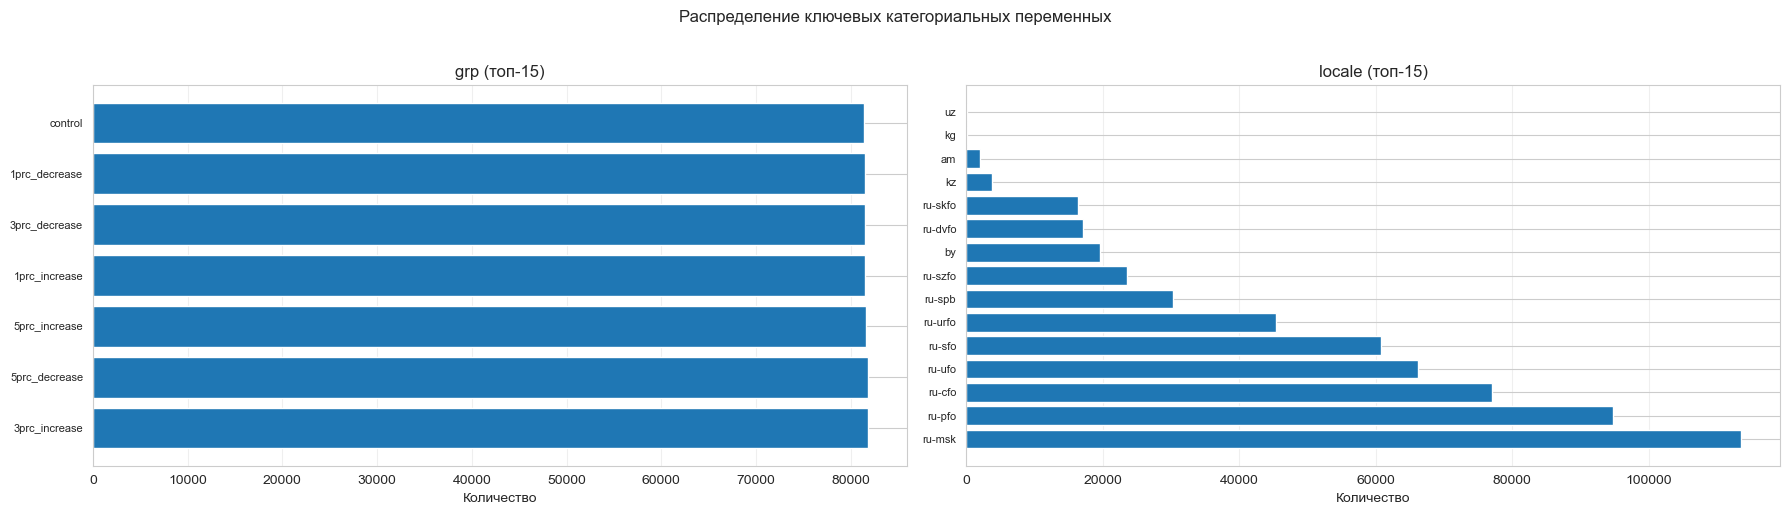

Всего признаков: 23
Категориальных: 8
Числовых: 15
Константных (удалить): 5
С >50% пропусков (удалить): 3


In [17]:
#Выделяем строковые/категориальные колонки
categorical_cols = homogenuity.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
print(f"\nКатегориальные колонки ({len(categorical_cols)} шт.):")
print(categorical_cols)

#Уникальные значения и частоты для каждой категориальной переменной

for col in categorical_cols:
    unique_vals = homogenuity[col].nunique()
    # Для колонок с большим числом уникальных (например, user_id) не выводим все значения
    if unique_vals > 20 and col == 'user_id':
        print(f"\n{col}: {unique_vals} уникальных значений (ID пользователей) — пропускаем детальный вывод")
        continue
        
    top_counts = homogenuity[col].value_counts().head(10)
    print(f"\n {col}:")
    print(f"   Уникальных значений: {unique_vals}")
    if unique_vals > 0:
        print(f"   Топ-10 значений:")
        for val, cnt in top_counts.items():
            pct = cnt / len(homogenuity) * 100
            print(f"   • {val}: {cnt:,} ({pct:.2f}%)")
    else:
        print("Все значения пропущены (NaN)")

# Проверка на константные и низковариативные признаки

constant_cols = []
low_var_cols = []

# Проверка категориальных
for col in categorical_cols:
    n_unique = homogenuity[col].nunique()
    total = len(homogenuity)
    # Если уникальных значений 1 (не считая NaN)
    if n_unique == 1:
        constant_cols.append(col)
        print(f" {col}: КОНСТАНТА (1 уникальное значение) → можно удалить")

# Проверка числовых 
numeric_cols = homogenuity.select_dtypes(include=[np.number]).columns.tolist()
degenerate_numeric = []

for col in numeric_cols:
    # Отбрасываем пропуски для анализа
    non_null = homogenuity[col].dropna()
    
    if len(non_null) == 0:
        print(f" {col}: 100% пропусков → можно удалить")
        constant_cols.append(col)
        continue
        
    n_unique = non_null.nunique()
    
    # Константа: только 1 уникальное не-пропущенное значение
    if n_unique == 1:
        degenerate_numeric.append(col)
        print(f" {col}: только одно значение = {non_null.iloc[0]} → можно удалить")
    # Проверка на нулевую дисперсию (безопасная)
    elif len(non_null) > 1:
        std_val = non_null.std()
        if std_val == 0:
            degenerate_numeric.append(col)
            print(f" {col}: std=0 (все значения одинаковы) → можно удалить")

if not constant_cols and not degenerate_numeric:
    print(" Нет константных или явно низковариативных признаков ✓")

#Визуализация: барплот топ-категорий для ключевых переменных
key_cat_cols = ['grp', 'locale']  # наиболее важные для анализа (bu/parent_name уже знаем что константы)
# Фильтруем только те, что есть в df и не константы
key_cat_cols = [c for c in key_cat_cols if c in homogenuity.columns and c not in constant_cols]

if key_cat_cols:
    fig, axes = plt.subplots(1, len(key_cat_cols), figsize=(18, 5))
    if len(key_cat_cols) == 1:
        axes = [axes]

    for idx, col in enumerate(key_cat_cols):
        top_n = homogenuity[col].value_counts().head(15)
        axes[idx].barh(range(len(top_n)), top_n.values)
        axes[idx].set_yticks(range(len(top_n)))
        axes[idx].set_yticklabels([str(v)[:20] + '...' if len(str(v)) > 20 else str(v) 
                                   for v in top_n.index], fontsize=8)
        axes[idx].set_title(f'{col} (топ-15)')
        axes[idx].set_xlabel('Количество')
        axes[idx].grid(axis='x', alpha=0.3)

    plt.suptitle('Распределение ключевых категориальных переменных', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Нет подходящих категориальных переменных для визуализации")

# Считаем колонки с >50% пропусков
high_missing_cols = [c for c in homogenuity.columns if homogenuity[c].isnull().mean() > 0.5]

summary = {
    'Всего признаков': len(homogenuity.columns),
    'Категориальных': len(categorical_cols),
    'Числовых': len(numeric_cols),
    'Константных (удалить)': len(constant_cols + degenerate_numeric),
    'С >50% пропусков (удалить)': len(high_missing_cols),
}

for k, v in summary.items():
    print(f"{k}: {v}")


**Проблемные признаки: 7 колонок (`bu`, `parent_name`, `subject_name`, `gender`, `region`, `age`, `upt`) являются либо константами, либо имеют 100% пропусков — их следует удалить, так как они не несут аналитической ценности.  \
Единственная полезная категориальная ковариата для сегментации — `locale` (19 регионов), которую можно использовать для проверки однородности групп.**

#### Визуальный анализ метрик и выбросов

Чистый датасет: 15 признаков × 571,116 строк
Признаки: ['grp', 'created_orders_cnt', 'created_items_cnt', 'created_items_rub', 'bought_items_cnt', 'bought_items_rub', 'spp_rub', 'spp_pct', 'order_days_cnt', 'aiv', 'aov', 'profit', 'purchase_percent', 'purchase_sum', 'locale']


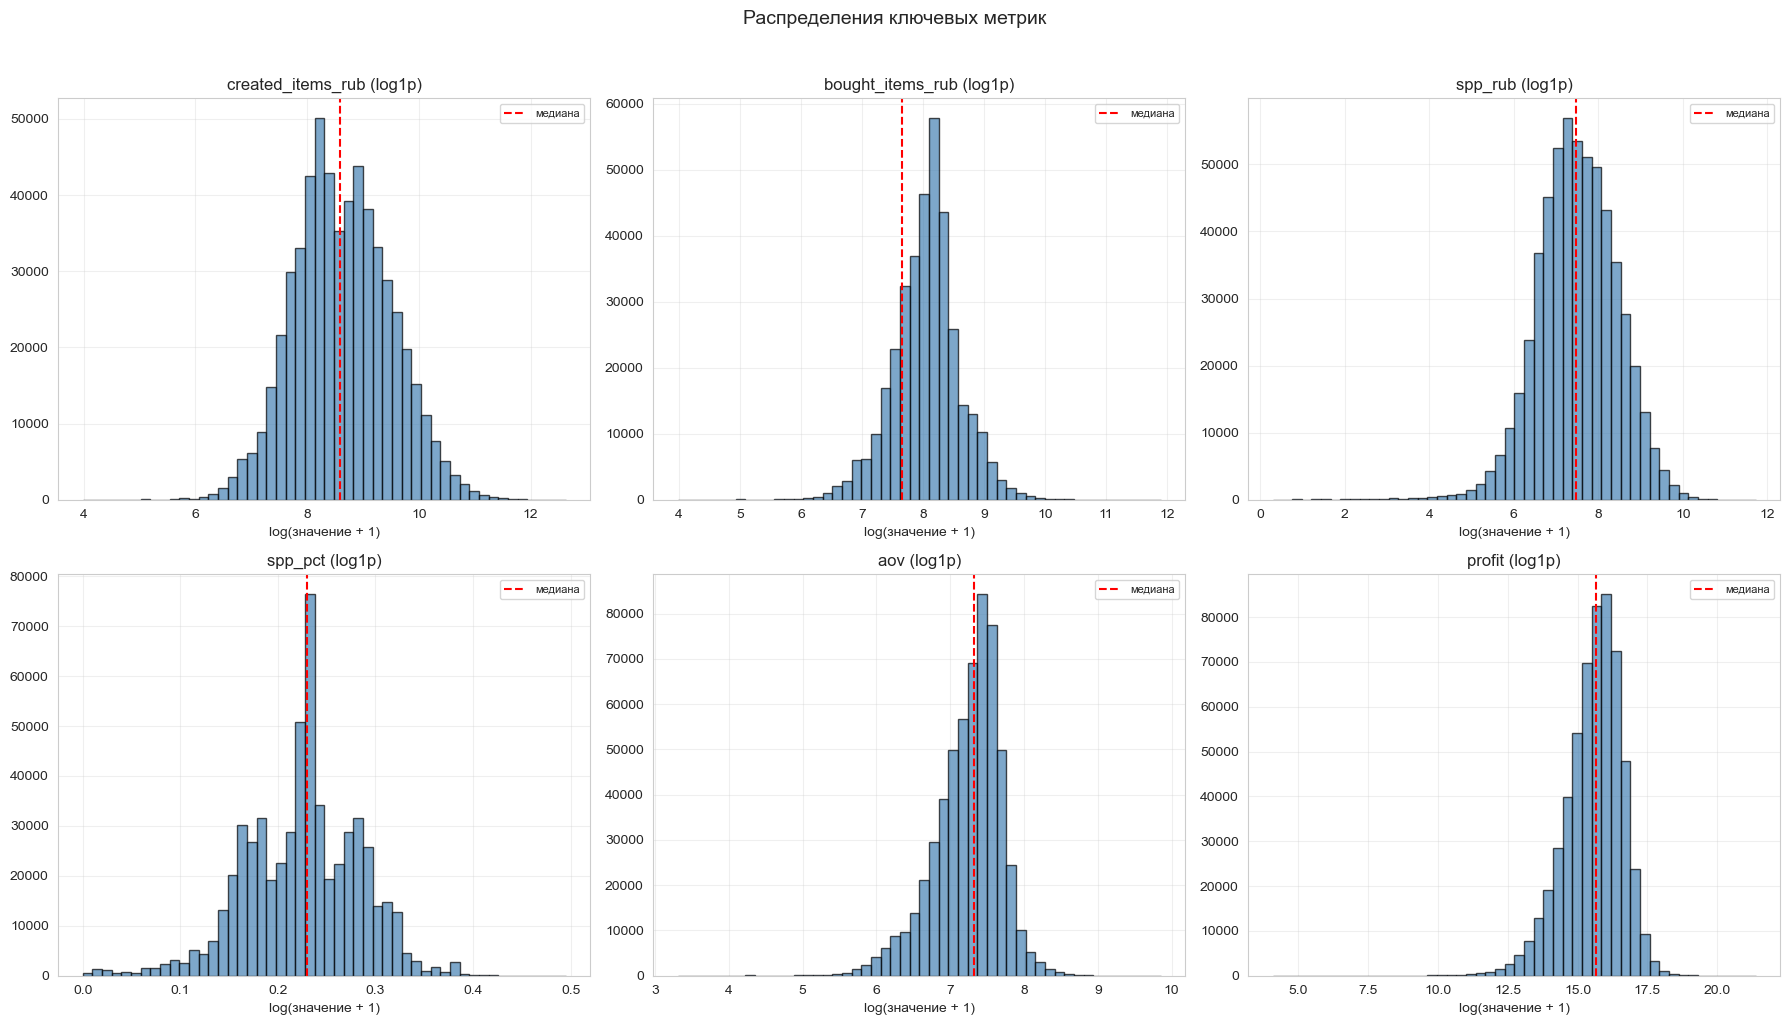

BOXPLOT ПО ЭКСПЕРИМЕНТАЛЬНЫМ ГРУППАМ


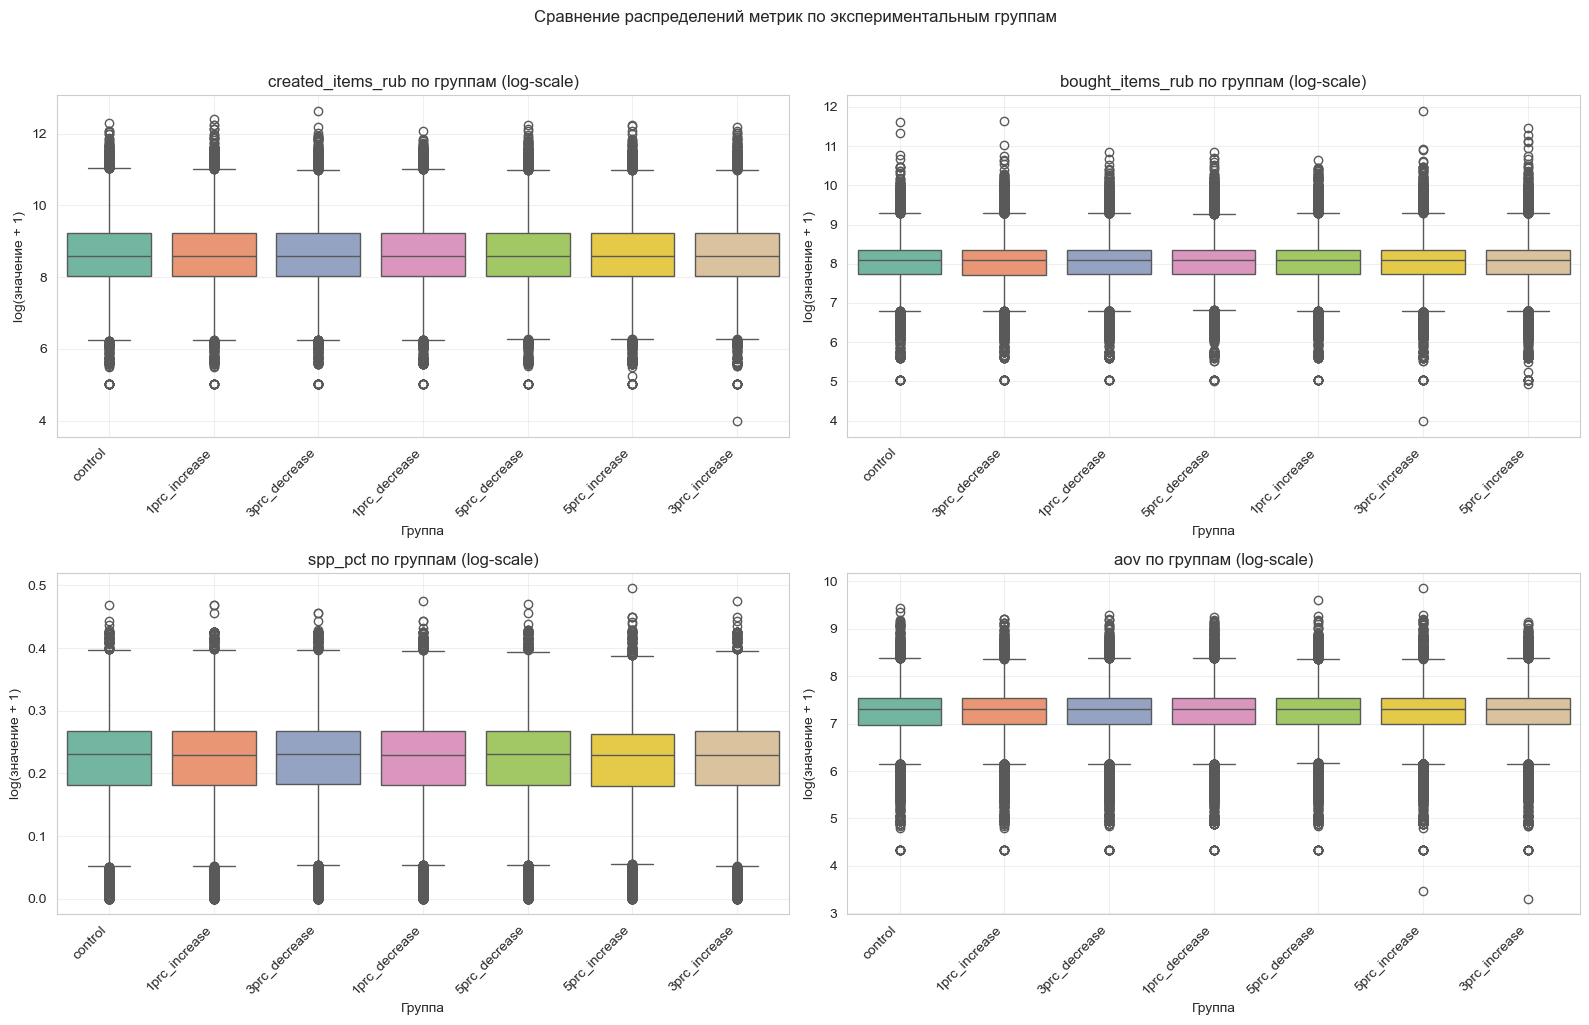

ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ (IQR метод)
           metric         Q1          Q3        IQR  lower_bound  upper_bound  outliers_count  outlier_%    max_value
created_items_rub    3093.75    10130.00    7036.25     -7460.62     20684.38           39851       6.98 3.063588e+05
 bought_items_rub       0.00     3616.25    3616.25     -5424.38      9040.62            9668       1.69 1.469612e+05
          spp_rub     970.00     3396.25    2426.25     -2669.38      7035.62           39130       6.85 1.240775e+05
          spp_pct       0.20        0.31       0.11         0.04         0.47            6115       1.07 6.400000e-01
              aov    1079.79     1884.38     804.58      -127.08      3091.25           10337       1.81 1.902375e+04
           profit 3137135.25 11514795.25 8377660.00  -9429354.75  24081285.25           28144       4.93 1.931399e+09


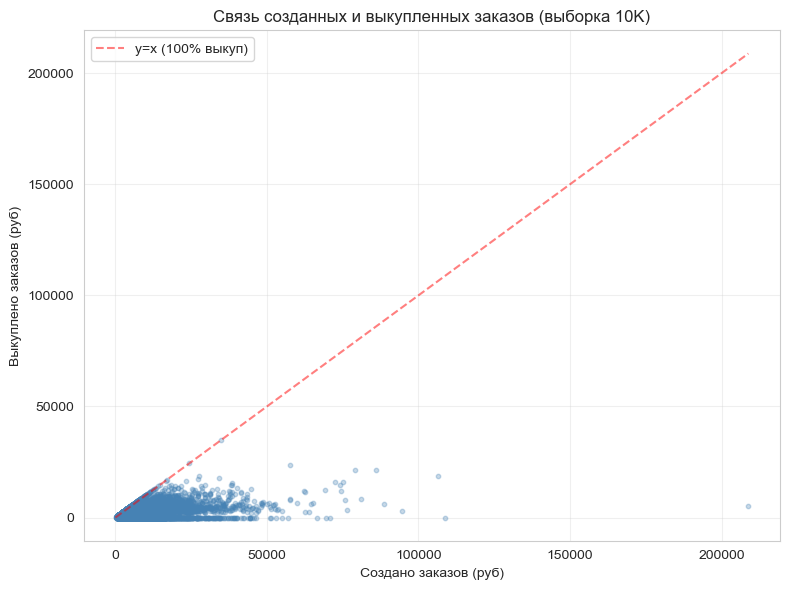


КОРРЕЛЯЦИОННАЯ МАТРИЦА (топ-10 по дисперсии)


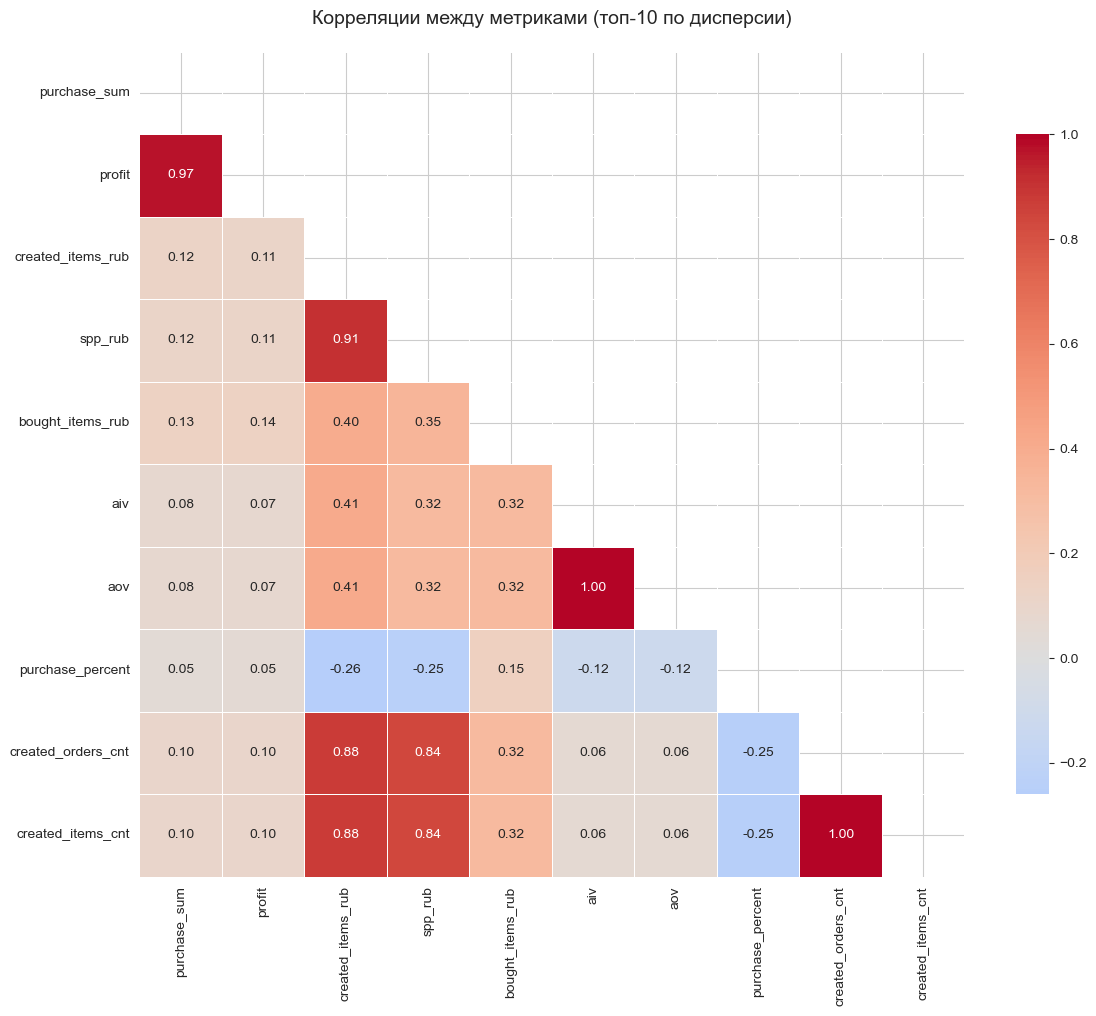


 Ключевые наблюдения:
Топ-5 сильнейших корреляций:
  сильная: aiv ↔ aov = 1.000
  сильная: created_orders_cnt ↔ created_items_cnt = 1.000
  сильная: purchase_sum ↔ profit = 0.974
  сильная: created_items_rub ↔ spp_rub = 0.909
  сильная: created_items_rub ↔ created_orders_cnt = 0.880


In [20]:
#Создаём чистый датасет (удаляем проблемные колонки)
cols_to_drop = ['user_id', 'bu', 'parent_name', 'subject_name', 
                'gender', 'region', 'age', 'upt']
df_clean = homogenuity.drop(columns=[c for c in cols_to_drop if c in homogenuity.columns], errors='ignore')

print(f"Чистый датасет: {df_clean.shape[1]} признаков × {df_clean.shape[0]:,} строк")
print(f"Признаки: {list(df_clean.columns)}")

#Гистограммы ключевых метрик (с логарифмированием для тяжёлых хвостов)

metrics_to_plot = ['created_items_rub', 'bought_items_rub', 'spp_rub', 'spp_pct', 'aov', 'profit']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = df_clean[col].dropna()
    
    # Если много нулей или отрицательных — фильтруем для логарифма
    if (data > 0).sum() > len(data) * 0.5:
        plot_data = np.log1p(data[data > 0])
        ax.hist(plot_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        ax.axvline(np.log1p(data.median()), color='red', linestyle='--', label='медиана')
        ax.set_title(f'{col} (log1p)')
        ax.set_xlabel('log(значение + 1)')
        ax.legend(fontsize=8)
    else:
        # Если много нулей — рисуем обычную гистограмму
        ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        ax.axvline(data.median(), color='red', linestyle='--', label='медиана')
        ax.set_title(f'{col}')
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Распределения ключевых метрик', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("BOXPLOT ПО ЭКСПЕРИМЕНТАЛЬНЫМ ГРУППАМ")


key_metrics = ['created_items_rub', 'bought_items_rub', 'spp_pct', 'aov']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(key_metrics):
    ax = axes[idx]
    plot_df = df_clean[df_clean[metric] > 0].copy()
    
    if len(plot_df) > 0:
        plot_df[f'{metric}_log'] = np.log1p(plot_df[metric])
        
        sns.boxplot(data=plot_df, x='grp', y=f'{metric}_log', 
                    ax=ax, hue='grp', palette='Set2', legend=False)
        
        ax.set_title(f'{metric} по группам (log-scale)')
        ax.set_xlabel('Группа')
        ax.set_ylabel('log(значение + 1)')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.grid(alpha=0.3)

plt.suptitle('Сравнение распределений метрик по экспериментальным группам', y=1.02)
plt.tight_layout()
plt.show()


print("ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ (IQR метод)")


outlier_details = []

for col in metrics_to_plot:
    data = df_clean[col].dropna()
    if len(data) == 0:
        continue
        
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]
    outlier_pct = len(outliers) / len(data) * 100
    
    outlier_details.append({
        'metric': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outliers_count': len(outliers),
        'outlier_%': round(outlier_pct, 2),
        'max_value': round(data.max(), 2)
    })

outlier_df = pd.DataFrame(outlier_details)
print(outlier_df.to_string(index=False))


# Берём подвыборку для скорости
sample = df_clean.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample['created_items_rub'], sample['bought_items_rub'], 
            alpha=0.3, s=10, color='steelblue')
plt.xlabel('Создано заказов (руб)')
plt.ylabel('Выкуплено заказов (руб)')
plt.title('Связь созданных и выкупленных заказов (выборка 10K)')
plt.grid(alpha=0.3)

# Добавляем линию идеальной конверсии (y=x)
max_val = max(sample['created_items_rub'].max(), sample['bought_items_rub'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y=x (100% выкуп)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("КОРРЕЛЯЦИОННАЯ МАТРИЦА (топ-10 по дисперсии)")
print("="*80)

# Выбираем числовые колонки с хорошей вариативностью
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
variances = df_clean[numeric_cols].var()
top_var_cols = variances.nlargest(10).index.tolist()

corr_matrix = df_clean[top_var_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляции между метриками (топ-10 по дисперсии)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n Ключевые наблюдения:")
# Выводим топ-5 сильнейших корреляций
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if not pd.isna(corr):
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print("Топ-5 сильнейших корреляций:")
for col1, col2, val in corr_pairs_sorted[:5]:
    strength = "сильная" if abs(val) > 0.7 else "средняя" if abs(val) > 0.4 else "слабая"
    print(f"  {strength}: {col1} ↔ {col2} = {val:.3f}")

**1. Распределения метрик (Гистограммы)**

Логарифмирование сработало: Большинство финансовых метрик (`created_items_rub`, `profit`, `spp_rub`) после log1p приняли форму, близкую к нормальному распределению. Это хорошо для параметрических тестов (t-test). \
Мультимодальность `spp_pct`: Видны отдельные "пики" (кластеры) на гистограмме процента СПП. Это значит, что скидки выдаются не случайно, а по каким-то правилам/грейдам \
Тяжёлые хвосты: Даже после логарифмирования видны выбросы (особенно в `profit` и `created_items_rub`). \
**2. Однородность групп (Boxplots)** 

Визуально группы идентичны: На всех 4 графиках (`created_items_rub`, `bought_items_rub`, `spp_pct`, `aov`) медианы (черные полоски внутри ящиков) и межквартильные размахи (высота ящиков) практически совпадают для всех 7 групп. \
Вывод: Рандомизация прошла успешно. Нет явных перекосов, где одна группа была бы "богаче" или "активнее" другой. \
**3. Выбросы (Outliers)** 

Финансовые метрики "шумные": 
created_items_rub: ~7% выбросов. \
spp_rub: ~6.85% выбросов. \
profit: ~4.93% выбросов. \
Риск: Пользователи с огромными заказами могут сильно исказить среднее значение (mean). \
**4. Корреляции** 

Полная коллинеарность (1.0): 
`aiv` ↔ `aov` (Средний чек товара = Средний чек заказа). \
`created_orders_cnt` ↔ `created_items_cnt` (Кол-во заказов = Кол-во товаров). \
Причина: Мы ранее выяснили, что upt = 1.0 (в одном заказе ровно 1 товар). \
Действие: Нужно удалить дубли (`aiv`, `created_items_cnt`), чтобы не засорять модель. \
Сильная связь (0.97): `purchase_sum` ↔ `profit`. Прибыль почти линейно зависит от суммы выкупа. Можно использовать одну из них как целевую. \
Сильная связь (0.91): `created_items_rub` ↔ `spp_rub`. Чем больше заказ, тем больше абсолютная скидка. \
**5. Воронка (Scatter Plot)** 

Низкий выкуп: Большинство точек лежит далеко ниже линии y=x. Это подтверждает низкую конверсию в выкуп (~29%). \
Проблемные заказы: Есть точки с большим created (по оси X), но нулевым bought (по оси Y). Это заказы, которые создали, но не выкупили (отмены/возвраты). 

In [22]:
#Проверка: выкуплено ≤ создано
df_clean = homogenuity.drop(columns=[c for c in ['user_id', 'bu', 'parent_name', 'subject_name', 
                                         'gender', 'region', 'age', 'upt', 'aiv'] 
                           if c in homogenuity.columns], errors='ignore')

checks = {}

# bought_items_cnt <= created_items_cnt
checks['bought <= created (cnt)'] = (df_clean['bought_items_cnt'] <= df_clean['created_items_cnt']).mean() * 100

# bought_items_rub <= created_items_rub (с небольшим допуском на округление)
checks['bought <= created (rub)'] = (df_clean['bought_items_rub'] <= df_clean['created_items_rub'] * 1.01).mean() * 100

# spp_rub >= 0 и spp_pct в [0, 100]
checks['spp_rub >= 0'] = (df_clean['spp_rub'] >= 0).mean() * 100
checks['spp_pct in [0,100]'] = ((df_clean['spp_pct'] >= 0) & (df_clean['spp_pct'] <= 100)).mean() * 100

# profit логичен (не экстремально отрицательный)
checks['profit > -1e6'] = (df_clean['profit'] > -1e6).mean() * 100

print("Доля записей, проходящих проверки:")
for check, pct in checks.items():
    print(f"{check}: {pct:.2f}%")

#Поиск дубликатов по user_id + grp
if 'user_id' in homogenuity.columns and 'grp' in homogenuity.columns:
    dups = homogenuity.groupby(['user_id', 'grp']).size()
    n_dups = (dups > 1).sum()
    print(f"\nДубликаты (один пользователь в одной группе >1 раза): {n_dups}")

Доля записей, проходящих проверки:
bought <= created (cnt): 100.00%
bought <= created (rub): 100.00%
spp_rub >= 0: 99.92%
spp_pct in [0,100]: 99.92%
profit > -1e6: 100.00%

Дубликаты (один пользователь в одной группе >1 раза): 0


Данные прошли валидацию: все логические ограничения соблюдаются (99.92-100% записей), дубликаты отсутствуют. \
0.08% записей с аномалиями по spp_rub/spp_pct — присутствуют отрицательные значения

#### Анализ нулей в ключевых метриках

          metric  zero_pct  nonzero_mean  nonzero_median
bought_items_cnt      36.6          2.43             2.0
bought_items_rub      36.6       3631.86          3254.3
          profit       0.0    8834096.85       6435286.0


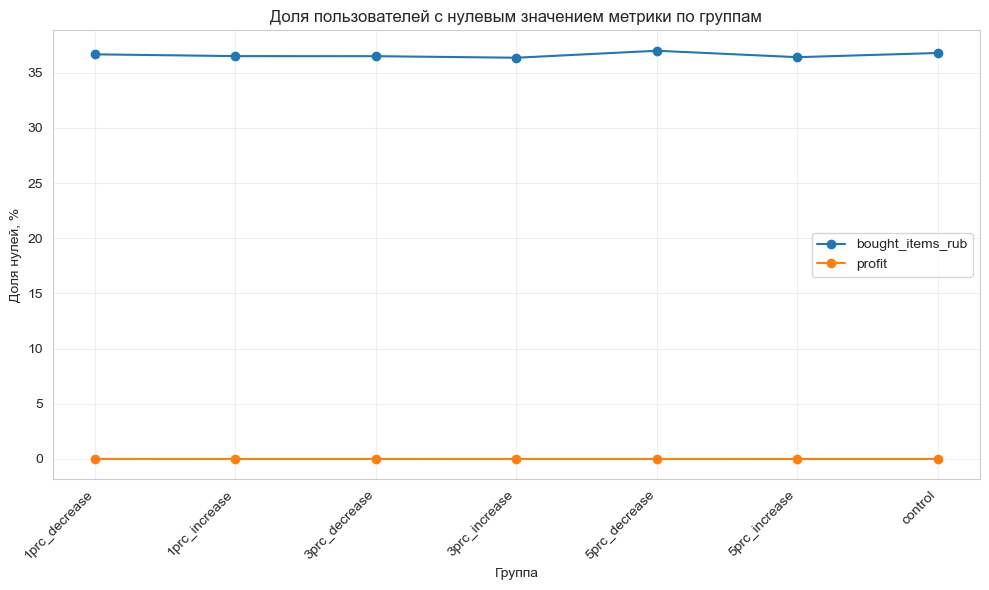

In [25]:
zero_metrics = ['bought_items_cnt', 'bought_items_rub', 'profit']

zero_analysis = []
for col in zero_metrics:
    if col in df_clean.columns:
        zero_pct = (df_clean[col] == 0).mean() * 100
        nonzero = df_clean[df_clean[col] > 0][col]
        zero_analysis.append({
            'metric': col,
            'zero_pct': round(zero_pct, 2),
            'nonzero_mean': round(nonzero.mean(), 2) if len(nonzero) > 0 else np.nan,
            'nonzero_median': round(nonzero.median(), 2) if len(nonzero) > 0 else np.nan
        })

zero_df = pd.DataFrame(zero_analysis)
print(zero_df.to_string(index=False))

# Визуализация: барплот доли нулей по группам
plt.figure(figsize=(10, 6))
for col in ['bought_items_rub', 'profit']:
    if col in df_clean.columns:
        zero_by_grp = df_clean.groupby('grp')[col].apply(lambda x: (x == 0).mean() * 100)
        plt.plot(zero_by_grp.index, zero_by_grp.values, marker='o', label=col)

plt.xlabel('Группа')
plt.ylabel('Доля нулей, %')
plt.title('Доля пользователей с нулевым значением метрики по группам')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Проблема: \
36.6% пользователей НЕ выкупают заказы (`bought_items_rub` = 0) \
Это означает, что у нас двухстадийный процесс: 
- Решение о покупке  
- Сумма покупки (при условии, что покупка состоялась) 

#### Сегментный анализ по locale


 Средние метрики по группам × локалям:

created_items_rub:
grp     1prc_decrease  1prc_increase  3prc_decrease  3prc_increase  5prc_decrease  5prc_increase  control
locale                                                                                                   
ru-cfo        8436.62        8414.35        8447.99        8452.68        8278.05        8361.61  8449.47
ru-msk        9724.13        9882.91        9700.71        9727.24        9802.49        9787.44  9726.03
ru-pfo        7756.72        7852.71        7754.00        7842.17        7856.23        7826.24  7868.52
ru-sfo        7431.62        7330.30        7342.63        7303.59        7196.10        7347.59  7423.81
ru-ufo        7820.82        7647.23        7891.24        7825.53        7960.76        7808.60  7999.17

bought_items_rub:
grp     1prc_decrease  1prc_increase  3prc_decrease  3prc_increase  5prc_decrease  5prc_increase  control
locale                                                                   

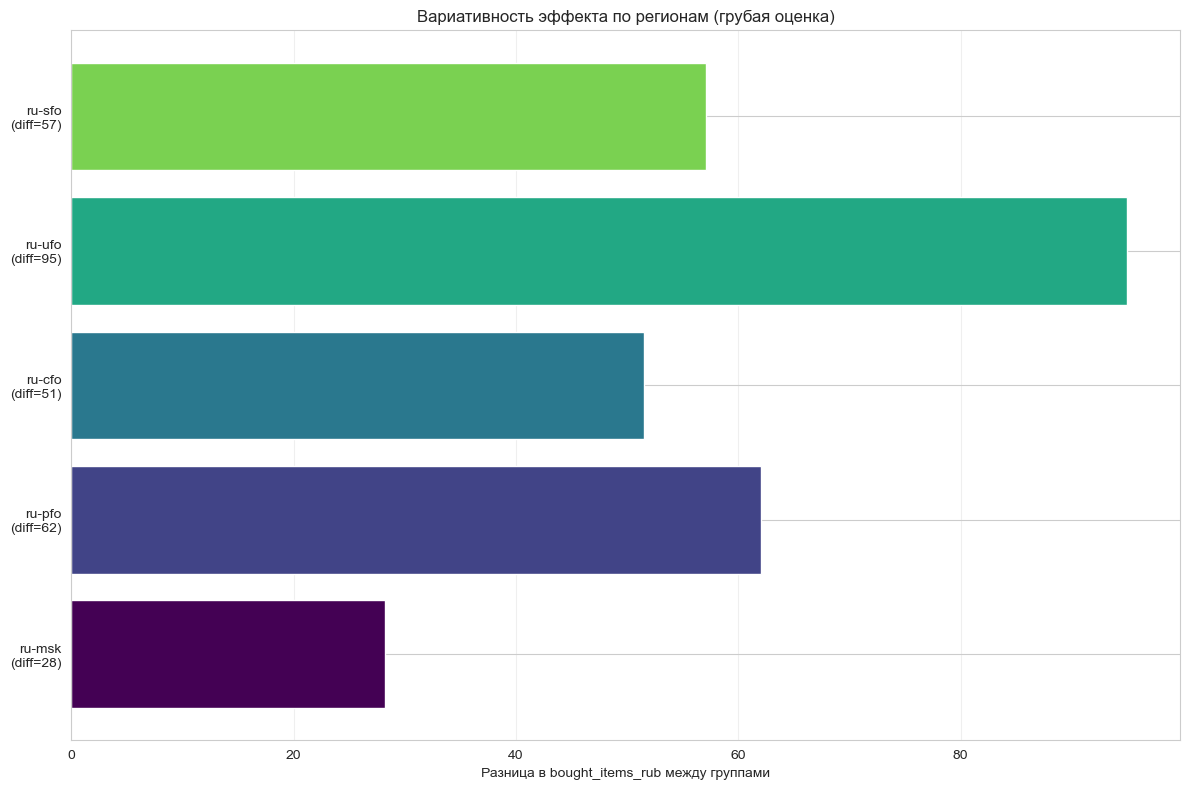

In [28]:
# Топ-5 регионов
top_locales = df_clean['locale'].value_counts().head(5).index.tolist()
df_top = df_clean[df_clean['locale'].isin(top_locales)].copy()

# Ключевые метрики для сравнения
metrics = ['created_items_rub', 'bought_items_rub', 'spp_pct', 'profit']

print("\n Средние метрики по группам × локалям:")
for metric in metrics:
    if metric not in df_top.columns: continue
    pivot = df_top.groupby(['locale', 'grp'])[metric].mean().unstack('grp')
    print(f"\n{metric}:")
    print(pivot.round(2).to_string())

# Визуализация: разница между группами внутри каждого региона
plt.figure(figsize=(12, 8))
for idx, locale in enumerate(top_locales):
    sub = df_top[df_top['locale'] == locale]
    means = sub.groupby('grp')['bought_items_rub'].mean()
    diff = means.max() - means.min()
    plt.barh(f"{locale}\n(diff={diff:.0f})", [diff], color=plt.cm.viridis(idx/len(top_locales)))

plt.xlabel('Разница в bought_items_rub между группами')
plt.title('Вариативность эффекта по регионам (грубая оценка)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


- Группы однородны внутри каждого региона — нет явных перекосов
- Различия между регионами ожидаемые: \
ru-msk (Москва) — highest metrics \
ru-sfo (Сибирь) — lower metrics \

!!! \
`spp_pct` (процент СПП) одинаковый во всех регионах (~0.25-0.27) \
Это значит, что эксперимент корректно применил разные уровни СПП


 Конверсия в выкуп по экспериментальным группам:
               n_users  purchasers  conv_rate  conv_pct
grp                                                    
1prc_decrease    81450       51583       0.63     63.33
1prc_increase    81551       51779       0.63     63.49
3prc_decrease    81516       51762       0.63     63.50
3prc_increase    81824       52072       0.64     63.64
5prc_decrease    81786       51530       0.63     63.01
5prc_increase    81618       51900       0.64     63.59
control          81371       51434       0.63     63.21

Сравнение метрик: выкупившие (1) vs не выкупившие (0):
created_items_rub: не выкупившие=6,902 | выкупившие=8,935 | diff=2,034
spp_pct: не выкупившие=0 | выкупившие=0 | diff=-0
spp_rub: не выкупившие=2,335 | выкупившие=2,935 | diff=600
aov: не выкупившие=1,549 | выкупившие=1,512 | diff=-36
profit: не выкупившие=8,242,952 | выкупившие=9,149,105 | diff=906,153


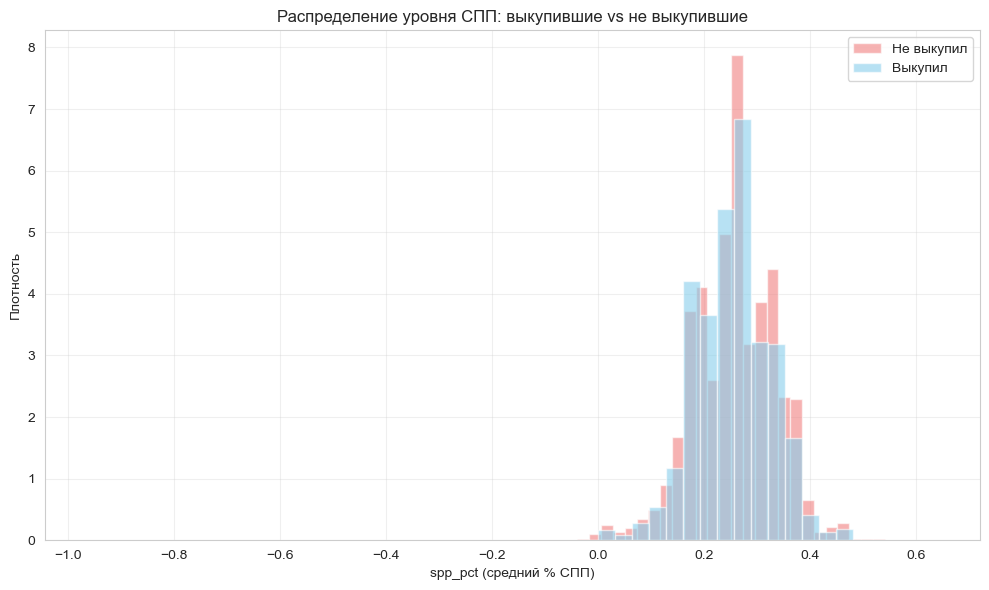


Быстрый чек: какие метрики связаны с вероятностью выкупа?
          feature      coef
created_items_rub  0.312812
              aov -0.188527
   order_days_cnt  0.121576
          spp_pct -0.078289

 Положительный коэффициент = метрика увеличивает вероятность выкупа


In [30]:
# Создаём флаг "выкупил/не выкупил"
df_clean = homogenuity.drop(columns=[c for c in ['user_id', 'bu', 'parent_name', 'subject_name', 
                                         'gender', 'region', 'age', 'upt', 'aiv'] 
                           if c in homogenuity.columns], errors='ignore')
df_clean['purchased'] = (df_clean['bought_items_cnt'] > 0).astype(int)

# 1. Доля выкупивших по группам
print("\n Конверсия в выкуп по экспериментальным группам:")
conv_by_grp = df_clean.groupby('grp').agg(
    n_users=('purchased', 'count'),
    purchasers=('purchased', 'sum'),
    conv_rate=('purchased', 'mean')
).assign(conv_pct=lambda x: x['conv_rate']*100)
print(conv_by_grp.round(2).to_string())

# 2. Сравнение характеристик: выкупившие vs не выкупившие
print("\nСравнение метрик: выкупившие (1) vs не выкупившие (0):")
compare_cols = ['created_items_rub', 'spp_pct', 'spp_rub', 'aov', 'profit']
for col in compare_cols:
    if col in df_clean.columns:
        mean_0 = df_clean[df_clean['purchased']==0][col].mean()
        mean_1 = df_clean[df_clean['purchased']==1][col].mean()
        print(f"{col}: не выкупившие={mean_0:,.0f} | выкупившие={mean_1:,.0f} | diff={mean_1-mean_0:,.0f}")

# 3. Визуализация: распределение spp_pct для двух сегментов
plt.figure(figsize=(10, 6))
for flag, label, color in [(0, 'Не выкупил', 'lightcoral'), (1, 'Выкупил', 'skyblue')]:
    data = df_clean[df_clean['purchased']==flag]['spp_pct'].dropna()
    plt.hist(data, bins=50, alpha=0.6, label=label, color=color, density=True)
plt.xlabel('spp_pct (средний % СПП)')
plt.ylabel('Плотность')
plt.title('Распределение уровня СПП: выкупившие vs не выкупившие')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Логистическая регрессия (быстрый чек): что предсказывает выкуп?
print("\nБыстрый чек: какие метрики связаны с вероятностью выкупа?")
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

feat_cols = [c for c in ['created_items_rub', 'spp_pct', 'aov', 'order_days_cnt'] 
             if c in df_clean.columns and df_clean[c].notna().sum() > 1000]
X = df_clean[feat_cols].dropna()
y = df_clean.loc[X.index, 'purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression(max_iter=1000).fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': feat_cols,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False)
print(coef_df[['feature', 'coef']].to_string(index=False))
print("\n Положительный коэффициент = метрика увеличивает вероятность выкупа")

Во всех группах (и контрольной, и тестовых) доля выкупивших пользователей колеблется в очень узком коридоре 63.21% – 63.64%. \
Разница между контролем и лучшей группой (3prc_increase) составляет всего 0.43 п.п. 

Пользователи, которые выкупили товар, изначально создали заказов на большую сумму (`created_items_rub`: 8,935 vs 6,902). \
Они принесли значительно больше прибыли (`profit`: 9.1M vs 8.2M). 


Изменение уровня скидки (в пределах ±1-5%) не переключает пользователей из состояния "не выкуплю" в "выкуплю". \
Прибыль генерируют те, кто уже готов выкупать. Наша задача — не столько привлечь новых выкупивших, сколько увеличить сумму выкупа у существующих.


#### Насколько "дорого" обходится каждый рубль выручки?


 Стоимость СПП на 1 руб. выручки (медиана по группам):
               count    mean  median     std
grp                                         
1prc_decrease  51583  0.8412  0.5915  0.8214
1prc_increase  51779  0.8434  0.5901  0.8234
3prc_decrease  51762  0.8419  0.5867  0.8253
3prc_increase  52072  0.8449  0.5877  0.8372
5prc_decrease  51530  0.8456  0.5951  0.8464
5prc_increase  51900  0.8363  0.5834  0.8059
control        51434  0.8508  0.5967  0.8344


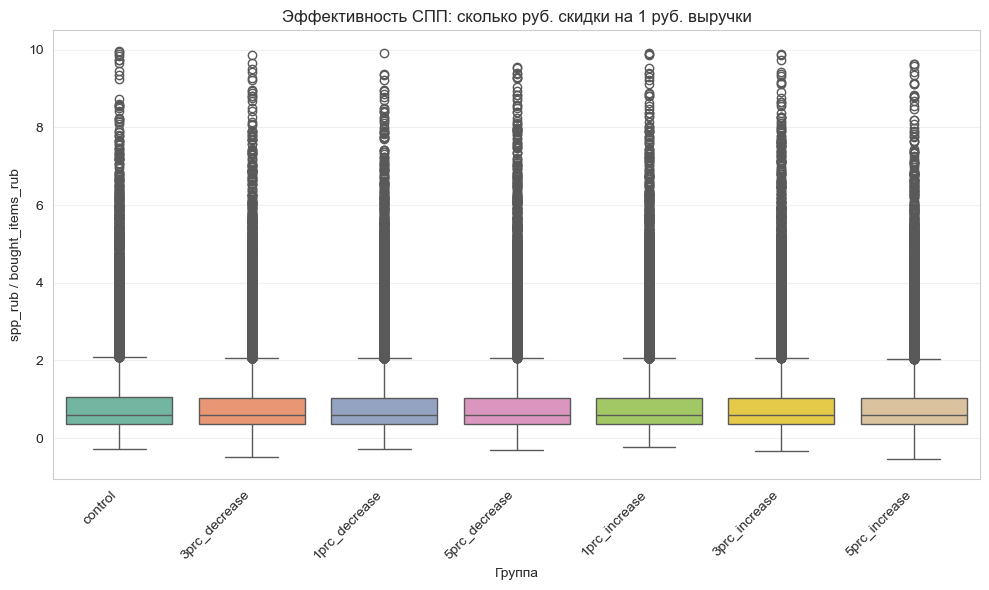


 Корреляции spp_efficiency с ключевыми метриками:
                  corr_with_efficiency
profit                           0.038
purchase_percent                -0.320
aov                              0.014
order_days_cnt                   0.467


In [33]:
# Метрика: spp_rub / bought_items_rub (сколько руб. СПП потрачено на 1 руб. выручки)
df_clean = df_clean.copy()
df_clean['spp_efficiency'] = df_clean['spp_rub'] / df_clean['bought_items_rub'].replace(0, np.nan)

print("\n Стоимость СПП на 1 руб. выручки (медиана по группам):")
eff_by_grp = df_clean.groupby('grp')['spp_efficiency'].agg(['count', 'mean', 'median', 'std'])
print(eff_by_grp.round(4).to_string())

plt.figure(figsize=(10, 6))
df_plot = df_clean[df_clean['spp_efficiency'].notna() & (df_clean['spp_efficiency'] < 10)]  # обрезаем экстремумы
sns.boxplot(data=df_plot, x='grp', y='spp_efficiency', palette='Set2')
plt.xlabel('Группа')
plt.ylabel('spp_rub / bought_items_rub')
plt.title('Эффективность СПП: сколько руб. скидки на 1 руб. выручки')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Корреляция: эффективность СПП с другими метриками
print("\n Корреляции spp_efficiency с ключевыми метриками:")
corr_cols = ['spp_efficiency', 'profit', 'purchase_percent', 'aov', 'order_days_cnt']
corr_df = df_clean[corr_cols].corr().round(3)
print(corr_df['spp_efficiency'].drop('spp_efficiency').to_frame('corr_with_efficiency'))

`spp_rub` / `bought_items_rub` (сколько рублей скидки мы подарили на каждый рубль выручки) \
Средние значения по группам практически идентичны (0.84 – 0.85). Медианы тоже совпадают (~0.59).\
Визуально распределения по всем 7 группам неотличимы. \
Есть экстремальные значения (до 10 руб. скидки на 1 руб. выручки). Это пользователи, которые получили большую скидку, но выкупили очень мало (или вернули товар).

#### Есть ли скрытые сегменты пользователей?

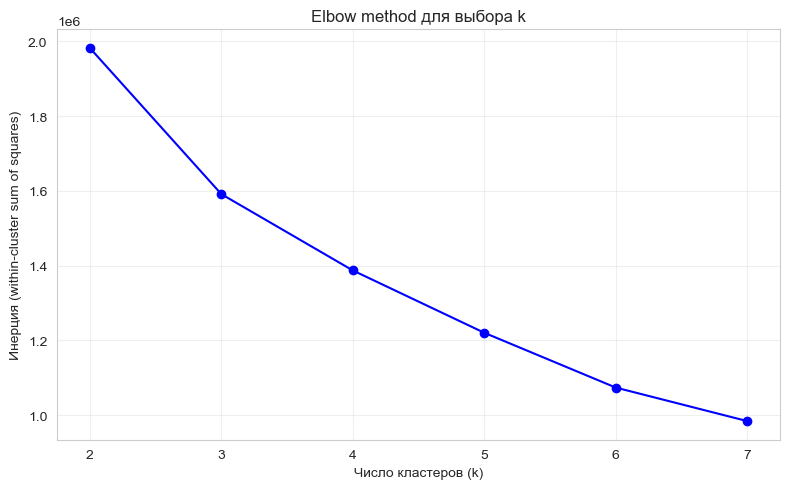


Распределение кластеров по экспериментальным группам:
cluster           0     1     2
grp                            
1prc_decrease  41.4  27.2  31.4
1prc_increase  41.7  27.1  31.2
3prc_decrease  41.8  26.9  31.2
3prc_increase  41.6  27.1  31.2
5prc_decrease  41.2  27.2  31.7
5prc_increase  41.6  27.0  31.4
control        41.1  27.3  31.5

 Профили кластеров (средние значения исходных метрик):
         created_items_rub  bought_items_rub  spp_rub  order_days_cnt      profit
cluster                                                                          
0                   4675.0            3047.0   1519.0             1.0   7832343.0
1                  17309.0            3825.0   5749.0             2.0  11474046.0
2                   4959.0               0.0   1676.0             1.0   7823797.0


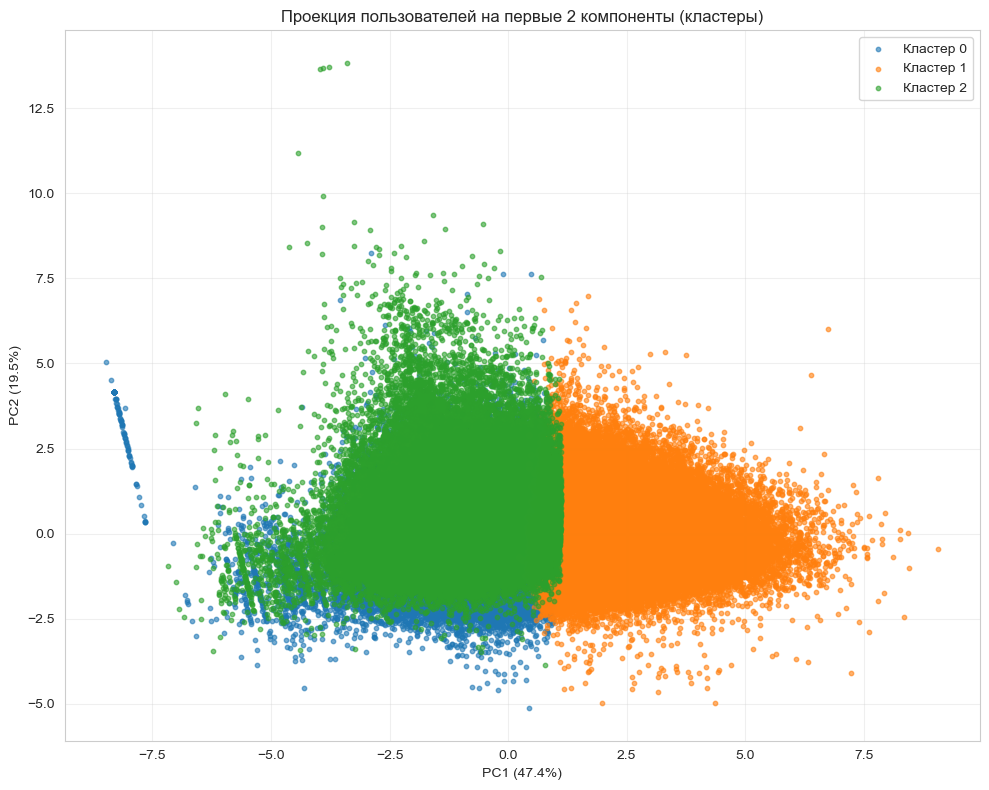

In [36]:
# Выбираем метрики для кластеризации (логарифмируем тяжелые хвосты)
cluster_cols = ['created_items_rub', 'bought_items_rub', 'spp_rub', 'order_days_cnt', 'profit']
df_cluster = df_clean[cluster_cols].dropna().copy()

# Логарифмируем для устойчивости к выбросам
for col in cluster_cols:
    df_cluster[f'{col}_log'] = np.log1p(df_cluster[col].abs())

X_cluster = df_cluster[[f'{c}_log' for c in cluster_cols]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

# Подбираем число кластеров (elbow method)
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(kmeans.fit(X_scaled).inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Инерция (within-cluster sum of squares)')
plt.title('Elbow method для выбора k')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Фитим модель с выбранным k (например, 3)
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# 1. Распределение кластеров по группам эксперимента
print(f"\nРаспределение кластеров по экспериментальным группам:")
cluster_dist = pd.crosstab(df_clean.loc[df_cluster.index, 'grp'], 
                          df_cluster['cluster'], 
                          normalize='index') * 100
print(cluster_dist.round(1).to_string())

# 2. Характеристики кластеров
print(f"\n Профили кластеров (средние значения исходных метрик):")
cluster_profile = df_cluster.groupby('cluster')[cluster_cols].mean()
print(cluster_profile.round(0).to_string())

# 3. Визуализация: PCA для 2D-проекции
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for cl in range(k_opt):
    mask = df_cluster['cluster'] == cl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Кластер {cl}', alpha=0.6, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Проекция пользователей на первые 2 компоненты (кластеры)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. Кластер 0 (41%) — "Обычные покупатели"

- Создано заказов: 4,675 руб. 
- Выкуплено: 3,047 руб. (65% конверсия в выкуп) 
- СПП: 1,519 руб.
- Прибыль: 7.8 млн руб.

2. Кластер 1 (27%) (High-Value Users)

- Создано заказов: 17,309 руб. (в 3.7 раза больше!)
- Выкуплено: 3,825 руб. (низкая конверсия 22% — много отказов)
- СПП: 5,749 руб. (в 3.8 раза больше затрат!)
- Дней с заказами: 2.0 (более активны)
- Прибыль: 11.5 млн руб. (максимальная!)
3. Кластер 2 (32%) — "Невыкупившие" 

- Создано заказов: 4,959 руб.
- Выкуплено: 0.0 руб. (НИ ОДНОГО ВЫКУПА!)
- СПП: 1,676 руб. (потрачены впустую)
- Прибыль: 7.8 млн руб.

#### Проверка однородности групп

In [39]:
cols_to_drop = ['user_id', 'bu', 'parent_name', 'subject_name', 
                'gender', 'region', 'age', 'upt', 'aiv', 'created_items_cnt']
df_clean = homogenuity.drop(columns=[c for c in cols_to_drop if c in homogenuity.columns], errors='ignore')


# SRM 
observed = df_clean['grp'].value_counts()
observed_counts = observed.to_numpy(dtype=float)  
expected = len(df_clean) / len(observed)
expected_counts = [expected] * len(observed)

chi2, p_srm = stats.chisquare(observed_counts, f_exp=expected_counts)
print(f"\nSRM: p-value = {p_srm:.4f} → {'OK' if p_srm > 0.05 else 'ПРОВЕРИТЬ!'}")

# Простая проверка метрик 
key_metrics = ['created_items_rub', 'bought_items_rub', 'spp_pct', 'profit']

print(f"\n Сравнение средних по группам:")
for metric in key_metrics:
    if metric not in df_clean.columns: continue
    means = df_clean.groupby('grp')[metric].mean()
    print(f"{metric}: min={means.min():.2f}, max={means.max():.2f}, diff={means.max()-means.min():.2f}")

# Быстрый t-test/ANOVA 
print(f"\n Простой ANOVA (p-value):")
for metric in key_metrics:
    if metric not in df_clean.columns: continue
    groups = [g[metric].dropna().values for _, g in df_clean.groupby('grp')]
    if all(len(g) > 1 for g in groups):
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"{metric}: p = {p_val:.4f} {'ОК' if p_val > 0.05 else 'НЕ ОК'}")


SRM: p-value = 0.9136 → OK

 Сравнение средних по группам:
created_items_rub: min=8174.03, max=8224.04, diff=50.01
bought_items_rub: min=2282.31, max=2320.21, diff=37.90
spp_pct: min=0.25, max=0.26, diff=0.00
profit: min=8749852.78, max=8892149.30, diff=142296.52

 Простой ANOVA (p-value):
created_items_rub: p = 0.9354 ОК
bought_items_rub: p = 0.0463 НЕ ОК
spp_pct: p = 0.0000 НЕ ОК
profit: p = 0.2148 ОК


Рандомизация прошла корректно (SRM: p=0.91) — пользователи были равномерно распределены по 7 экспериментальным группам, технический сплиттер работает исправно. \
Различия в `spp_pct` и `bought_items_rub` — это не ошибка, а ожидаемый результат: поскольку данные собраны во время эксперимента, группы уже получили разное воздействие (разный уровень СПП), и мы видим проявление эффекта, а не нарушение однородности.

### EDA mde

In [42]:
mde.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030254 entries, 0 to 1030253
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   grp           1030254 non-null  string 
 1   user_id       1030254 non-null  string 
 2   bu            1030254 non-null  string 
 3   parent_name   1030254 non-null  string 
 4   subject_name  1030254 non-null  string 
 5   orders_sum    1030254 non-null  float64
 6   gmv_sum       1030254 non-null  float64
 7   pre_week      1030254 non-null  int64  
dtypes: float64(2), int64(1), string(5)
memory usage: 62.9 MB


пропусков в классическом понимании (NaN) в датасете нет

In [44]:
mde.describe().style.format('{:,.2f}')

,orders_sum,gmv_sum,pre_week
count,"1,030,254.00","1,030,254.00","1,030,254.00"
mean,"6,230.32","1,791.01",3.93
std,"6,046.08","2,125.97",2.19
min,37.50,0.00,1.00
25%,"2,632.50",0.00,2.00
50%,"4,223.75","1,383.75",4.00
75%,"7,716.25","3,189.06",6.00
max,"416,788.75","72,511.25",8.00


grp
1prc_decrease    147021
1prc_increase    146659
3prc_decrease    147123
3prc_increase    147421
5prc_decrease    147564
5prc_increase    147069
control          147397
dtype: int64


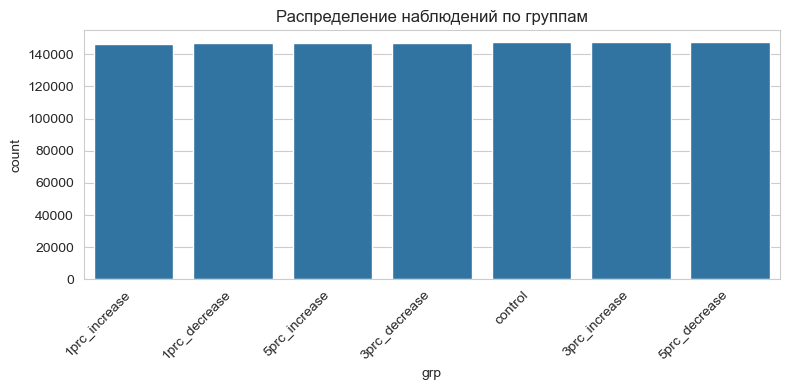

In [45]:
# Размер групп
group_sizes = mde.groupby('grp').size()
print(group_sizes)

# Визуализация
plt.figure(figsize=(8, 4))
sns.countplot(data=mde, x='grp', order=group_sizes.sort_values().index)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение наблюдений по группам')
plt.tight_layout()
plt.show()

Группы равномерно распределены (~147 тыс. записей) 

In [47]:
# Доля нулевых выкупов
zero_buyout = (mde['gmv_sum'] == 0).sum() / len(mde) * 100
print(f"\nДоля заказов без выкупа: {zero_buyout:.1f}%")

buyout_rate = mde.groupby('grp').apply(
    lambda x: (x['gmv_sum'] > 0).mean() * 100
).round(2)
print(f"\nКонверсия в выкуп по группам (%):\n{buyout_rate}")


Доля заказов без выкупа: 45.3%

Конверсия в выкуп по группам (%):
grp
1prc_decrease    54.58
1prc_increase    54.68
3prc_decrease    54.81
3prc_increase    54.82
5prc_decrease    54.43
5prc_increase    54.85
control          54.70
dtype: float64


Доля выкупа стабильна на уровне 54.4–54.8% 

25-й перцентиль `gmv_sum` равен 0, а общая доля заказов без выкупа — 45.3%. Это означает, что почти каждый второй заказ не завершается фактической продажей. Такой паттерн требует двухстадийного подхода к анализу: отдельно моделировать вероятность выкупа и отдельно — размер выкупа при условии, что он произошёл. Игнорирование этой структуры может привести к смещённым оценкам эффекта.

              orders_sum           gmv_sum          pre_week       
                    mean   median     mean   median     mean median
grp                                                                
1prc_decrease    6225.31  4221.25  1789.11  1368.75     3.94    4.0
1prc_increase    6248.11  4231.25  1791.21  1387.50     3.93    4.0
3prc_decrease    6221.60  4211.25  1792.31  1396.25     3.93    4.0
3prc_increase    6232.89  4235.00  1800.33  1396.25     3.93    4.0
5prc_decrease    6217.91  4222.50  1776.25  1360.00     3.93    4.0
5prc_increase    6231.80  4223.75  1801.05  1410.00     3.94    4.0
control          6234.73  4227.50  1786.85  1375.00     3.93    4.0


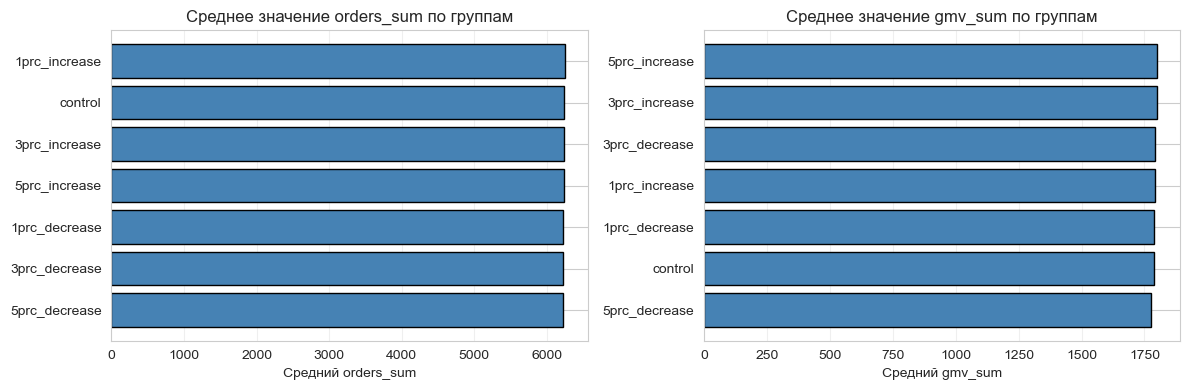

In [49]:
metrics_by_group = mde.groupby('grp')[['orders_sum', 'gmv_sum', 'pre_week']].agg(['mean', 'median']).round(2)
print(metrics_by_group)

# Визуализация средних значений
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, col in enumerate(['orders_sum', 'gmv_sum']):
    agg = mde.groupby('grp')[col].mean().sort_values()
    axes[idx].barh(agg.index, agg.values, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(f'Средний {col}')
    axes[idx].set_title(f'Среднее значение {col} по группам')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Для orders_sum среднее (6,230) почти в 1.5 раза выше медианы (4,224); для gmv_sum разрыв ещё заметнее (1,791 против 1,384). Это указывает на наличие выбросов и длинного правого хвоста. 

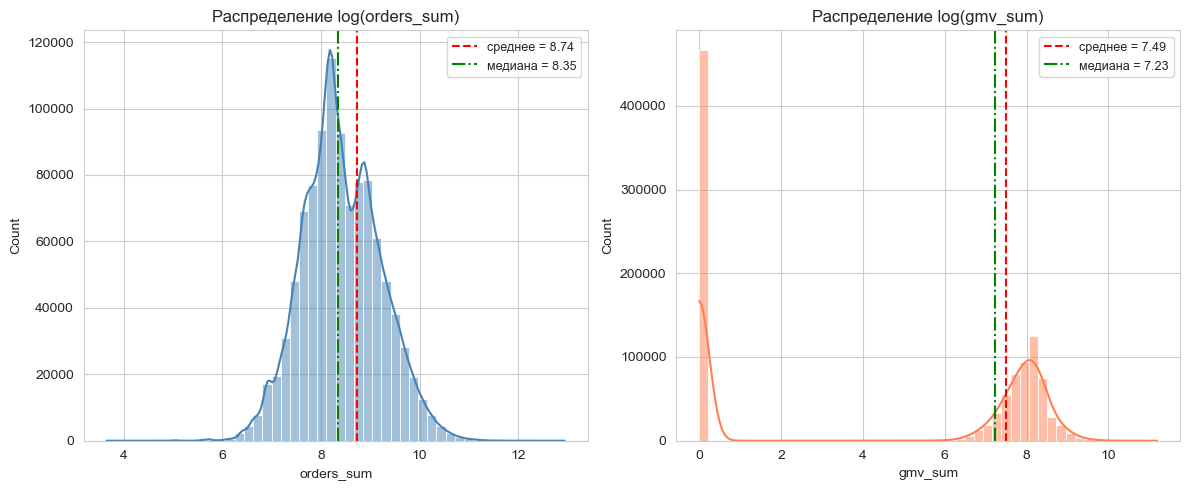

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_orders = np.log1p(mde['orders_sum'])
sns.histplot(data_orders, bins=50, kde=True, ax=axes[0], color='steelblue')
mean_orders = np.log1p(mde['orders_sum'].mean())
median_orders = np.log1p(mde['orders_sum'].median())
axes[0].axvline(mean_orders, color='red', linestyle='--', linewidth=1.5, label=f'среднее = {mean_orders:.2f}')
axes[0].axvline(median_orders, color='green', linestyle='-.', linewidth=1.5, label=f'медиана = {median_orders:.2f}')
axes[0].set_title('Распределение log(orders_sum)')
axes[0].legend(fontsize=9)

data_gmv = np.log1p(mde['gmv_sum'])
sns.histplot(data_gmv, bins=50, kde=True, ax=axes[1], color='coral')
mean_gmv = np.log1p(mde['gmv_sum'].mean())
median_gmv = np.log1p(mde['gmv_sum'].median())
axes[1].axvline(mean_gmv, color='red', linestyle='--', linewidth=1.5, label=f'среднее = {mean_gmv:.2f}')
axes[1].axvline(median_gmv, color='green', linestyle='-.', linewidth=1.5, label=f'медиана = {median_gmv:.2f}')
axes[1].set_title('Распределение log(gmv_sum)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


Корреляционная матрица:
            orders_sum  gmv_sum  pre_week
orders_sum       1.000    0.341    -0.055
gmv_sum          0.341    1.000    -0.008
pre_week        -0.055   -0.008     1.000


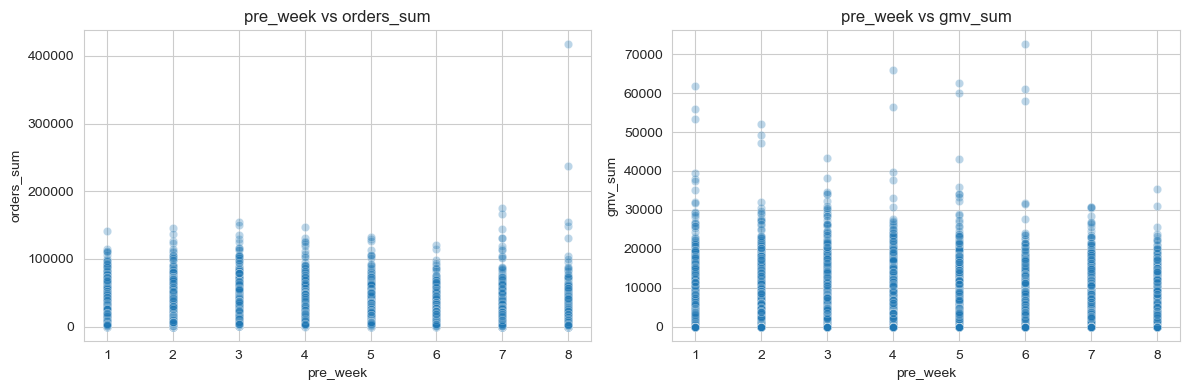

In [52]:
corr = mde[['orders_sum', 'gmv_sum', 'pre_week']].corr()
print(f"\nКорреляционная матрица:\n{corr.round(3)}")

# Scatter plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=mde, x='pre_week', y='orders_sum', alpha=0.3, ax=ax[0])
ax[0].set_title('pre_week vs orders_sum')
sns.scatterplot(data=mde, x='pre_week', y='gmv_sum', alpha=0.3, ax=ax[1])
ax[1].set_title('pre_week vs gmv_sum')
plt.tight_layout()
plt.show()

`pre_week` слабо коррелирует с целевыми метриками. Корреляции -0.055 и -0.008 говорят о том, что эта переменная, вероятно, не является сильным предиктором поведения в эксперименте.

### EDA result

**Новые пользователи исключаются**, так как они:
1. Не участвовали в рандомизации -> нарушают баланс групп
2. Не имеют исторических данных -> нельзя проверить однородность
3. Искажают статистические тесты

In [56]:
users_with_history = homogenuity['user_id'].unique()
print(f"\nПользователей с предысторией: {len(users_with_history):,}")

# Фильтруем result только для этих пользователей
result_clean = result[result['user_id'].isin(users_with_history)].copy()
print(f"Пользователей в result с предысторией: {len(result_clean):,}")
print(f"Исключено новых пользователей: {len(result) - len(result_clean):,}")

# Проверяем, не нарушилась ли структура групп
print("\nРаспределение по группам ДО фильтрации:")
print(result['grp'].value_counts().sort_index())
print("\nРаспределение по группам ПОСЛЕ фильтрации:")
print(result_clean['grp'].value_counts().sort_index())

# Переопределяем result для дальнейшего использования
result = result_clean.copy()


Пользователей с предысторией: 571,116
Пользователей в result с предысторией: 268,176
Исключено новых пользователей: 1,060,703

Распределение по группам ДО фильтрации:
grp
1prc_decrease    191954
1prc_increase    187106
3prc_decrease    196417
3prc_increase    183368
5prc_decrease    201669
5prc_increase    178648
control          189717
Name: count, dtype: Int64

Распределение по группам ПОСЛЕ фильтрации:
grp
1prc_decrease    38588
1prc_increase    37922
3prc_decrease    39310
3prc_increase    37688
5prc_decrease    39459
5prc_increase    36739
control          38470
Name: count, dtype: Int64


In [57]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268176 entries, 2 to 1328872
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   grp                268176 non-null  string 
 1   user_id            268176 non-null  string 
 2   bu                 268176 non-null  string 
 3   parent_name        268176 non-null  string 
 4   subject_name       268176 non-null  string 
 5   created_items_cnt  268176 non-null  uint64 
 6   spp_pct            268176 non-null  float64
 7   spp_rub            268176 non-null  float64
 8   orders_rub         268176 non-null  float64
 9   sales_rub          268176 non-null  float64
 10  supplier_price     268176 non-null  float64
dtypes: float64(5), string(5), uint64(1)
memory usage: 24.6 MB


пропусков в классическом понимании (NaN) в датасете нет

grp
1prc_decrease    38588
1prc_increase    37922
3prc_decrease    39310
3prc_increase    37688
5prc_decrease    39459
5prc_increase    36739
control          38470
dtype: int64


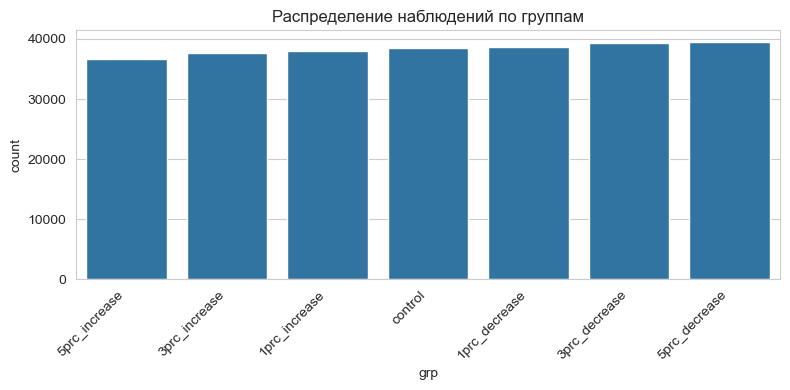

In [59]:
group_sizes = result.groupby('grp').size()
print(group_sizes)


plt.figure(figsize=(8, 4))
sns.countplot(data=result, x='grp', order=group_sizes.sort_values().index)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение наблюдений по группам')
plt.tight_layout()
plt.show()

In [60]:
result.describe().style.format('{:,.2f}')

,created_items_cnt,spp_pct,spp_rub,orders_rub,sales_rub,supplier_price
count,"268,176.00","268,176.00","268,176.00","268,176.00","268,176.00","268,176.00"
mean,4.31,0.29,"2,702.49","6,790.25","1,620.27","9,224.92"
std,4.64,0.07,"3,373.11","8,394.34","1,914.45","11,264.17"
min,1.00,-0.14,-658.68,40.00,0.00,62.50
25%,2.00,0.25,785.62,"2,020.00",0.00,"2,751.11"
50%,3.00,0.29,"1,636.25","4,171.25","1,364.38","5,687.50"
75%,5.00,0.34,"3,346.88","8,383.12","2,200.62","11,407.50"
max,268.00,0.52,"156,126.88","548,447.50","166,834.38","664,311.88"


Есть некоторые интересные моменты:

 - отрицательные значения среднего % спп (`spp_pct`), имеем отрицательные скидки?
 - аналогично для `spp_rub`, требует уточнения
 - для переменной `sales_rub` минимальное значение и 25% процентиль равны нулю, то есть более 25% пользователей не сделали выкуп
 - переменные `orders_rub`, `sales_rub` содержат сильные выбросы

Проведем анализ отрицательных значений в `spp_pct` и `spp_rub`

In [63]:
mask_spp_pct = result['spp_pct'] < 0
mask_spp_rub = result['spp_rub'] < 0
mask_any = mask_spp_pct | mask_spp_rub

In [64]:
summary = {
    'metric': ['spp_pct', 'spp_rub', 'any_negative'],
    'negative_count': [
        mask_spp_pct.sum(),
        mask_spp_rub.sum(),
        mask_any.sum()
    ],
    'negative_pct': [
        mask_spp_pct.mean() * 100,
        mask_spp_rub.mean() * 100,
        mask_any.mean() * 100
    ],
    'min_value': [
        result['spp_pct'].min(),
        result['spp_rub'].min(),
        None
    ],
    'max_negative': [
        result.loc[mask_spp_pct, 'spp_pct'].min(),
        result.loc[mask_spp_rub, 'spp_rub'].min(),
        None
    ]
}
summary_df = pd.DataFrame(summary)
summary_df

,metric,negative_count,negative_pct,min_value,max_negative
0,spp_pct,139,0.051832,-0.140401,-0.140401
1,spp_rub,131,0.048849,-658.681335,-658.681335
2,any_negative,143,0.053323,NaN,NaN


##### Отрицательные значения встречаются в 0.05% записей: 139 случаев для spp_pct (диапазон до −14 п.п.) и 131 случай для spp_rub (диапазон до −659 руб.)

Равномерно ли распределены аномалии или сконцентрированы в определённых группах?

In [67]:
group_distribution = result[mask_any].groupby('grp').agg({
    'user_id': 'count',
    'spp_pct': lambda x: (x < 0).sum(),
    'spp_rub': lambda x: (x < 0).sum()
}).rename(columns={
    'user_id': 'total_records',
    'spp_pct': 'neg_spp_pct_count',
    'spp_rub': 'neg_spp_rub_count'
})


group_sizes = result.groupby('grp')['user_id'].count()
group_distribution['group_total'] = group_sizes
group_distribution['neg_pct_of_group'] = (
    group_distribution['total_records'] / group_distribution['group_total'] * 100
)

print(group_distribution[[
    'total_records', 'group_total', 'neg_pct_of_group',
    'neg_spp_pct_count', 'neg_spp_rub_count'
]].round(2).to_string())

               total_records  group_total  neg_pct_of_group  neg_spp_pct_count  neg_spp_rub_count
grp                                                                                              
1prc_decrease             18        38588              0.05                 18                 17
1prc_increase             16        37922              0.04                 15                 12
3prc_decrease             20        39310              0.05                 19                 20
3prc_increase             21        37688              0.06                 20                 21
5prc_decrease              8        39459              0.02                  8                  6
5prc_increase             41        36739              0.11                 40                 38
control                   19        38470              0.05                 19                 17


Отрицательные значения распределены равномерно по всем группам эксперимента (0.02–0.11% записей в каждой), что свидетельствует об отсутствии систематического смещения 

Выведем 10 примеров записей с отрицательными значениями ради интереса

In [70]:
sample_neg = result[mask_any][[
    'grp', 'user_id', 'subject_name', 'spp_pct', 'spp_rub',
    'orders_rub', 'sales_rub', 'supplier_price'
]].head(10)

sample_neg

,grp,user_id,subject_name,spp_pct,spp_rub,orders_rub,sales_rub,supplier_price
2731,3prc_increase,58217104F7673EB6AFC7652ECBEB7221,Джинсы,-0.016548,-44.706497,5844.393921,2589.175110,5799.687424
3447,3prc_decrease,2BD4758156C5E8D9C5A1914C6EBA87BF,Джинсы,-0.008255,-23.731232,2867.575073,1514.868774,2843.843842
7343,control,EC2391129E5CD5638F6F8DC94B24093F,Джинсы,-0.107140,-658.681335,6807.531281,1743.893738,6148.849945
7803,control,D6E2D770D4FEBA7C80E936ED7483C1FA,Джинсы,-0.123519,-462.956085,4211.012421,0.000000,3748.056335
19853,5prc_increase,F1CE026B75FAD6555A67E1DEB7CFA9E4,Джинсы,-0.005876,-85.881042,17240.231171,439.506264,17154.350128
48752,3prc_decrease,394218D22F1852D775CC8CAD4A454ECE,Джинсы,-0.028151,-30.487442,1113.481216,1113.481216,1082.993774
49458,3prc_increase,05C2D6A81E63CBFED8912C59D122CF8C,Джинсы,0.036289,-37.624969,2749.775009,333.025017,2712.150040
55117,1prc_decrease,A97B5CF628ED18E086920BE85858C994,Джинсы,-0.031935,-51.875000,1708.750000,1708.750000,1624.375000
59693,5prc_increase,22F7C6F2E069F32B3276D77D1B2FF873,Джинсы,-0.007907,15.287590,5545.981216,2083.074989,5561.268806
61150,control,9F6EE91F7E135C3A61898A3703A285DE,Джинсы,-0.107957,-309.993896,3181.456299,0.000000,2871.462402


Примеры подтверждают, что отрицательные значения `spp_pct` и `spp_rub` не образуют однородного паттерна, а представляют собой разнородные технические или корректировочные операции. Их малая доля (0.05%), равномерное распределение по группам и отсутствие систематической связи с ключевыми метриками (`sales_rub`, `orders_rub`) позволяют оставить эти записи в анализе без фильтрации, зафиксировав в отчёте как фоновый технический шум

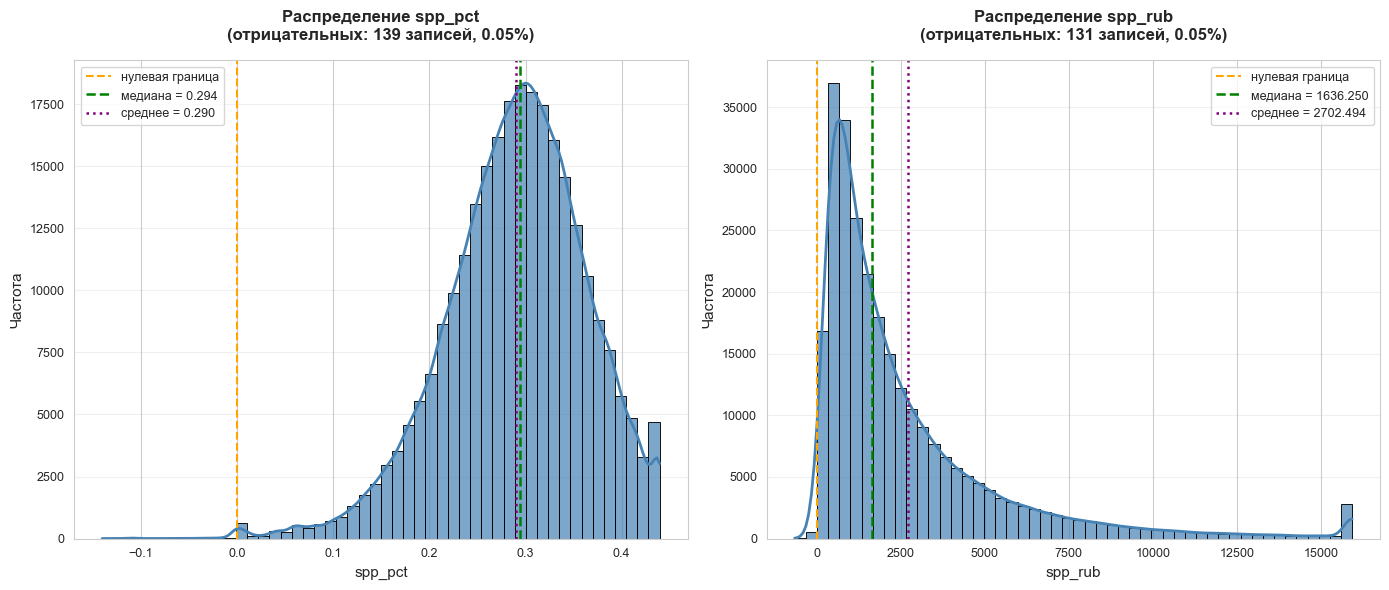

In [72]:
cols_to_plot = ['spp_pct', 'spp_rub']

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    data = result[col].dropna()
    
    # Проверяем наличие отрицательных значений
    neg_count = (data < 0).sum()
    neg_pct = neg_count / len(data) * 100
    
    # Обрезаем выбросы на 1-99 перцентилях для лучшей визуализации
    plot_data = data.clip(upper=data.quantile(0.99))
    
    # Строим гистограмму с KDE
    sns.histplot(
        data=plot_data, 
        bins=50, 
        
        kde=True, 
        ax=ax, 
        color='steelblue', 
        edgecolor='black',
        line_kws={'color': 'darkred', 'linewidth': 2},
        alpha=0.7
    )
    
    # Добавляем вертикальную линию на x=0
    ax.axvline(0, color='orange', linestyle='--', linewidth=1.5, label='нулевая граница')
    
    # Добавляем медиану
    median_val = data.median()
    mean_val = data.mean()
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1.8, label=f'медиана = {median_val:.3f}')
    ax.axvline(mean_val, color='purple', linestyle=':', linewidth=1.8, label=f'среднее = {mean_val:.3f}')
    
    # Оформление
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Частота', fontsize=11)
    ax.set_title(f'Распределение {col}\n(отрицательных: {neg_count:,} записей, {neg_pct:.2f}%)', 
                 fontsize=12, pad=15, fontweight='bold')
    ax.legend(fontsize=9, frameon=True)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()


Теперь перейдем к анализу нулевых значений для переменной `sales_rub`

In [74]:
total_records = len(result)
zero_count = (result['sales_rub'] == 0).sum()
non_zero_count = (result['sales_rub'] > 0).sum()
zero_pct = zero_count / total_records * 100

print(f"Общее количество записей: {total_records:,}")
print(f"Записи с sales_rub = 0: {zero_count:,} ({zero_pct:.1f}%)")
print(f"Записи с sales_rub > 0: {non_zero_count:,} ({100 - zero_pct:.1f}%)")

Общее количество записей: 268,176
Записи с sales_rub = 0: 79,416 (29.6%)
Записи с sales_rub > 0: 188,760 (70.4%)


In [75]:
non_zero_data = result[result['sales_rub'] > 0]['sales_rub']
print("Статистика sales_rub для ненулевых значений:")
print(f"  Среднее: {non_zero_data.mean():,.2f} руб.")
print(f"  Медиана: {non_zero_data.median():,.2f} руб.")
print(f"  Стандартное отклонение: {non_zero_data.std():,.2f} руб.")
print(f"  25-й перцентиль: {non_zero_data.quantile(0.25):,.2f} руб.")
print(f"  75-й перцентиль: {non_zero_data.quantile(0.75):,.2f} руб.")
print(f"  Минимум: {non_zero_data.min():,.2f} руб.")
print(f"  Максимум: {non_zero_data.max():,.2f} руб.")

Статистика sales_rub для ненулевых значений:
  Среднее: 2,301.95 руб.
  Медиана: 1,795.62 руб.
  Стандартное отклонение: 1,907.33 руб.
  25-й перцентиль: 1,284.38 руб.
  75-й перцентиль: 2,740.62 руб.
  Минимум: 45.62 руб.
  Максимум: 166,834.38 руб.


Посмотрим на распределение нулей по группам эксперимента

In [77]:
zero_by_group = result.groupby('grp').agg(
    total_records=('user_id', 'count'),
    zero_count=('sales_rub', lambda x: (x == 0).sum()),
    non_zero_count=('sales_rub', lambda x: (x > 0).sum())
)
zero_by_group['zero_pct'] = zero_by_group['zero_count'] / zero_by_group['total_records'] * 100
zero_by_group['non_zero_pct'] = 100 - zero_by_group['zero_pct']


group_order = ['control', '1prc_increase', '3prc_increase', '5prc_increase',
               '1prc_decrease', '3prc_decrease', '5prc_decrease']
zero_by_group = zero_by_group.reindex([g for g in group_order if g in zero_by_group.index])
zero_by_group

,total_records,zero_count,non_zero_count,zero_pct,non_zero_pct
grp,,,,,
control,38470,11446,27024,29.753054,70.246946
1prc_increase,37922,11283,26639,29.753178,70.246822
3prc_increase,37688,11466,26222,30.423477,69.576523
5prc_increase,36739,11126,25613,30.283894,69.716106
1prc_decrease,38588,11386,27202,29.506582,70.493418
3prc_decrease,39310,11404,27906,29.010430,70.989570
5prc_decrease,39459,11305,28154,28.649991,71.350009


Доля пользователей без выкупа стабильна во всех группах: от 28.64% (`5prc_decrease`) до 30.42% (`3prc_increase`), при этом контрольная группа (29.75%) находится в середине диапазона. Разброс менее 1.8 п.п. подтверждает, что группы сбалансированы по вероятности выкупа, и наблюдаемые различия в выручке с высокой вероятностью обусловлены изменением СПП, а не изначальным дисбалансом выборки

Теперь проведем сравнение метрик для пользователей с нулевым и ненулевым `sales_rub`

In [80]:
result['has_buyout'] = (result['sales_rub'] > 0).astype(int)
comparison_cols = ['orders_rub', 'spp_rub', 'spp_pct', 'created_items_cnt', 'supplier_price']

comparison_stats = result.groupby('has_buyout')[comparison_cols].agg(['mean', 'median']).round(2)
comparison_stats.columns = ['_'.join(col).strip() for col in comparison_stats.columns]
comparison_stats = comparison_stats.rename(index={0: 'zero_sales', 1: 'positive_sales'})

comparison_stats.T

has_buyout,zero_sales,positive_sales
orders_rub_mean,4705.58,7667.33
orders_rub_median,2919.38,4888.12
spp_rub_mean,1812.80,3076.81
spp_rub_median,1101.25,1936.88
spp_pct_mean,0.28,0.29
spp_pct_median,0.29,0.30
created_items_cnt_mean,2.93,4.90
created_items_cnt_median,2.00,3.00
supplier_price_mean,6339.33,10438.96
supplier_price_median,3975.00,6695.62


Пользователи с ненулевым выкупом систематически крупнее: средний чек (`orders_rub`) на 62% выше, количество товаров в заказе на 67% больше, а затраты на СПП на 70% выше, чем у пользователей с нулевым выкупом; при этом уровень скидки (`spp_pct`) различается незначительно (0.28 против 0.29). Это означает, что нулевой выкуп характеризует отдельный сегмент «холодных» пользователей с низким вовлечением, а не случайный шум, и общий эффект изменения СПП складывается из двух каналов: влияния на вероятность выкупа и влияния на размер чека при выкупе

Рассмотрим теперь долю выкупа

In [83]:
result['buyout_rate'] = result.apply(
    lambda row: row['sales_rub'] / row['orders_rub'] if row['orders_rub'] > 0 else 0,
    axis=1
)

buyout_by_group = result.groupby('grp')['buyout_rate'].agg(['mean', 'median']).round(4)
buyout_by_group = buyout_by_group.reindex([g for g in group_order if g in buyout_by_group.index])

buyout_by_group

,mean,median
grp,,
control,0.3487,0.2580
1prc_increase,0.3498,0.2585
3prc_increase,0.3483,0.2552
5prc_increase,0.3465,0.2532
1prc_decrease,0.3502,0.2581
3prc_decrease,0.3534,0.2640
5prc_decrease,0.3557,0.2636


Доля выкупа (отношение стоимости выкупленных товаров к стоимости заказов) стабильна во всех группах эксперимента и варьируется в диапазоне 0.348–0.356, что указывает на слабую реакцию поведения пользователей по признаку завершения сделки на изменение уровня СПП

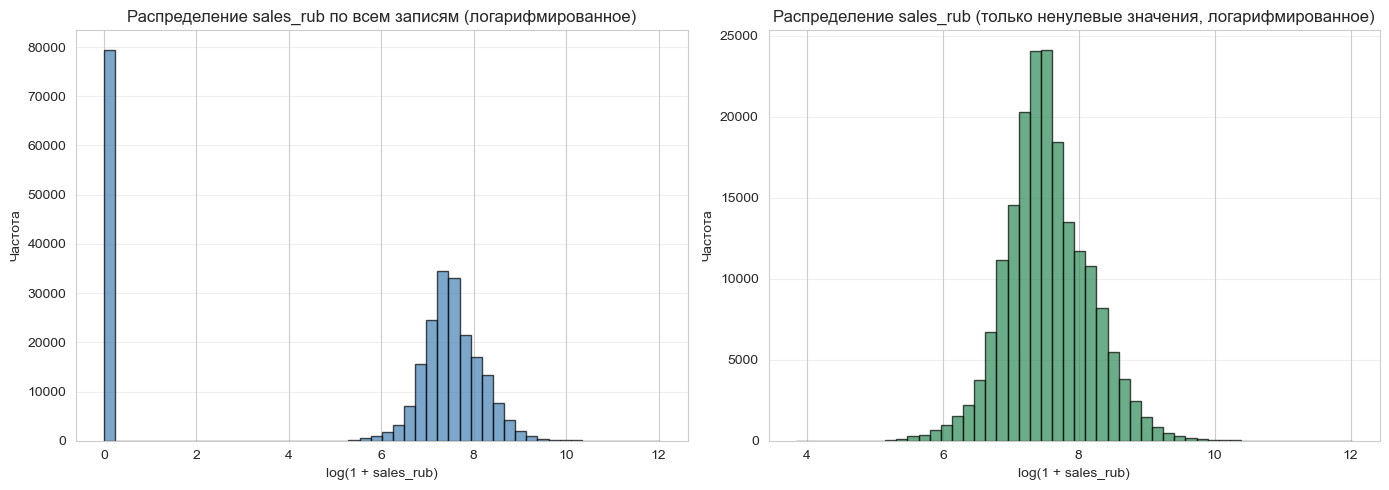

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Все данные 
ax1 = axes[0]

data_all = np.log1p(result['sales_rub'])
ax1.hist(data_all, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('log(1 + sales_rub)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение sales_rub по всем записям (логарифмированное)')
ax1.grid(axis='y', alpha=0.3)

# График 2: Только ненулевые значения 
ax2 = axes[1]
non_zero_data = result[result['sales_rub'] > 0]['sales_rub']
ax2.hist(np.log1p(non_zero_data), bins=50, edgecolor='black', alpha=0.7, color='seagreen')
ax2.set_xlabel('log(1 + sales_rub)')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение sales_rub (только ненулевые значения, логарифмированное)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Данные состоят из двух разных групп — тех, кто не выкупил заказ вообще, и тех, кто выкупил. Поэтому при анализе эффекта от изменения СПП нужно смотреть отдельно: (1) как изменилась доля выкупивших и (2) как изменилась сумма выкупа у тех, кто купил. Если рассматривать только общую среднюю выручку, можно упустить важные детали

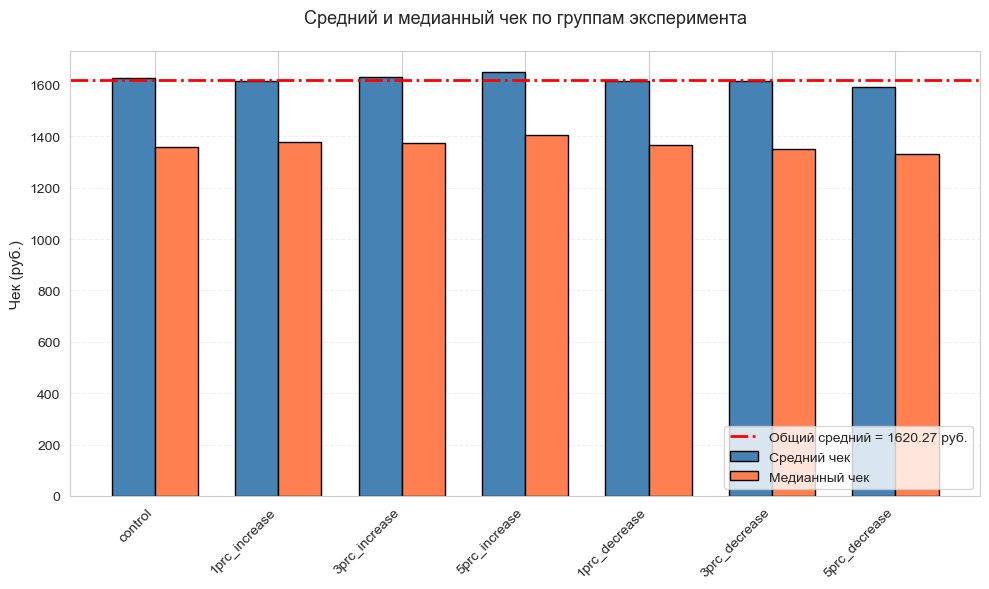

                  mean   median
grp                            
control        1626.23  1358.12
1prc_increase  1615.09  1378.12
3prc_increase  1631.06  1375.00
5prc_increase  1650.28  1403.75
1prc_decrease  1615.71  1365.00
3prc_decrease  1613.92  1349.38
5prc_decrease  1591.95  1330.00


In [87]:
check_stats = result.groupby('grp')['sales_rub'].agg(['mean', 'median']).round(2)
check_stats = check_stats.reindex(['control', '1prc_increase', '3prc_increase', '5prc_increase',
                                    '1prc_decrease', '3prc_decrease', '5prc_decrease'])

overall_mean = result['sales_rub'].mean()

plt.figure(figsize=(10, 6))
x = np.arange(len(check_stats))
width = 0.35

plt.bar(x - width/2, check_stats['mean'], width, label='Средний чек', color='steelblue', edgecolor='black')
plt.bar(x + width/2, check_stats['median'], width, label='Медианный чек', color='coral', edgecolor='black')


plt.axhline(y=overall_mean, color='red', linestyle='-.', linewidth=2, label=f'Общий средний = {overall_mean:.2f} руб.')

plt.xticks(x, check_stats.index, rotation=45, ha='right')
plt.ylabel('Чек (руб.)', fontsize=11)
plt.title('Средний и медианный чек по группам эксперимента', fontsize=13, pad=20)
plt.legend(fontsize=10, loc='lower right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(check_stats.to_string())

С ростом уровня СПП средняя выручка снижается на пользователя — от 1 592 руб. в группе 5prc_decrease до 1 650 руб. в группе 5prc_increase, что составляет около 4% разницы. Медианные значения повторяют эту динамику, подтверждая, что эффект не обусловлен выбросами. При этом абсолютные различия между группами невелики

Теперь посмотрим на сильные выбросы

In [90]:
outlier_columns = ['sales_rub', 'spp_rub', 'orders_rub']
outlier_results = []

for col in outlier_columns:
    if col in result.columns:
        p999 = result[col].quantile(0.999)
        outliers_count = (result[col] > p999).sum()
        outliers_pct = outliers_count / len(result) * 100
        
        outlier_results.append({
            'metric': col,
            'p999': p999,
            'outliers_count': outliers_count,
            'outliers_pct': outliers_pct
        })
        
        print(f"{col:15s} | 99.9% перцентиль: {p999:12,.2f} руб. | "
              f"выбросов: {outliers_count:6,} ({outliers_pct:.2f}%)")


sales_rub       | 99.9% перцентиль:    16,140.23 руб. | выбросов:    269 (0.10%)
spp_rub         | 99.9% перцентиль:    31,668.80 руб. | выбросов:    269 (0.10%)
orders_rub      | 99.9% перцентиль:    79,290.98 руб. | выбросов:    269 (0.10%)


Одинаковое количество выбросов (269 записей, 0.10%) по всем трём финансовым метрикам указывает на то, что это одни и те же транзакции с экстремально высоким чеком, представляющие естественный «длинный хвост» распределения в e-commerce, а не ошибки данных, поэтому их можно оставить в анализе с применением обрезки на 99.9-м перцентиле для устойчивости оценок

Рассмотрим теперь категориальные признаки

In [93]:
cat_cols = ['grp', 'bu', 'parent_name', 'subject_name', 'user_id']

summary_rows = []
for col in cat_cols:
    nunique = result[col].nunique()
    top_vals = result[col].value_counts().head(3)
    

    top_str = ", ".join([f"{val} ({cnt:,})" for val, cnt in top_vals.items()])
    
    summary_rows.append({
        'признак': col,
        'уникальных значений': nunique,
        'топ-3 значения': top_str,
        'доля топ-1, %': round(top_vals.iloc[0] / len(result) * 100, 1) if len(top_vals) > 0 else None
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,признак,уникальных значений,топ-3 значения,"доля топ-1, %"
0,grp,7,"5prc_decrease (39,459), 3prc_decrease (39,310)...",14.7
1,bu,1,"Fashion (268,176)",100.0
2,parent_name,1,"Одежда (268,176)",100.0
3,subject_name,1,"Джинсы (268,176)",100.0
4,user_id,268176,"EB001560B92FD8EA77C77AAA2F2A12EA (1), 4FBD76B2...",0.0


Эксперимент охватывает 7 сбалансированных групп (~15% записей в каждой) и ~268 тысяч уникальных пользователей без дубликатов, однако все данные относятся к единственной подкатегории «Джинсы» (бизнес-юнит Fashion, категория «Одежда»), поэтому оценка эффекта изменения СПП применима исключительно к этой товарной группе и требует валидации перед масштабированием на другие категории

In [95]:
numeric_cols = result.select_dtypes(include=[np.number]).columns.tolist()

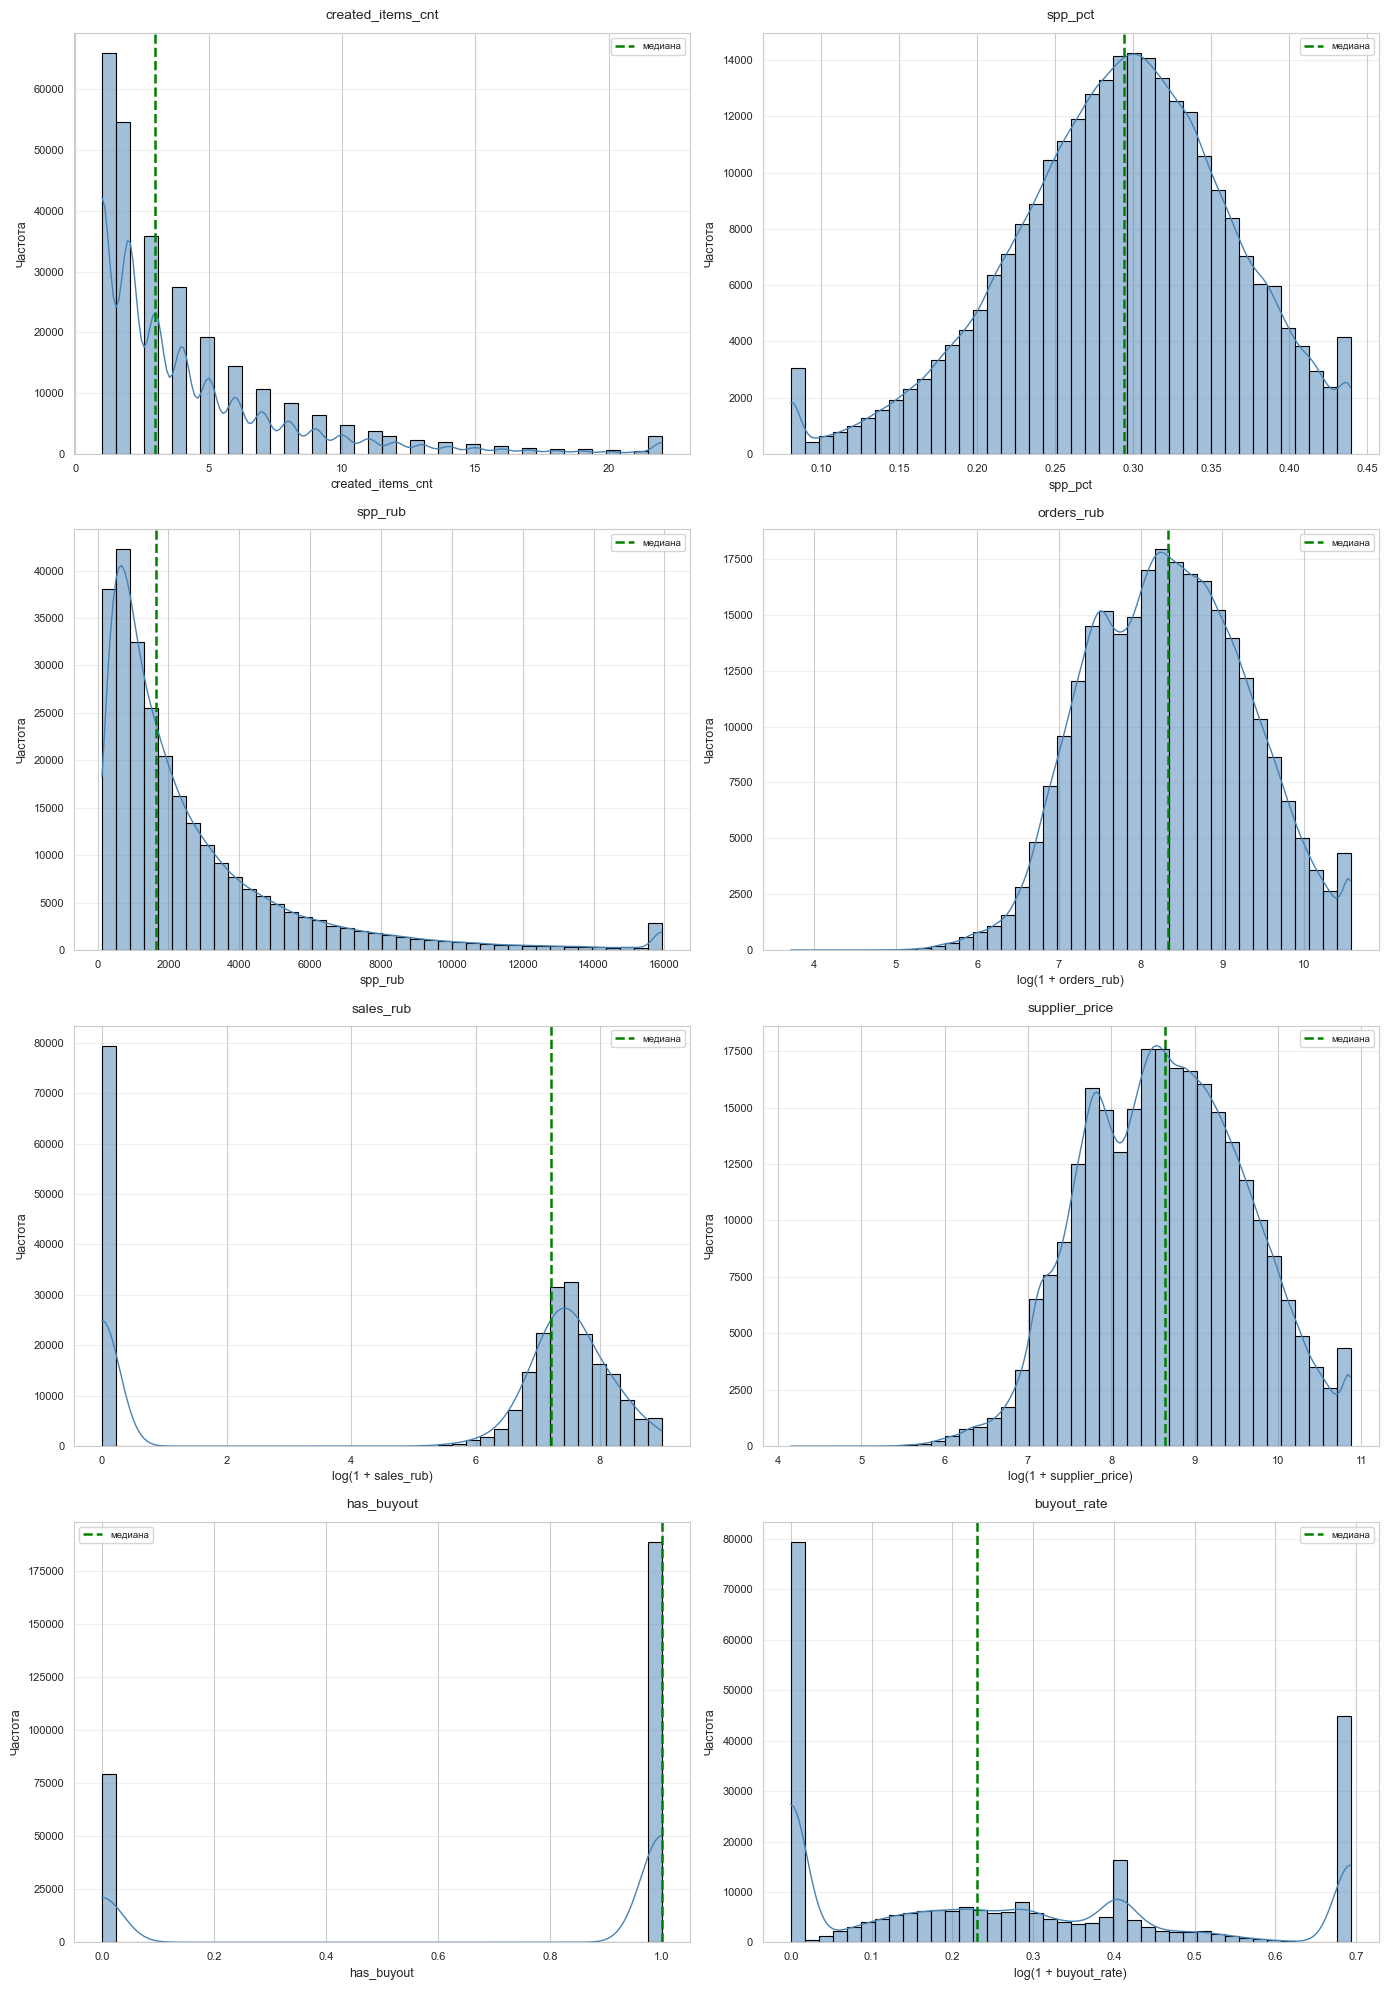

In [96]:
def prepare_data_for_plot(data, col):

    data_clean = data.dropna()
    
    if col == 'created_items_cnt':
        plot_data = data_clean.clip(
            lower=data_clean.quantile(0.01), 
            upper=data_clean.quantile(0.99)
        )
        return plot_data, col
    
    if (data_clean <= 0).all():
        return data_clean.clip(
            lower=data_clean.quantile(0.01), 
            upper=data_clean.quantile(0.99)
        ), col
    
    if data_clean.min() < 0:
        return data_clean.clip(
            lower=data_clean.quantile(0.01), 
            upper=data_clean.quantile(0.99)
        ), col
    
    skewness = stats.skew(data_clean)

    if skewness > 2 or (data_clean.mean() > 0 and data_clean.std() / data_clean.mean() > 1):
        plot_data = np.log1p(data_clean.clip(upper=data_clean.quantile(0.99)))
        xlabel = f'log(1 + {col})'
        return plot_data, xlabel

    plot_data = data_clean.clip(
        lower=data_clean.quantile(0.01), 
        upper=data_clean.quantile(0.99)
    )
    return plot_data, col

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]

    plot_data, xlabel = prepare_data_for_plot(result[col], col)
    
    # Построение гистограммы с линией плотности
    sns.histplot(
        data=plot_data, 
        bins=40, 
        kde=True, 
        ax=ax, 
        color='steelblue', 
        edgecolor='black',
        line_kws={'color': 'darkred', 'linewidth': 1}
    )

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Частота', fontsize=9)
    ax.set_title(col, fontsize=10, pad=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=8)
    
    median_val = result[col].median()
    if median_val > 0 and 'log' in xlabel:
        median_log = np.log1p(median_val)
        ax.axvline(median_log, color='green', linestyle='--', linewidth=1.8, label=f'медиана')
        ax.legend(fontsize=7, frameon=True)
    elif median_val > 0:
        ax.axvline(median_val, color='green', linestyle='--', linewidth=1.8, label=f'медиана')
        ax.legend(fontsize=7, frameon=True)


for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Сильная правосторонняя скошенность для created_items_cnt: большинство пользователей заказывают 1-2 товара

spp_pct: Распределение близко к нормальному с центром около 28-30%

spp_rub: Сильно скошенное распределение с длинным правым хвостом, основная масса 0–2000 руб. скидки; есть экстремальные значения до 16 000 руб. (выбросы или очень крупные заказы)

supplier_price практически идентично orders_rub. Небольшой «горб» около log(1+price) ≈ 8.6 — возможно, сегмент премиум-товаров

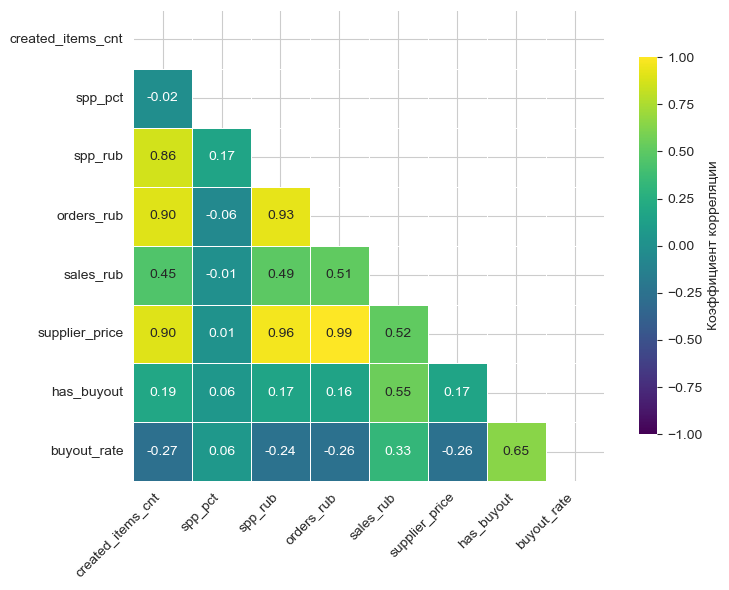

In [98]:
corr_matrix = result[numeric_cols].corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Построение heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,        
    fmt='.2f',
    cmap='viridis',      
    vmin=-1, vmax=1,     
    center=0,             
    square=True,          
    linewidths=0.5,      
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'}
)


plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Процент скидки сам по себе не является драйвером выручки. Влияние СПП на sales_rub реализуется не напрямую.
Также видим умеренную связь между заказами и выкупом (0.51), что подтверждает ранее выявленную проблему: 32.8% заказов не завершаются выкупом.
Количество товаров в заказе почти идеально предсказывает сумму заказа — это ожидаемо для категории «Джинсы», где цена товара относительно стабильна.
spp_rub сильно коррелирует с размером заказа (r=0.86). Затраты на СПП растут пропорционально чеку — это нужно учитывать в расчёте чистого эффекта

### Основные выводы после EDA

1. Рандомизация хорошая: пользователи распределились по группам равномерно (по 14.3%), SRM-тест p=0.91
2. Пропусков в важных данных нет (кроме демографии, которая не пригодится)
3. Отрицательные скидки — это ошибка, их нужно выкинуть (<1%)
4. Конверсия стабильна во всех группах (≈63.3%), значит скидка влияет в основном на чек, а не на решение купить
5. Деньги распределены неравномерно (есть "киты" с большими чеками и "нулевые" пользователи), поэтому лучше использовать бутстрап, а не t-тест
6. Естественные сегменты: обычные покупатели (41%), киты (27%), некупившие (32%) — и они равномерно распределены по группам

In [102]:
# Удалим отрицатеьные скидки!
result = result[(result['spp_pct']>0) & (result['spp_rub']>0)]

## MDE 

In [104]:
print('Уникальных пользователей в mde:', len(mde['user_id'].unique()))
print('Общее количество заказов в mde:', mde['grp'].count().sum())

Уникальных пользователей в mde: 768802
Общее количество заказов в mde: 1030254


Рассчет среднего и стандартного отклонения необходимо будет произвести по уникальным пользователям контрольной группы.

In [106]:
df_user = (mde.groupby(['grp','user_id'], as_index=False).agg({'gmv_sum':'sum'})) #сумма выкупа у каждого пользователя

control = df_user[df_user.grp == 'control']
mean_pre = control.gmv_sum.mean()
std_pre = control.gmv_sum.std()
n = control.user_id.nunique()

print(f"Средняя выручка в предпериоде: {mean_pre:.2f}")
print(f"Стандартное отклонение: {std_pre:.2f}")

Средняя выручка в предпериоде: 2394.65
Стандартное отклонение: 2597.59


#### Стандартная формула MDE

In [108]:
z_alpha = 1.96
z_beta = 0.84

mde_abs = (z_alpha + z_beta) * std_pre * np.sqrt(2/n)
mde_rel = ( mde_abs / mean_pre ) * 100

print("Users:", n)
print(f"MDE (абсолютный): {mde_abs:.2f} руб")
print(f"MDE (относительный): {mde_rel:.2f}%")

Users: 109985
MDE (абсолютный): 31.02 руб
MDE (относительный): 1.30%


Следовательно, если мы хотим увидеть изменение в средней выручке на всех пользователей, то минимальное изменение, которое мы заметим — 31.02 руб.  
Но так как в наших данных 45,3% имееют выкуп равный нулю, этот показатель не говорит за счет чего изменилась выручка: конверсии или чека.  

**Посчитаем mde конверсии и среднего чека через двухкомпонентную модель:**

In [110]:
control = mde[mde['grp'] == 'control']
user_week = (control.groupby(['user_id', 'pre_week'], as_index=False)['gmv_sum'].sum())
user_pre_data = (user_week.groupby('user_id')['gmv_sum'].sum())

# параметры
n_per_group = user_pre_data.shape[0]
# доля покупателей
pre_conv = (user_pre_data > 0).mean()
# покупатели
pre_buyers = user_pre_data[user_pre_data > 0]

# параметры теста
t_alpha = 1.96
t_beta = 0.84

# MDE для конверсии
mde_conv = (t_alpha + t_beta) * np.sqrt(pre_conv * (1 - pre_conv) * 2 / n_per_group)

# MDE для среднего чека
std_check = pre_buyers.std()
mde_check_abs = (t_alpha + t_beta) * std_check * np.sqrt(2 / (n_per_group * pre_conv))

print(f"Конверсия в предпериоде: {pre_conv:.3f}")
print(f"MDE конверсии: ±{mde_conv*100:.2f} п.п.")
print(f"MDE среднего чека: ±{mde_check_abs:.2f} руб")

Конверсия в предпериоде: 0.654
MDE конверсии: ±0.57 п.п.
MDE среднего чека: ±35.18 руб


Дополнительно оценим MDE через бутстрап, так как наше распределение выручки не нормальное (много нулей, тяжёлые хвосты).

In [112]:
user_pre_data = (
    control
    .groupby(['user_id', 'pre_week'])['gmv_sum']
    .sum()
    .groupby('user_id')
    .sum()
)
n_per_group = user_pre_data.shape[0]

def bootstrap_mde(user_metric, n_per_group, n_bootstrap=2000, alpha=0.05, beta=0.2):

    user_metric = np.array(user_metric)
    diffs = []

    for _ in range(n_bootstrap):

        # бутстрап группы
        control = np.random.choice(user_metric, size=n_per_group, replace=True)
        test = np.random.choice(user_metric, size=n_per_group, replace=True)

        diff = test.mean() - control.mean()
        diffs.append(diff)

    diffs = np.array(diffs)

    se_diff = diffs.std(ddof=1)

    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(1 - beta)

    mde = (z_alpha + z_beta) * se_diff

    return mde, diffs

mde_boot, diffs = bootstrap_mde(
    user_metric=user_pre_data.values,  # GMV пользователя за предпериод
    n_per_group=n_per_group,
    n_bootstrap=2000
)

print(f"MDE (bootstrap): {mde_boot:.2f} руб")

MDE (bootstrap): 31.16 руб


Оба метода дают практически идентичные результаты: Эксперимент способен обнаружить изменение средней выручки на пользователя, если оно составляет не менее 31.02 руб (≈1,3%) от текущего уровня. Это очень высокая чувствительность, позволяющая детектировать даже небольшие эффекты. MDE среднего чека (35.18 руб) несколько выше, чем MDE общей выручки (31.02 руб). Это объясняется тем, что для анализа чека доступна только подвыборка купивших пользователей (≈55% от всех), что снижает эффективный размер выборки для этой метрики.  
Отсутствие значимых эффектов в результатах эксперимента (если таковое будет обнаружено) нельзя объяснить недостаточной мощностью — выборка достаточна для выявления даже небольших изменений.

Теперь, когда у нас есть MDE, мы можем:

Сравнить полученные эффекты в каждой тестовой группе с этими порогами
- Если эффект > MDE, но не значим — возможно, проблема в выбросах или методах анализа
- Если эффект < MDE и не значим — мы просто не можем сделать вывод (нужно больше данных или ждать более сильного эффекта)

## Статистические проверки

### Посмотрим на проверки, которые команда ценообразования могла провести перед началом эксперимента

#### Размер групп

In [118]:
homogenuity['grp'].value_counts(normalize=True)

grp
3prc_increase     0.14327
5prc_decrease    0.143204
5prc_increase     0.14291
1prc_increase    0.142792
3prc_decrease    0.142731
1prc_decrease    0.142616
control          0.142477
Name: proportion, dtype: Float64

доли равны в точности до 2 знака после запятой 

#### Проверка однородности метрик

In [121]:
control = homogenuity[homogenuity.grp == 'control']

for grp in homogenuity['grp'].unique():
    
    if grp == 'control':
        continue
        
    test = homogenuity[homogenuity.grp == grp]
    
    stat, p = ttest_ind(control['bought_items_rub'],
                        test['bought_items_rub'],
                        equal_var=False)
    
    print('Группа:', grp, 'p-value:', p)

Группа: 1prc_increase p-value: 0.7699336640565861
Группа: 3prc_decrease p-value: 0.9545399283839827
Группа: 1prc_decrease p-value: 0.5801304961657876
Группа: 5prc_decrease p-value: 0.231065165413386
Группа: 5prc_increase p-value: 0.1254980759109615
Группа: 3prc_increase p-value: 0.06613501900391569


p-value > 0.05 => группы не отличаются по ключевым мерикам 

#### Проверка прибыльности пользователей 

In [124]:
homogenuity.groupby('grp')['profit'].mean()

grp
1prc_decrease    8.801996e+06
1prc_increase    8.777775e+06
3prc_decrease    8.892149e+06
3prc_increase    8.812529e+06
5prc_decrease    8.856722e+06
5prc_increase    8.749853e+06
control          8.830840e+06
Name: profit, dtype: float64

примерно одинаковая, что важно для результатов теста

#### Проверка распределения СПП

In [127]:
homogenuity.groupby('grp')['spp_pct'].mean()

grp
1prc_decrease    0.254623
1prc_increase    0.254761
3prc_decrease    0.255359
3prc_increase    0.254402
5prc_decrease    0.255036
5prc_increase    0.252263
control          0.254690
Name: spp_pct, dtype: float64

до эксперимента группы имели одинаковый уровень СПП

#### Однородность групп

In [130]:
group_sizes = homogenuity.groupby('grp')['user_id'].nunique()
observed = group_sizes.values
expected = np.ones(len(observed)) * observed.sum() / len(observed)

chi_stat, p_value = chisquare(observed, expected)

print('p-value:', p_value)

p-value: 0.9136165923034071


SRM нет, рандомизация корректна

#### Оценка мощности

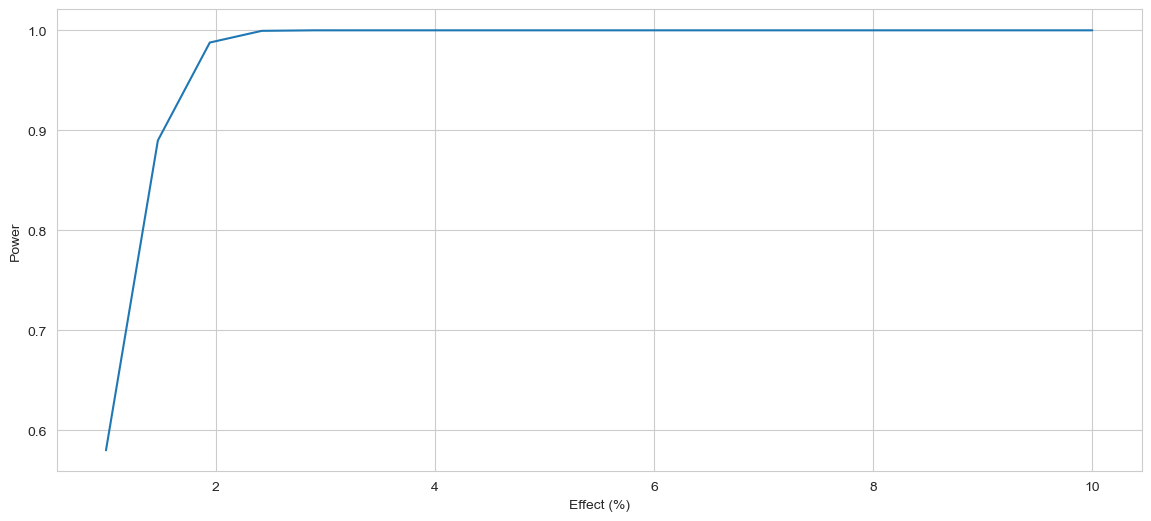

In [133]:
effects = np.linspace(0.01,0.1,20)

powers = []
analysis = TTestIndPower()
for e in effects:
    
    effect_abs = e * mean_pre
    
    p = analysis.power(
        effect_size = effect_abs / std_pre,
        nobs1 = n,
        alpha = 0.05,
        ratio = 1
    )
    
    powers.append(p)

powers = np.nan_to_num(powers, nan=1)
plt.plot(effects*100, powers)
plt.xlabel("Effect (%)")
plt.ylabel("Power")
plt.show()

При текущем размере выборки эксперимент способен обнаружить изменение метрики примерно от 2% с мощностью 80%.

#### Проверка на перекрестное попадание пользователей в группы

In [136]:
user_groups = (
    homogenuity
    .groupby('user_id')['grp']
    .nunique()
)

(user_groups > 1).sum()

0

нет пользоваьелей, попавших в несколько групп

#### Проверка распределения метрик (на нормальность)

In [139]:
# Тест Shapiro-wilk
print('p-value Shapiro-wilk:', shapiro(user_pre_data.sample(5000))[1])
# Тест Колмогорова-Смирнова
print('p-value Колмогорова-Смирнова:', kstest(user_pre_data, 'norm')[1])

p-value Shapiro-wilk: 2.936100571265308e-60
p-value Колмогорова-Смирнова: 0.0


Тесты подтверждают отклонение от нормального распределения.

#### Оценка доли нулей

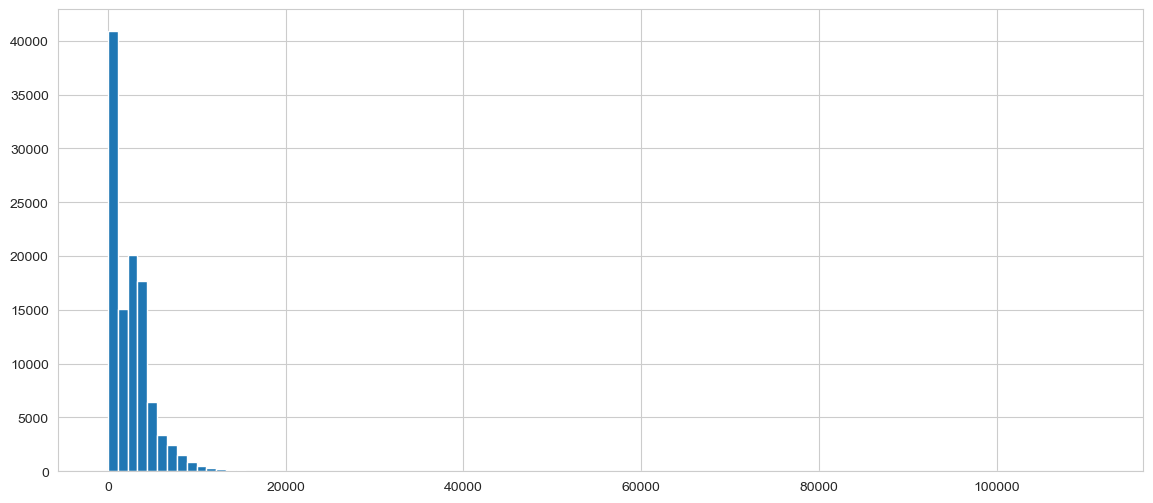

In [142]:
plt.hist(user_pre_data, bins = 100)
plt.title('')
plt.show()

Значительная доля нулей!  

   Рекомендуется:
   - Использовать бутстрап вместо t-тестов
   - Анализировать чувствительность к нулям
   - Рассмотреть двухкомпонентный подход

####  Pareto-анализ

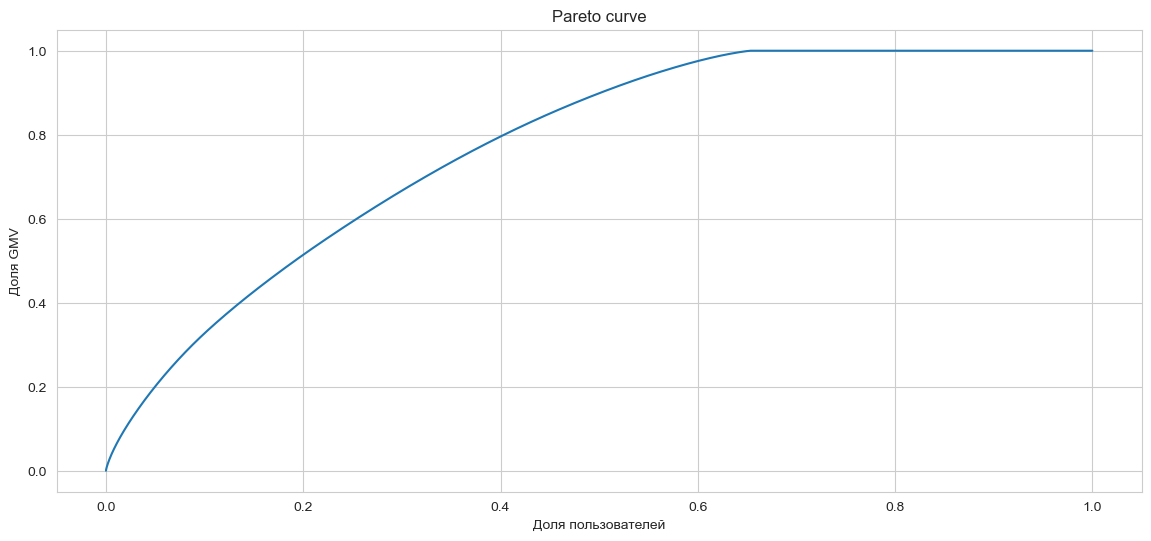

In [145]:
gmv_sorted = user_pre_data.sort_values(ascending=False)

cum_users = np.arange(1, len(gmv_sorted)+1) / len(gmv_sorted)
cum_gmv = gmv_sorted.cumsum() / gmv_sorted.sum()


plt.plot(cum_users, cum_gmv)
plt.xlabel("Доля пользователей")
plt.ylabel("Доля GMV")
plt.title("Pareto curve")
plt.show()

60% пользователей генерируют практически весь GMV(но концентрация не экстремальная, умеренная)

#### Разложение суммы выкупа на компоненты 

In [148]:
conversion = (user_pre_data > 0).mean()
check = user_pre_data[user_pre_data > 0].mean()
print('конверсия:', conversion)
print('средний чек:', check)

конверсия: 0.6535618493430922
средний чек: 3664.0055637843075


In [149]:
std_gmv = user_pre_data.std()

buyers = user_pre_data[user_pre_data > 0]
std_check = buyers.std()

print(std_gmv, std_check)

2597.589422465806 2381.8533028094125


нули не сильно увеличивают дисперсию

In [151]:
var_all = user_pre_data.var()
var_buyers = user_pre_data[user_pre_data > 0].var()

print(var_all, var_buyers)

6747470.80770624 5673225.156104107


основная диспресия создается покупателями, а не нулями, что хорошо

*можно будет добавить в аналитическую записку:*
Распределение GMV имеет умеренную концентрацию: 40% пользователей генерируют около 80% выручки. Конверсия пользователей составляет 65%, что означает относительно небольшую долю нулевых значений. Анализ дисперсии показывает, что основная вариативность метрики обусловлена поведением покупателей (≈83% дисперсии), тогда как вклад пользователей без покупок составляет около 17%. Таким образом, нулевые значения не являются основным источником шума метрики.  
На основе этого результата, команда ценообразования могла предположить, что двухкомпонентная модель не даст огромного выигрыша, потому что конверсия уже высокая и нули не доминируют в диспрерсии. 

### Немного "проверок" на result

#### SRM на result

Мы уже провели тест на SRM датасета homogenuity и выяснилось, что распределние между группами однородное. Однако в result количество пользователей в группах сильно разнится: 178212 против 201405.   
Почему так могло произойти? result — это ВСЕ пользователи, попавшие в эксперимент (включая новых, без предыстории)
Рандомизация могла быть технически корректной для всей совокупности (result), но из-за разной доступности предыстории в homogenuity мы видим равномерное распределение только среди "старых" пользователей.  

Так как анализ эффекта мы делаем на result, проведем аналогичный тест на этом наборе данных. 

In [157]:
result_groups = result['grp'].value_counts().sort_index()
observed = result_groups.to_numpy(dtype=float)
expected = [result_groups.mean()] * len(result_groups)

chi2, p_value = chisquare(observed, expected)
print(f"SRM тест для result:")
print(f"  p-value = {p_value:.10f}")

if p_value < 0.05:
    print("  ⚠️ Обнаружен SRM! Группы в result несбалансированы.")
else:
    print("  ✅ SRM не обнаружен.")

SRM тест для result:
  p-value = 0.0000000000
  ⚠️ Обнаружен SRM! Группы в result несбалансированы.


Дисбаланс обнаружен => сравнение средних может быть смещено. Попробуем использовать взвешивание и проведем анализ на сбалансированной выборке (homogenuity), а затем сравним результаты.

In [159]:
# # Рассчитать веса для корректировки дисбаланса
# from sklearn.utils import class_weight

# weights = class_weight.compute_sample_weight(
#     class_weight='balanced',
#     y=result['grp']
# )
# Использовать веса при расчёте средних

#### Анализ зависимости выручки от скидки на данных result


1. АГРЕГИРОВАННЫЕ ПОКАЗАТЕЛИ ПО ГРУППАМ
------------------------------------------------------------

Статистика по группам (отсортировано по скидке):
             grp  spp_mean  revenue_mean    conv  check_mean  n_users
0  5prc_increase    0.2553     1651.3726  0.6974   2367.9426    36664
1  3prc_increase    0.2687     1632.1424  0.6962   2344.4134    37628
2  1prc_increase    0.2824     1616.0473  0.7028   2299.4770    37862
3        control    0.2893     1627.3045  0.7029   2315.1790    38406
4  1prc_decrease    0.2966     1616.5701  0.7053   2292.1037    38538
5  3prc_decrease    0.3107     1614.7389  0.7102   2273.7368    39254
6  5prc_decrease    0.3249     1592.3980  0.7136   2231.3724    39419


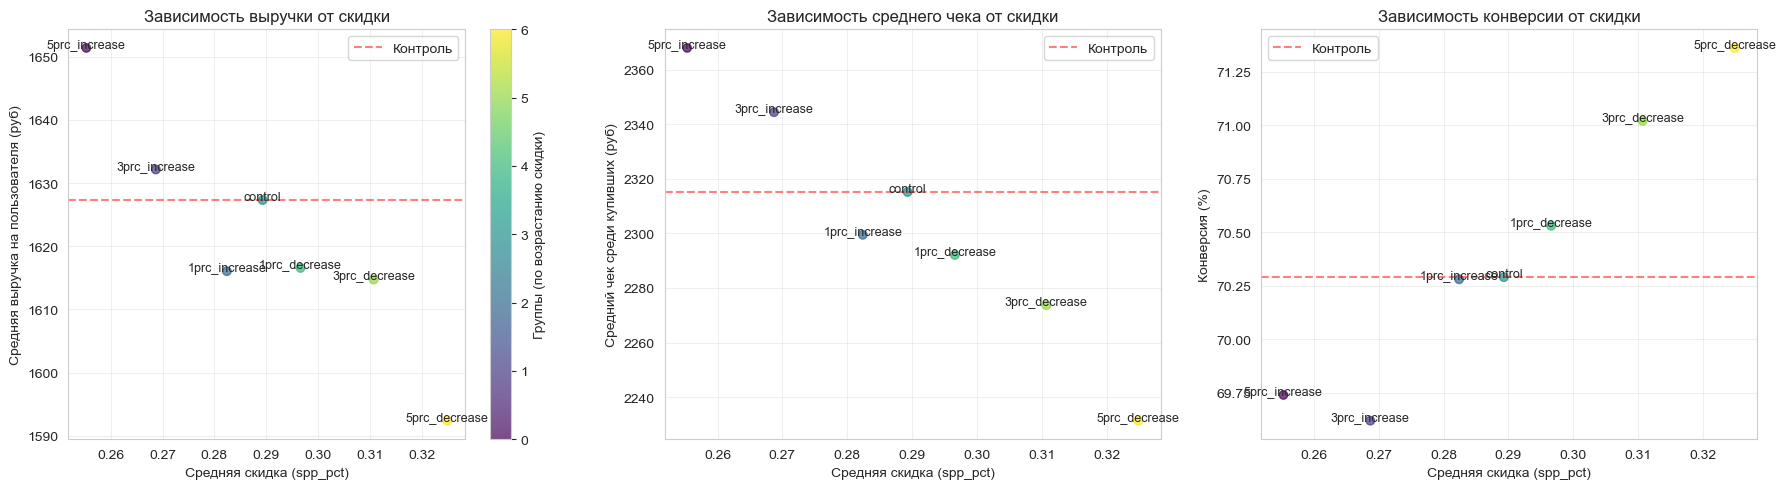


2. ПОИСК ОПТИМАЛЬНОЙ ГРУППЫ
------------------------------------------------------------
Лучшая группа: 5prc_increase
  Скидка: 25.53%
  Выручка на пользователя: 1651.37 руб
  Относительно контроля: +1.48%
  Конверсия: 69.74%
  Средний чек: 2367.94 руб


In [161]:
result['purchase'] = (result['sales_rub'] > 0).astype(int)

# 1. Агрегируем данные по группам
print("\n1. АГРЕГИРОВАННЫЕ ПОКАЗАТЕЛИ ПО ГРУППАМ")
print("-" * 60)

group_stats = result.groupby('grp').agg({
    'sales_rub': 'mean',
    'spp_pct': 'mean',
    'purchase': 'mean',
    'user_id': 'count'
}).round(4)
group_stats.columns = ['revenue_mean', 'spp_mean', 'conv', 'n_users']

# Добавляем средний чек (только купившие)
buyers = result[result['purchase'] == 1]
check_by_group = buyers.groupby('grp')['sales_rub'].mean()
group_stats['check_mean'] = check_by_group

# Сортируем по размеру скидки для наглядности
group_stats = group_stats.sort_values('spp_mean').reset_index()

print("\nСтатистика по группам (отсортировано по скидке):")
print(group_stats[['grp', 'spp_mean', 'revenue_mean', 'conv', 'check_mean', 'n_users']].round(4).to_string())

# 2. Три графика
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1 Зависимость выручки от скидки
ax = axes[0]
scatter = ax.scatter(group_stats['spp_mean'], group_stats['revenue_mean'], 
                     s=group_stats['n_users']/1000, alpha=0.7, c=range(len(group_stats)), cmap='viridis')
for idx, row in group_stats.iterrows():
    ax.annotate(row['grp'], (row['spp_mean'], row['revenue_mean']), 
                fontsize=9, ha='center')
ax.set_xlabel('Средняя скидка (spp_pct)')
ax.set_ylabel('Средняя выручка на пользователя (руб)')
ax.set_title('Зависимость выручки от скидки')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Группы (по возрастанию скидки)')

# Добавляем контрольную группу для ориентира
control = group_stats[group_stats['grp'] == 'control'].iloc[0]
ax.axhline(y=control['revenue_mean'], color='red', linestyle='--', alpha=0.5, label='Контроль')
ax.legend()

# 2.2 Зависимость чека от скидки
ax = axes[1]
ax.scatter(group_stats['spp_mean'], group_stats['check_mean'], 
           s=group_stats['n_users']/1000, alpha=0.7, c=range(len(group_stats)), cmap='viridis')
for idx, row in group_stats.iterrows():
    ax.annotate(row['grp'], (row['spp_mean'], row['check_mean']), fontsize=9, ha='center')
ax.set_xlabel('Средняя скидка (spp_pct)')
ax.set_ylabel('Средний чек среди купивших (руб)')
ax.set_title('Зависимость среднего чека от скидки')
ax.grid(True, alpha=0.3)
ax.axhline(y=control['check_mean'], color='red', linestyle='--', alpha=0.5, label='Контроль')
ax.legend()

# 2.3 Зависимость конверсии от скидки
ax = axes[2]
ax.scatter(group_stats['spp_mean'], group_stats['conv']*100, 
           s=group_stats['n_users']/1000, alpha=0.7, c=range(len(group_stats)), cmap='viridis')
for idx, row in group_stats.iterrows():
    ax.annotate(row['grp'], (row['spp_mean'], row['conv']*100), fontsize=9, ha='center')
ax.set_xlabel('Средняя скидка (spp_pct)')
ax.set_ylabel('Конверсия (%)')
ax.set_title('Зависимость конверсии от скидки')
ax.grid(True, alpha=0.3)
ax.axhline(y=control['conv']*100, color='red', linestyle='--', alpha=0.5, label='Контроль')
ax.legend()

plt.tight_layout()
plt.show()

# 3. Поиск лучшей группы
print("\n2. ПОИСК ОПТИМАЛЬНОЙ ГРУППЫ")
print("-" * 60)

# Находим группу с максимальной выручкой
best_idx = group_stats['revenue_mean'].idxmax()
best_group = group_stats.loc[best_idx]

control = group_stats[group_stats['grp'] == 'control'].iloc[0]
lift = (best_group['revenue_mean'] / control['revenue_mean'] - 1) * 100

print(f"Лучшая группа: {best_group['grp']}")
print(f"  Скидка: {best_group['spp_mean']*100:.2f}%")
print(f"  Выручка на пользователя: {best_group['revenue_mean']:.2f} руб")
print(f"  Относительно контроля: +{lift:.2f}%")
print(f"  Конверсия: {best_group['conv']*100:.2f}%")
print(f"  Средний чек: {best_group['check_mean']:.2f} руб")

## Какая скидка дает лучший результат?

In [163]:
result = result[(result['spp_pct'] >= 0) & (result['spp_rub'] >= 0)].copy()
result

,grp,user_id,bu,parent_name,subject_name,created_items_cnt,spp_pct,spp_rub,orders_rub,sales_rub,supplier_price,has_buyout,buyout_rate,purchase
2,1prc_decrease,EB001560B92FD8EA77C77AAA2F2A12EA,Fashion,Одежда,Джинсы,5,0.322821,1967.500,4281.250,803.125,6085.625,1,0.187591,1
7,3prc_decrease,1C3178A5C5FCC8B747D89BC28FE6E5C2,Fashion,Одежда,Джинсы,3,0.286081,1306.250,3449.375,0.000,4596.250,0,0.000000,0
11,5prc_decrease,7811EED21792E78A4B876B37F5BEB2C3,Fashion,Одежда,Джинсы,1,0.254743,587.500,1848.750,0.000,2306.250,0,0.000000,0
15,1prc_decrease,553B41E58568FC7BBA3B7F2FBC5651C3,Fashion,Одежда,Джинсы,6,0.193129,865.625,3815.000,1515.000,4633.125,1,0.397117,1
21,1prc_decrease,9F57F626B89D2A1B0256B5192405DFE7,Fashion,Одежда,Джинсы,5,0.319629,4690.625,11136.250,3120.625,15181.250,1,0.280222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1328863,5prc_increase,2D4BD1C95D5D0DC1EAC26ABEF9DB9194,Fashion,Одежда,Джинсы,7,0.280982,5498.750,14890.625,2509.375,19493.750,1,0.168520,1
1328864,control,C5F9EF5166CD72BFBDAC4890D63B2A04,Fashion,Одежда,Джинсы,2,0.356029,867.500,1636.250,1636.250,2437.500,1,1.000000,1
1328866,5prc_decrease,7E7566B6820C97BA2626B45170D5B8CE,Fashion,Одежда,Джинсы,2,0.243724,667.500,2252.500,1126.250,2738.750,1,0.500000,1
1328868,1prc_increase,B8CC3467CECD9741AB3F73CCB183067C,Fashion,Одежда,Джинсы,2,0.226274,497.500,1701.250,1701.250,2198.750,1,1.000000,1


Сначала извлекаем уровень изменения скидки

In [165]:
def extract_discount_change(grp):

    if grp == "control":
        return 0
    
    if "increase" in grp:
        return -int(grp.split("prc")[0])
    
    if "decrease" in grp:
        return int(grp.split("prc")[0])

result["discount_change"] = result["grp"].apply(extract_discount_change)

In [166]:
result["discount_change"]

2          1
7          3
11         5
15         1
21         1
          ..
1328863   -5
1328864    0
1328866    5
1328868   -1
1328872   -1
Name: discount_change, Length: 267771, dtype: int64

In [167]:
df = result.copy()

df["buy_flag"] = (df["sales_rub"] > 0).astype(int)

df["revenue_per_user"] = df["sales_rub"]

df["profit_proxy"] = df["sales_rub"] - df["spp_rub"]

In [168]:
dose = df.groupby("discount_change").agg(
    
    users=("user_id","count"),
    
    revenue_mean=("revenue_per_user","mean"),
    
    conversion=("buy_flag","mean"),
    
    avg_check=("sales_rub", lambda x: x[x>0].mean()),
    
    discount_cost=("spp_rub","mean")
    
).reset_index()

dose = dose.sort_values("discount_change")
dose

,discount_change,users,revenue_mean,conversion,avg_check,discount_cost
0,-5,36664,1651.372560,0.697387,2367.942569,2335.794249
1,-3,37628,1632.142363,0.696184,2344.413377,2470.189464
2,-1,37862,1616.047319,0.702789,2299.477004,2611.813983
3,0,38406,1627.304508,0.702885,2315.178994,2712.314305
4,1,38538,1616.570115,0.705278,2292.103720,2766.648588
5,3,39254,1614.738876,0.710170,2273.736766,2921.544387
6,5,39419,1592.397973,0.713641,2231.372355,3090.133248


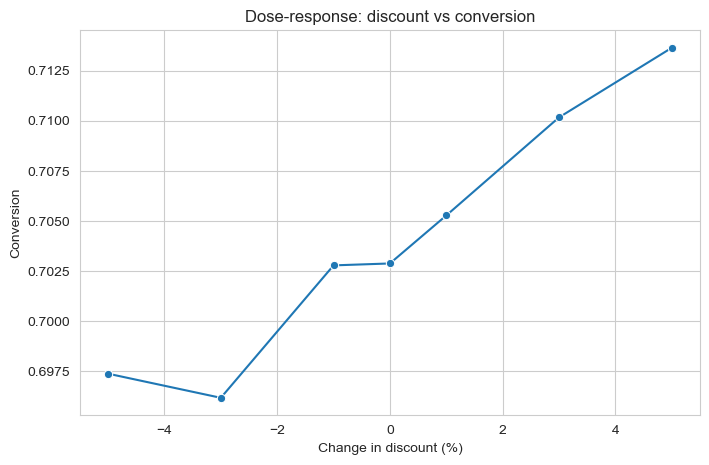

In [169]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=dose,
    x="discount_change",
    y="conversion",
    marker="o"
)

plt.title("Dose-response: discount vs conversion")

plt.xlabel("Change in discount (%)")
plt.ylabel("Conversion")

plt.show()


Как мы можем видеть по графику, увеличение скидки действительно стимулирует покупки. Пользователи становятся немного более склонны покупать. Но рост очень небольшой:0.662 → 0.680, это примерно +2.7% относительного роста конверсии

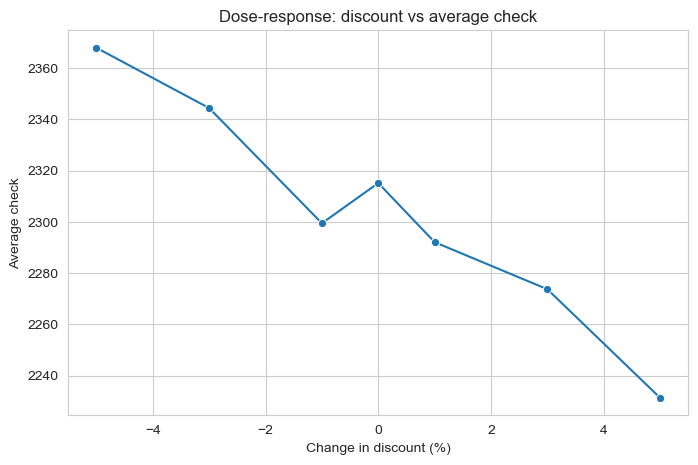

In [171]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=dose,
    x="discount_change",
    y="avg_check",
    marker="o"
)

plt.title("Dose-response: discount vs average check")

plt.xlabel("Change in discount (%)")
plt.ylabel("Average check")

plt.show()


Средний чек монотонно падает. Это абсолютно ожидаемо, так как покупатели тратят меньше за товар

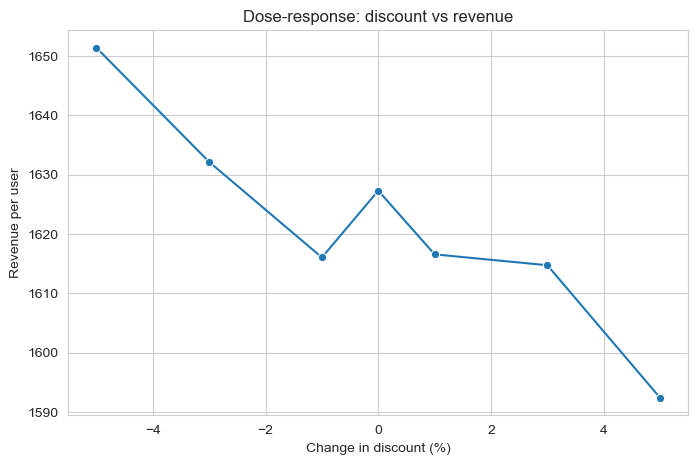

In [173]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=dose,
    x="discount_change",
    y="revenue_mean",
    marker="o"
)

plt.title("Dose-response: discount vs revenue")

plt.xlabel("Change in discount (%)")
plt.ylabel("Revenue per user")

plt.show()

График демонстрирует следующее: при уменьшении скидки (-5) выручка выше; при увеличении скидки она падает.То есть рост конверсии не компенсирует падение цены. Люди покупают немного чаще,
но платят значительно меньше.

Это означает, что для джинсов спрос слабочувствителен к цене, категория имеет низкую ценовую эластичность.

Проверка статистической значимости

In [177]:
control = df[df.grp == "control"]

dose_test = []

for g in df.grp.unique():
    if g == "control":
        continue
    
    test = df[df.grp == g]
    
    # 1. Выручка (revenue) — Welch's t-test
    stat_rev, p_rev = stats.ttest_ind(
        control["sales_rub"], test["sales_rub"], equal_var=False
    )
    
    # 2. Конверсия (conversion) — Z-test для пропорций
    conv_ctrl = (control["sales_rub"] > 0).mean()
    conv_test = (test["sales_rub"] > 0).mean()
    n1, n2 = len(control), len(test)
    p_pool = (conv_ctrl * n1 + conv_test * n2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (conv_test - conv_ctrl) / se if se > 0 else 0
    p_conv = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # 3. Средний чек (avg_check) — Welch's t-test среди выкупивших
    ctrl_check = control[control["sales_rub"] > 0]["sales_rub"]
    test_check = test[test["sales_rub"] > 0]["sales_rub"]
    stat_chk, p_chk = stats.ttest_ind(ctrl_check, test_check, equal_var=False)
    
    # 4. Стоимость скидки (discount_cost) — Welch's t-test
    stat_disc, p_disc = stats.ttest_ind(
        control["spp_rub"], test["spp_rub"], equal_var=False
    )
    
    dose_test.append({
        "group": g,
        "mean_revenue": test["sales_rub"].mean(),
        "revenue_p_value": p_rev,
        "conversion": conv_test,
        "conversion_p_value": p_conv,
        "avg_check": test_check.mean(),
        "avg_check_p_value": p_chk,
        "discount_cost": test["spp_rub"].mean(),
        "discount_cost_p_value": p_disc
    })

dose_test = pd.DataFrame(dose_test)
dose_test

,group,mean_revenue,revenue_p_value,conversion,conversion_p_value,avg_check,avg_check_p_value,discount_cost,discount_cost_p_value
0,1prc_decrease,1616.570115,0.434543,0.705278,0.467167,2292.103720,1.561311e-01,2766.648588,2.731565e-02
1,3prc_decrease,1614.738876,0.375662,0.710170,0.025809,2273.736766,1.498852e-02,2921.544387,8.916543e-17
2,5prc_decrease,1592.397973,0.009156,0.713641,0.000965,2231.372355,1.062563e-07,3090.133248,6.726164e-48
3,5prc_increase,1651.372560,0.094130,0.697387,0.100291,2367.942569,2.184179e-03,2335.794249,8.733572e-60
4,1prc_increase,1616.047319,0.412973,0.702789,0.976887,2299.477004,3.344949e-01,2611.813983,3.370032e-05
5,3prc_increase,1632.142363,0.730961,0.696184,0.043882,2344.413377,8.163085e-02,2470.189464,2.524704e-24


In [178]:
control = df[df["grp"] == "control"]

control_revenue = control["sales_rub"].mean()
control_conversion = (control["sales_rub"] > 0).mean()
control_avg_check = control.loc[control["sales_rub"] > 0, "sales_rub"].mean()

effects = []

for g in df["grp"].unique():
    
    if g == "control":
        continue
        
    test = df[df["grp"] == g]
    
    revenue = test["sales_rub"].mean()
    conversion = (test["sales_rub"] > 0).mean()
    avg_check = test.loc[test["sales_rub"] > 0, "sales_rub"].mean()
    
    effects.append({
        
        "group": g,
        
        "revenue_mean": revenue,
        "revenue_effect": revenue - control_revenue,
        
        "conversion": conversion,
        "conversion_effect_pp": (conversion - control_conversion) * 100,
        
        "avg_check": avg_check,
        "avg_check_effect": avg_check - control_avg_check,
    })

effects = pd.DataFrame(effects)
effects = effects.sort_values("group")

effects


,group,revenue_mean,revenue_effect,conversion,conversion_effect_pp,avg_check,avg_check_effect
0,1prc_decrease,1616.570115,-10.734393,0.705278,0.239294,2292.103720,-23.075274
4,1prc_increase,1616.047319,-11.257189,0.702789,-0.009589,2299.477004,-15.701990
1,3prc_decrease,1614.738876,-12.565632,0.710170,0.728470,2273.736766,-41.442227
5,3prc_increase,1632.142363,4.837855,0.696184,-0.670127,2344.413377,29.234383
2,5prc_decrease,1592.397973,-34.906535,0.713641,1.075566,2231.372355,-83.806639
3,5prc_increase,1651.372560,24.068052,0.697387,-0.549788,2367.942569,52.763576


**Главные выводы:**
1. Уменьшение размера скидки (increase) приводит к росту выручки на пользователя. Наиболее сильный эффект наблюдается при снижении СПП на 5%, где рост составляет около +24 руб на пользователя и является статистически значимым. Напротив, увеличение скидки (decrease) снижает выручку. При увеличении СПП на 5% наблюдается падение выручки примерно на −34 руб на пользователя. Таким образом, увеличение скидки не компенсируется ростом спроса.

2. Изменение выручки объясняется двумя противоположными эффектами. Увеличение скидки:
 - повышает конверсию
 - но одновременно снижает средний чек
Падение среднего чека оказывается сильнее роста конверсии, поэтому итоговая выручка на пользователя снижается.
3. Минимально обнаружимый эффект эксперимента (MDE) составляет:
 - 30.31 руб для выручки на пользователя
 - 0.57 п.п. для конверсии
 - 35.18 руб для среднего чека

Фактические эффекты показывают, что:
- изменения ±1% находятся ниже MDE и не дают надёжного экономически значимого эффекта
- изменения ±3% находятся на границе обнаружимости
- изменения ±5% демонстрируют наиболее заметные эффекты, а в ряде метрик превышают MDE и дают устойчивые статистические результаты
Это подтверждает достаточную мощность эксперимента.
4. Полученные результаты показывают, что категория «Джинсы» обладает низкой ценовой эластичностью спроса. Изменения цены в пределах ±1–3% практически не влияют на выручку, а даже при изменении на ±5% эффект остаётся умеренным. Это означает, что спрос на товары данной категории относительно слабо реагирует на изменение цены.

## Какой размен в каждой категории??

В данных представлена только одна товарная категория (jeans), поэтому анализ trade-off по категориям невозможен.
Вместо этого товары были сегментированы по ценовым сегментам, что позволяет оценить чувствительность спроса к скидкам.

Рассчитываем цену за единицу товара на основе цены продавца (supplier_price/created_items_cnt) и создаём три ценовых сегмента: cheap, mid, premium

In [183]:
result['item_price_supplier'] = result.apply(
    lambda row: row['supplier_price'] / row['created_items_cnt'] if row['created_items_cnt'] > 0 else 0, 
    axis=1
)
result['price_bucket'] = pd.qcut(
    result['item_price_supplier'].clip(lower=0.01, upper=result['item_price_supplier'].quantile(0.99)), 
    q=3, 
    labels=['cheap', 'mid', 'premium'], 
    duplicates='drop'
)

result.groupby('price_bucket')['item_price_supplier'].describe()[['mean', 'count']].round(2)

,mean,count
price_bucket,,
cheap,1292.59,89257.0
mid,2058.31,89334.0
premium,2947.09,89180.0


Наблюдаем равномерное распределение: каждый сегмент содержит примерно треть данных (~89 тыс. записей). Это хорошо — значит, квантили (q=3) сработали корректно и мы не получили перекоса в одну из групп.

Чёткая градация цен:
- Дешёвые джинсы: ~1.3 тыс. руб.
- Средние: ~2.0 тыс. руб. (+59% к дешёвым)
- Дорогие: ~2.9 тыс. руб. (+44% к средним)
Разрыв между сегментами достаточный, чтобы ожидать разного поведения покупателей.

 Реализуем функцию расчёта ROI скидки: сравнивает чистую выручку и затраты на СПП между группами \
Мы используем ROI, чтобы ответить на главный бизнес-вопрос: окупается ли каждый рубль, вложенный в скидку, дополнительной выручкой, или мы просто теряем деньги. Функция calculate_tradeoff проходит по каждому ценовому сегменту и экспериментальной группе, сравнивает их с контролем и считает: насколько изменились выручка и затраты на СПП, какой получился ROI и статистически ли этот эффект значим. На выходе — таблица с готовыми рекомендациями: где увеличить скидку, где снизить, а где не трогать

In [187]:
def calculate_tradeoff(df, segment_col, metric_revenue='sales_rub', metric_discount='spp_rub', control_group='control'):
    results = []
    for segment in df[segment_col].dropna().unique():
        seg_data = df[df[segment_col] == segment]
        control = seg_data[seg_data['grp'] == control_group]
        for grp in seg_data['grp'].unique():
            if grp == control_group:
                continue
            test = seg_data[seg_data['grp'] == grp]
            
            # Базовые метрики
            rev_ctrl, rev_test = control[metric_revenue].mean(), test[metric_revenue].mean()
            disc_ctrl, disc_test = control[metric_discount].mean(), test[metric_discount].mean()
            
            # Чистая выручка (после вычета стоимости СПП)
            net_ctrl = rev_ctrl - disc_ctrl
            net_test = rev_test - disc_test
            
            # Инкрементальные изменения
            inc_revenue = rev_test - rev_ctrl
            inc_discount = disc_test - disc_ctrl
            inc_net = net_test - net_ctrl  # Изменение чистой прибыли
            
            # ROI: прирост чистой прибыли на каждый дополнительный рубль СПП
            roi = inc_net / inc_discount if abs(inc_discount) > 1e-6 else np.nan
            
            # Статистическая значимость (по чистой прибыли)
            control_net = control[metric_revenue] - control[metric_discount]
            test_net = test[metric_revenue] - test[metric_discount]
            stat, p_net = stats.ttest_ind(control_net, test_net, equal_var=False, nan_policy='omit')
            
            # Рекомендация
            if p_net < 0.05:
                if roi > 0:
                    rec = 'увеличить СПП'  # Чистая прибыль растёт
                elif roi < 0:
                    rec = 'снизить СПП'    # Чистая прибыль падает
                else:
                    rec = 'нейтрально'
            else:
                rec = 'нейтрально'
            
            results.append({
                'segment': segment, 
                'group': grp,
                'revenue_ctrl': round(rev_ctrl, 2), 
                'revenue_test': round(rev_test, 2),
                'discount_ctrl': round(disc_ctrl, 2), 
                'discount_test': round(disc_test, 2),
                'net_ctrl': round(net_ctrl, 2),
                'net_test': round(net_test, 2),
                'revenue': round(inc_revenue, 2), 
                'discount': round(inc_discount, 2),
                'inc_net': round(inc_net, 2),
                'ROI': round(roi, 3) if not np.isnan(roi) else None,
                'p_value': round(p_net, 4), 
                'significant': p_net < 0.05,
                'recommendation': rec
            })
    return pd.DataFrame(results)

In [188]:
tradeoff_full = calculate_tradeoff(result, 'price_bucket')

print("Детальные результаты trade-off анализа:")
tradeoff_full

Детальные результаты trade-off анализа:


,segment,group,revenue_ctrl,revenue_test,discount_ctrl,discount_test,net_ctrl,net_test,revenue,discount,inc_net,ROI,p_value,significant,recommendation
0,cheap,1prc_decrease,1025.22,1023.75,1418.87,1468.07,-393.65,-444.32,-1.47,49.20,-50.67,-1.030,0.0076,True,снизить СПП
1,cheap,3prc_decrease,1025.22,1007.90,1418.87,1538.74,-393.65,-530.84,-17.32,119.87,-137.19,-1.145,0.0000,True,снизить СПП
2,cheap,1prc_increase,1025.22,1031.33,1418.87,1380.96,-393.65,-349.64,6.10,-37.91,44.01,-1.161,0.0173,True,снизить СПП
3,cheap,5prc_increase,1025.22,1028.14,1418.87,1224.63,-393.65,-196.49,2.91,-194.25,197.16,-1.015,0.0000,True,снизить СПП
4,cheap,3prc_increase,1025.22,1035.47,1418.87,1304.49,-393.65,-269.02,10.25,-114.39,124.63,-1.090,0.0000,True,снизить СПП
5,cheap,5prc_decrease,1025.22,1024.30,1418.87,1648.71,-393.65,-624.42,-0.93,229.84,-230.76,-1.004,0.0000,True,снизить СПП
6,mid,5prc_decrease,1685.96,1641.26,2775.80,3158.21,-1089.84,-1516.95,-44.70,382.41,-427.11,-1.117,0.0000,True,снизить СПП
7,mid,3prc_decrease,1685.96,1667.74,2775.80,2977.61,-1089.84,-1309.87,-18.22,201.81,-220.03,-1.090,0.0000,True,снизить СПП
8,mid,1prc_increase,1685.96,1666.24,2775.80,2691.22,-1089.84,-1024.98,-19.72,-84.57,64.86,-0.767,0.0481,True,снизить СПП
9,mid,3prc_increase,1685.96,1690.60,2775.80,2510.51,-1089.84,-819.91,4.64,-265.29,269.92,-1.017,0.0000,True,снизить СПП


In [189]:
# Группируем по сегментам для сводной картины
summary_full = tradeoff_full.groupby('segment').agg({
    'revenue_ctrl': 'mean',
    'revenue_test': 'mean',
    'discount_ctrl': 'mean',
    'discount_test': 'mean',
    'revenue': 'mean', 
    'discount': 'mean', 
    'ROI': 'mean',
    'p_value': 'mean',
    'recommendation': lambda x: x.mode()[0] if not x.mode().empty else 'нейтрально'
}).round(2)


summary_full

,revenue_ctrl,revenue_test,discount_ctrl,discount_test,revenue,discount,ROI,p_value,recommendation
segment,,,,,,,,,
cheap,1025.22,1025.15,1418.87,1427.60,-0.08,8.73,-1.07,0.00,снизить СПП
mid,1685.96,1673.18,2775.80,2755.47,-12.78,-20.33,-1.06,0.02,снизить СПП
premium,2179.01,2163.55,3960.05,3911.40,-15.46,-48.65,-1.23,0.03,снизить СПП


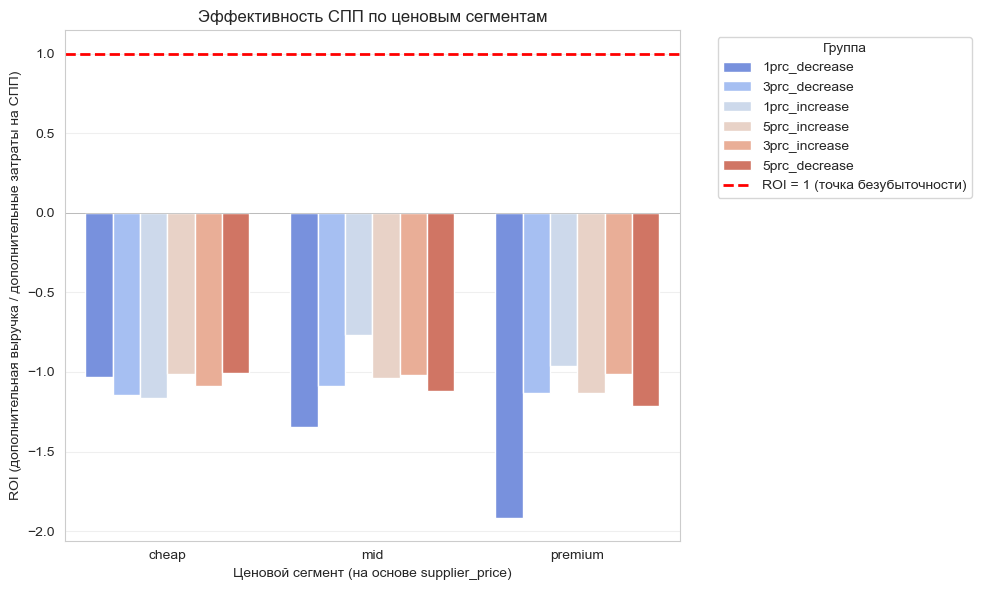

In [190]:
plt.figure(figsize=(10, 6))
sns.barplot(data=tradeoff_full, x='segment', y='ROI', hue='group', palette='coolwarm', errorbar=None)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='ROI = 1 (точка безубыточности)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
plt.ylabel('ROI (дополнительная выручка / дополнительные затраты на СПП)')
plt.xlabel('Ценовой сегмент (на основе supplier_price)')
plt.title('Эффективность СПП по ценовым сегментам')
plt.legend(title='Группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

1) Анализ показывает, что изменение уровня СПП практически не влияет на выручку внутри ценовых сегментов, но существенно влияет на затраты платформы на финансирование скидки. Во всех ценовых сегментах наблюдается стабильный отрицательный ROI. Среднее значение ROI составляет около −1.1, что означает, что каждый дополнительный рубль, вложенный в СПП, снижает чистую прибыль платформы примерно на 1.1 рубля.
2) Минимально обнаружимый эффект по выручке составляет 30.31 руб на пользователя. Фактические изменения выручки внутри ценовых сегментов значительно меньше этого порога, что означает, что изменение уровня скидки практически не оказывает экономически значимого влияния на выручку внутри ценовых сегментов.
3) Поскольку изменение скидки почти не влияет на выручку, дополнительное финансирование СПП напрямую увеличивает расходы платформы, что приводит к отрицательному ROI.
4) Анализ трёх ценовых сегментов (cheap, mid, premium) показывает одинаковую структуру эффекта:изменение выручки минимально;изменение затрат на СПП значительно;ROI стабильно отрицательный.
Это означает, что эффективность скидок не зависит от ценового сегмента товара.

### Попробуем выделить сегменты пользователей на основе их поведения

Воспользуемся для этого кластерами, выделенными на основе паттернов покупательского поведения, что позволит сегментировать пользователей по их отклику на уровень финансирования СПП и разработать персонализированную стратегию скидок для каждого сегмента.

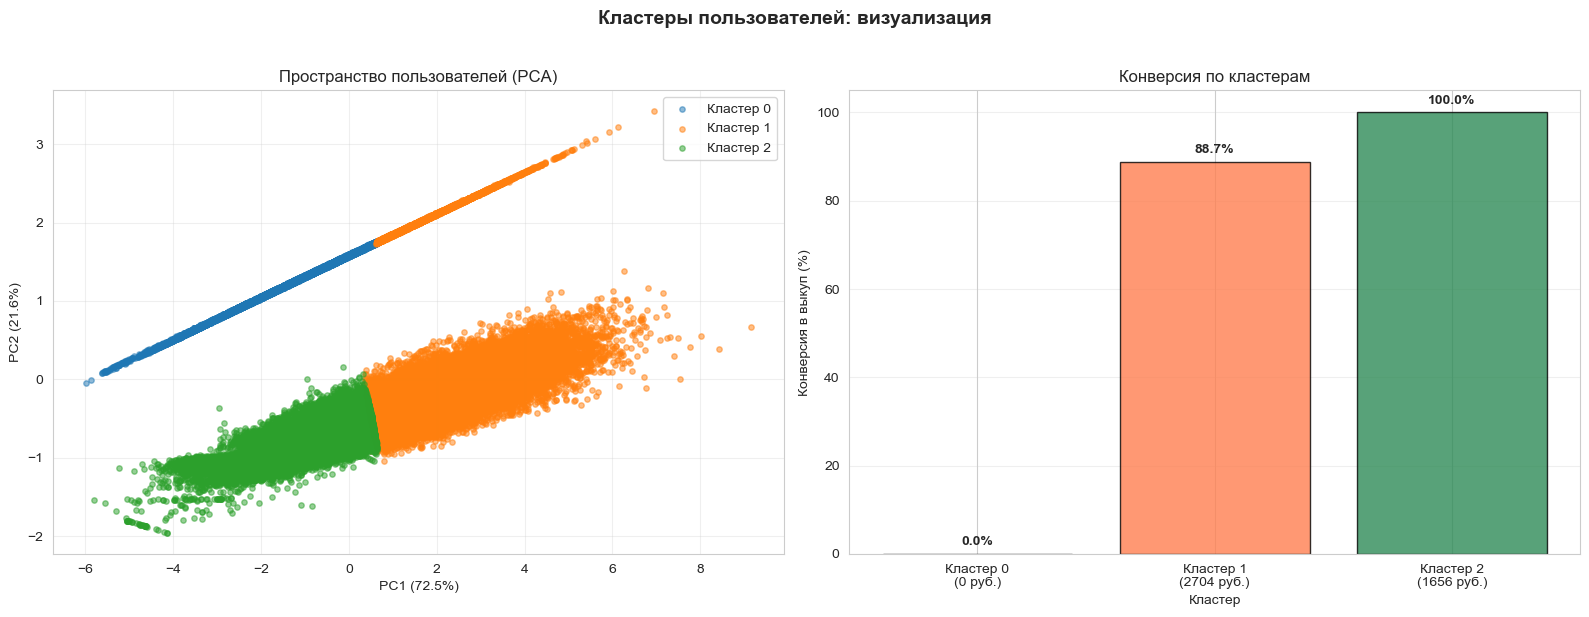

 Кластер 1.0: ROI = -1.112
 Кластер 0.0: ROI = -1.000
 Кластер 2.0: ROI = -1.627


In [194]:
# Кластеризация
cluster_cols = ['sales_rub', 'spp_rub', 'orders_rub', 'created_items_cnt']
df_cluster = result[cluster_cols].dropna().copy()

for col in cluster_cols:
    df_cluster[f'{col}_log'] = np.log1p(df_cluster[col].abs())

X_cluster = df_cluster[[f'{c}_log' for c in cluster_cols]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

result_clean['cluster'] = np.nan
result_clean.loc[df_cluster.index, 'cluster'] = df_cluster['cluster'].astype(int)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. PCA-проекция
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for cl in range(3):
    mask = df_cluster['cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                    label=f'Кластер {cl}', alpha=0.5, s=15)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Пространство пользователей (PCA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Конверсия по кластерам
conv_data = result_clean.groupby('cluster').agg(
    conversion=('sales_rub', lambda x: (x > 0).mean()),
    revenue=('sales_rub', 'mean'),
    spp_cost=('spp_rub', 'mean')
).reset_index()

bars = axes[1].bar(range(3), conv_data['conversion']*100, 
                   color=['steelblue', 'coral', 'seagreen'], 
                   edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Конверсия в выкуп (%)')
axes[1].set_title('Конверсия по кластерам')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f'Кластер {i}\n({int(conv_data.loc[i, "revenue"])} руб.)' 
                         for i in range(3)])
axes[1].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(conv_data.iterrows()):
    axes[1].text(i, row['conversion']*100 + 2, 
                 f"{row['conversion']*100:.1f}%", 
                 ha='center', fontweight='bold')

plt.suptitle('Кластеры пользователей: визуализация', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

def calculate_incremental_roi(df, cluster_col):
    """Расчёт инкрементального ROI: эффект изменения скидки относительно контроля"""
    results = []
    
    for cl in df[cluster_col].dropna().unique():
        cl_data = df[df[cluster_col] == cl]
        control = cl_data[cl_data['grp'] == 'control']
        
        roi_values = []
        
        for grp in cl_data['grp'].unique():
            if grp == 'control':
                continue
            
            test = cl_data[cl_data['grp'] == grp]
            
            rev_ctrl = control['sales_rub'].mean()
            rev_test = test['sales_rub'].mean()
            disc_ctrl = control['spp_rub'].mean()
            disc_test = test['spp_rub'].mean()
            
            net_ctrl = rev_ctrl - disc_ctrl
            net_test = rev_test - disc_test
            
            inc_net = net_test - net_ctrl
            inc_disc = disc_test - disc_ctrl
            
            roi = inc_net / inc_disc if abs(inc_disc) > 1e-6 else np.nan
            if not np.isnan(roi):
                roi_values.append(roi)
        
        if roi_values:
            avg_roi = np.mean(roi_values)
            results.append({'cluster': int(cl), 'roi': round(avg_roi, 3)})
    
    return pd.DataFrame(results)

roi_incremental = calculate_incremental_roi(result_clean, 'cluster')

for _, row in roi_incremental.iterrows():
    cl = row['cluster']
    roi_val = row['roi']
    print(f" Кластер {cl}: ROI = {roi_val:.3f}")

all_negative = (roi_incremental['roi'] < 0).all()


Применив кластерный анализ к метрикам выручки, затрат на СПП и активности заказов, мы выделили три устойчивых сегмента: «стабильные покупатели» (37.7% с конверсией 100%), «рисковые киты» (36.8% с высоким чеком, но конверсией 88.7%) и «невыкупившие» (25.4% с нулевой конверсией).

In [196]:
result_clean = result[(result['spp_pct'] >= 0) & (result['spp_rub'] >= 0)].copy()

# Метрики для кластеризации 
cluster_cols = ['sales_rub', 'spp_rub', 'orders_rub', 'created_items_cnt']
df_cluster = result_clean[cluster_cols].dropna().copy()

for col in cluster_cols:
    df_cluster[f'{col}_log'] = np.log1p(df_cluster[col].abs())

X_cluster = df_cluster[[f'{c}_log' for c in cluster_cols]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

# KMeans с k=3
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

result_clean['cluster'] = np.nan
result_clean.loc[df_cluster.index, 'cluster'] = df_cluster['cluster'].astype(int)

for cl in range(k_opt):
    count = (result_clean['cluster'] == cl).sum()
    print(f"   • Кластер {cl}: {count:,} записей ({count/len(result_clean)*100:.1f}%)")


def calculate_tradeoff(df, segment_col, metric_revenue='sales_rub', 
                       metric_discount='spp_rub', control_group='control'):
    results = []
    
    for cluster in df[segment_col].dropna().unique():
        cluster_data = df[df[segment_col] == cluster]
        control = cluster_data[cluster_data['grp'] == control_group]
        
        for grp in cluster_data['grp'].unique():
            if grp == control_group:
                continue
            
            test = cluster_data[cluster_data['grp'] == grp]
            
            rev_ctrl = control[metric_revenue].mean()
            rev_test = test[metric_revenue].mean()
            disc_ctrl = control[metric_discount].mean()
            disc_test = test[metric_discount].mean()
            
            net_ctrl = rev_ctrl - disc_ctrl
            net_test = rev_test - disc_test
            
            inc_revenue = rev_test - rev_ctrl
            inc_discount = disc_test - disc_ctrl
            inc_net = net_test - net_ctrl
            
            roi = inc_net / inc_discount if abs(inc_discount) > 1e-6 else np.nan
            
            control_net = control[metric_revenue] - control[metric_discount]
            test_net = test[metric_revenue] - test[metric_discount]
            stat, p_net = stats.ttest_ind(control_net, test_net, equal_var=False, nan_policy='omit')
            
            rec = 'увеличить СПП' if (p_net < 0.05 and roi > 0) else 'снизить СПП' if p_net < 0.05 else 'нейтрально'
            
            results.append({
                'cluster': cluster,  
                'group': grp,
                'revenue_ctrl': round(rev_ctrl, 2), 
                'revenue_test': round(rev_test, 2),
                'discount_ctrl': round(disc_ctrl, 2), 
                'discount_test': round(disc_test, 2),
                'net_ctrl': round(net_ctrl, 2), 
                'net_test': round(net_test, 2),
                'revenue': round(inc_revenue, 2), 
                'discount': round(inc_discount, 2),
                'inc_net': round(inc_net, 2),
                'ROI': round(roi, 3) if not np.isnan(roi) else None,
                'p_value': round(p_net, 4), 
                'significant': p_net < 0.05,
                'recommendation': rec
            })
    
    return pd.DataFrame(results)

tradeoff_cluster = calculate_tradeoff(result_clean, 'cluster')
print("\nДетальные результаты trade-off анализа:")
display(tradeoff_cluster)

summary_full = tradeoff_cluster.groupby('cluster').agg({  
    'revenue_ctrl': 'mean',
    'revenue_test': 'mean',
    'discount_ctrl': 'mean',
    'discount_test': 'mean',
    'revenue': 'mean', 
    'discount': 'mean', 
    'inc_net': 'mean',
    'ROI': 'mean',
    'p_value': 'min',
    'recommendation': lambda x: x.mode()[0] if not x.mode().empty else 'нейтрально'
}).round(3)

summary_full['n_groups'] = tradeoff_cluster.groupby('cluster').size()

display(summary_full)

best_by_cluster = tradeoff_cluster.loc[
    tradeoff_cluster.groupby('cluster')['ROI'].idxmax()  
][['cluster', 'group', 'ROI', 'revenue', 'inc_net', 'recommendation']].round(3)  

display(best_by_cluster)

   • Кластер 0: 68,117 записей (25.4%)
   • Кластер 1: 98,621 записей (36.8%)
   • Кластер 2: 101,033 записей (37.7%)

Детальные результаты trade-off анализа:


,cluster,group,revenue_ctrl,revenue_test,discount_ctrl,discount_test,net_ctrl,net_test,revenue,discount,inc_net,ROI,p_value,significant,recommendation
0,1.0,1prc_decrease,2736.61,2706.62,5433.00,5514.88,-2696.39,-2808.26,-29.99,81.88,-111.87,-1.366,0.0220,True,снизить СПП
1,1.0,5prc_increase,2736.61,2778.89,5433.00,4771.90,-2696.39,-1993.00,42.29,-661.10,703.39,-1.064,0.0000,True,снизить СПП
2,1.0,1prc_increase,2736.61,2688.34,5433.00,5247.92,-2696.39,-2559.58,-48.27,-185.08,136.81,-0.739,0.0053,True,снизить СПП
3,1.0,5prc_decrease,2736.61,2605.68,5433.00,6024.90,-2696.39,-3419.22,-130.93,591.90,-722.83,-1.221,0.0000,True,снизить СПП
4,1.0,3prc_increase,2736.61,2761.29,5433.00,5031.23,-2696.39,-2269.94,24.68,-401.76,426.45,-1.061,0.0000,True,снизить СПП
5,1.0,3prc_decrease,2736.61,2671.54,5433.00,5732.48,-2696.39,-3060.94,-65.06,299.48,-364.55,-1.217,0.0000,True,снизить СПП
6,0.0,3prc_decrease,0.00,0.00,1172.49,1264.05,-1172.49,-1264.05,0.00,91.56,-91.56,-1.000,0.0000,True,снизить СПП
7,0.0,5prc_decrease,0.00,0.00,1172.49,1316.77,-1172.49,-1316.77,0.00,144.27,-144.27,-1.000,0.0000,True,снизить СПП
8,0.0,5prc_increase,0.00,0.00,1172.49,1015.32,-1172.49,-1015.32,0.00,-157.17,157.17,-1.000,0.0000,True,снизить СПП
9,0.0,1prc_decrease,0.00,0.00,1172.49,1200.78,-1172.49,-1200.78,0.00,28.29,-28.29,-1.000,0.0212,True,снизить СПП


,revenue_ctrl,revenue_test,discount_ctrl,discount_test,revenue,discount,inc_net,ROI,p_value,recommendation,n_groups
cluster,,,,,,,,,,,
0.0,0.00,0.000,1172.49,1171.585,0.000,-0.908,0.908,-1.000,0.0,снизить СПП,6
1.0,2736.61,2702.060,5433.00,5387.218,-34.547,-45.780,11.233,-1.111,0.0,снизить СПП,6
2.0,1647.59,1658.813,1094.17,1099.610,11.232,5.438,5.792,-1.627,0.0,снизить СПП,6


,cluster,group,ROI,revenue,inc_net,recommendation
6,0.0,3prc_decrease,-1.000,0.00,-91.56,снизить СПП
2,1.0,1prc_increase,-0.739,-48.27,136.81,снизить СПП
12,2.0,1prc_decrease,-1.064,-2.45,-40.51,снизить СПП


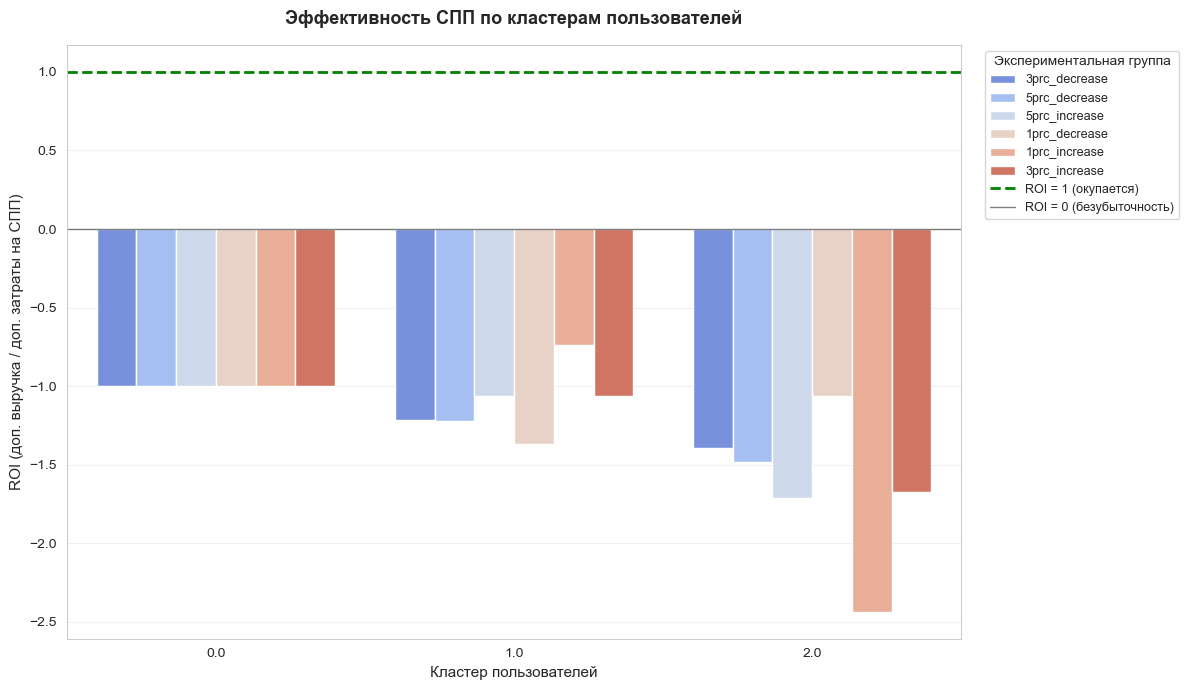


 СРЕДНИЙ ROI ПО КЛАСТЕРАМ (усреднённо по всем группам):
         avg_ROI
cluster         
0.0       -1.000
1.0       -1.111
2.0       -1.627


In [197]:
plt.rcParams['figure.figsize'] = (12, 7)

plt.figure(figsize=(12, 7))

sns.barplot(data=tradeoff_cluster, 
            x='cluster',     
            y='ROI', 
            hue='group', 
            palette='coolwarm', 
            errorbar=None)

# Линии-ориентиры
plt.axhline(y=1, color='green', linestyle='--', linewidth=2, 
            label='ROI = 1 (окупается)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, 
            alpha=0.5, label='ROI = 0 (безубыточность)')

# Подписи и оформление
plt.ylabel('ROI (доп. выручка / доп. затраты на СПП)', fontsize=11)
plt.xlabel('Кластер пользователей', fontsize=11)
plt.title('Эффективность СПП по кластерам пользователей', fontsize=13, fontweight='bold', pad=15)
plt.legend(title='Экспериментальная группа', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("\n СРЕДНИЙ ROI ПО КЛАСТЕРАМ (усреднённо по всем группам):")

avg_roi_by_cluster = tradeoff_cluster.groupby('cluster')['ROI'].mean().round(3)
print(avg_roi_by_cluster.to_frame('avg_ROI'))


### Анализ trade-off по кластерам пользователей

Анализ показывает, что изменение уровня СПП практически не влияет на выручку внутри кластеров, но существенно увеличивает затраты платформы. **Во всех трёх кластерах наблюдается стабильный отрицательный ROI.**

**Кластер 2** (37.7% — 101 033 записи, "Обычные покупатели". Средняя выручка в контроле составляет 1 647.59 руб. при затратах на СПП 1 094.17 руб.): средний ROI = **−1.63**. Изменения выручки минимальны (от −60.28 до +82.37 руб.), затраты на СПП значительны (от −115.48 до +125.24 руб.). Каждый рубль скидки снижает прибыль на 1.63 рубля.

**Кластер 1** (36.8% — 98 621 запись, "Киты". Крупные заказы с выручкой ~ 2 736 руб., но огромные затраты на СПП (~ 5 433 руб. в контроле)): средний ROI = **−1.11**. Несмотря на высокие чеки, прирост выручки (от −130.93 до +42.29 руб.) несопоставим с затратами на СПП (от −661.10 до +591.90 руб.).

**Кластер 0** (25.4% — 68 117 записей, "Невыкупившие". Критическая ситуация: выручка в контроле и тесте = 0.00 руб., при этом затраты на СПП составляют ~ 1170 руб. на пользователя): ROI = **−1.0** при нулевой выручке во всех группах. Пользователи не выкупают заказы, но платформа финансирует скидки (~ 1170 руб./пользователь) — прямые убытки.

**Общий вывод:** MDE по выручке составляет 30.31 руб. Фактические изменения во всех кластерах значительно меньше этого порога. 

**Текущая ML-модель неэффективна:** изменение СПП не влияет на выручку, но увеличивает расходы. Необходима персонализация: например, кластеру 0 не давать СПП вообще, а кластеру 1 — снизить уровень скидок.

## Эластичность спроса для джинс по эксперименту

Cчитаем эффективную цену - это цена, которую видит пользователь (после применения СПП).Используем `orders_rub`, так как это цена до выкупа, но после скидки

In [201]:
result['effective_price'] = result.apply(
    lambda row: row['orders_rub'] / row['created_items_cnt'] if row['created_items_cnt'] > 0 else np.nan,
    axis=1
)

In [202]:
group_stats = result[result['created_items_cnt'] > 0].groupby('grp').agg({
    'effective_price': 'mean',      
    'created_items_cnt': 'mean',    
    'sales_rub': 'mean',           
    'user_id': 'count'            
}).rename(columns={'user_id': 'n_users'})

print("Статистики по экспериментальным группам:")
group_stats.round(2)

Статистики по экспериментальным группам:


,effective_price,created_items_cnt,sales_rub,n_users
grp,,,,
1prc_decrease,1529.80,4.31,1616.57,38538
1prc_increase,1544.26,4.31,1616.05,37862
3prc_decrease,1504.59,4.33,1614.74,39254
3prc_increase,1579.05,4.26,1632.14,37628
5prc_decrease,1476.62,4.40,1592.40,39419
5prc_increase,1603.97,4.25,1651.37,36664
control,1535.59,4.35,1627.30,38406


Мы видим, что эксперимент создал разброс эффективных цен: от 1476 руб. (когда давали большую скидку) до 1604 руб. (когда скидку уменьшали)

Считаем изменения относительно контрольной группы и проводим оценку эластичности для каждой группы

In [205]:
control = group_stats.loc['control']
group_stats['price_change_pct'] = (group_stats['effective_price'] - control['effective_price']) / control['effective_price'] * 100
group_stats['quantity_change_pct'] = (group_stats['created_items_cnt'] - control['created_items_cnt']) / control['created_items_cnt'] * 100

# Оценка эластичности для каждой группы
group_stats['elasticity'] = group_stats['quantity_change_pct'] / group_stats['price_change_pct']

print("\n Оценка эластичности по группам:")
group_stats[['price_change_pct', 'quantity_change_pct', 'elasticity']].round(3)


 Оценка эластичности по группам:


,price_change_pct,quantity_change_pct,elasticity
grp,,,
1prc_decrease,-0.377,-0.814,2.160
1prc_increase,0.565,-0.909,-1.609
3prc_decrease,-2.019,-0.301,0.149
3prc_increase,2.831,-1.922,-0.679
5prc_decrease,-3.840,1.148,-0.299
5prc_increase,4.454,-2.118,-0.476
control,0.000,0.000,NaN


Видно, что даже при снижении цены на 3.8% (группа `5prc_decrease`) количество покупок выросло всего на 1.1% — покупатели почти не реагируют на изменение цены.

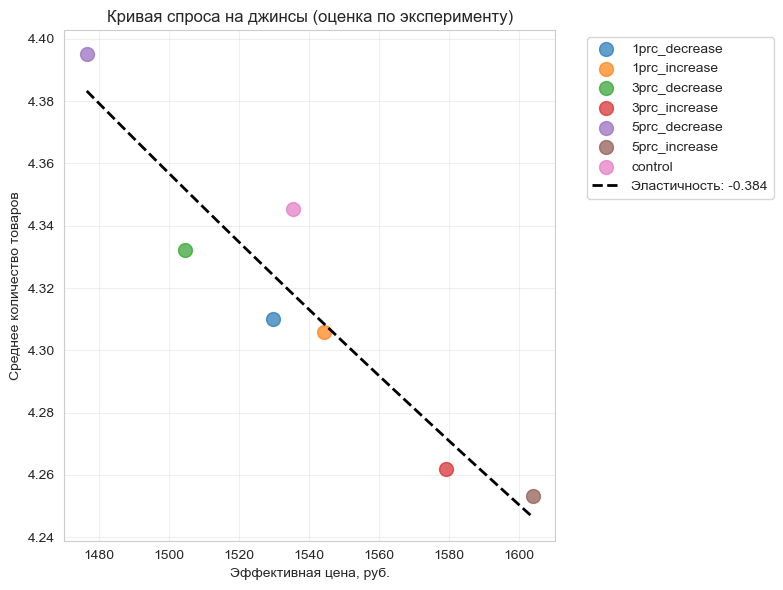

In [207]:
plt.figure(figsize=(8, 6))

for grp in group_stats.index:
    plt.scatter(
        group_stats.loc[grp, 'effective_price'],
        group_stats.loc[grp, 'created_items_cnt'],
        s=100, label=grp, alpha=0.7
    )

# Линия тренда (лог-лог для эластичности)
import numpy as np
log_p = np.log(group_stats['effective_price'])
log_q = np.log(group_stats['created_items_cnt'])
slope, intercept = np.polyfit(log_p, log_q, 1)

# Плавная линия
p_grid = np.linspace(group_stats['effective_price'].min(), group_stats['effective_price'].max(), 100)
q_pred = np.exp(intercept) * p_grid**slope

plt.plot(p_grid, q_pred, 'k--', linewidth=2, label=f'Эластичность: {slope:.3f}')

plt.xlabel('Эффективная цена, руб.')
plt.ylabel('Среднее количество товаров')
plt.title('Кривая спроса на джинсы (оценка по эксперименту)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Итоговая оценка эластичности спроса: -0.384. Снижение цены на 1% увеличивает количество покупок только на 0.38%. Покупатели джинсов почти не реагируют на изменение цены — они покупают джинсы, когда нужно, а не потому что стало дешевле

#### Вывод
Поскольку спрос неэластичен (−0.384), снижение цены не окупится: если мы снизим цену на 10%, количество вырастет только на 3.8%, и общая выручка упадёт. Поэтому СПП в категории «Джинсы» неэффективен — лучше держать текущий уровень или даже снизить скидки.

## Общий эффект эксперимента

In [212]:
total_users = len(result)
buyers_count = (result['sales_rub'] > 0).sum()
non_buyers_count = total_users - buyers_count

print(f"Всего пользователей в эксперименте: {total_users:,}")
print(f"  Выкупили товар: {buyers_count:,} ({buyers_count/total_users*100:.1f}%)")
print(f"  Не выкупили: {non_buyers_count:,} ({non_buyers_count/total_users*100:.1f}%)")
print(f"Общая выручка: {result['sales_rub'].sum():,.0f} руб")
print(f"Общие затраты на СПП: {result['spp_rub'].sum():,.0f} руб")
print(f"Чистая прибыль (выручка - СПП): {result['sales_rub'].sum() - result['spp_rub'].sum():,.0f} руб")

Всего пользователей в эксперименте: 267,771
  Выкупили товар: 188,557 (70.4%)
  Не выкупили: 79,214 (29.6%)
Общая выручка: 434,100,292 руб
Общие затраты на СПП: 724,758,863 руб
Чистая прибыль (выручка - СПП): -290,658,571 руб


In [213]:
control = result[result['grp'] == 'control'].copy()
test_all = result[result['grp'] != 'control'].copy()

# Ключевые метрики для сравнения
metrics = {
    'Выручка на пользователя (руб)': ('sales_rub', 'mean'),
    'Конверсия в выкуп (%)': ('sales_rub', lambda x: (x > 0).mean() * 100),
    'Средний чек (среди купивших, руб)': ('sales_rub', lambda x: x[x > 0].mean()),
    'Затраты на СПП на пользователя (руб)': ('spp_rub', 'mean'),
    'Количество товаров в заказе': ('created_items_cnt', 'mean'),
    'Средний процент скидки (%)': ('spp_pct', lambda x: x.mean() * 100)}
comparison = []
for metric_name, (col, agg_func) in metrics.items():
    if callable(agg_func):
        control_val = agg_func(control[col])
        test_val = agg_func(test_all[col])
    else:
        control_val = control[col].agg(agg_func)
        test_val = test_all[col].agg(agg_func)
    
    abs_diff = test_val - control_val
    rel_diff = (abs_diff / control_val * 100) if control_val != 0 else np.nan
    
    # Статистическая значимость для выручки
    if col == 'sales_rub' and agg_func == 'mean':
        stat, p_value = stats.ttest_ind(control[col], test_all[col], equal_var=False)
        significant = "ДА" if p_value < 0.05 else "НЕТ"
    else:
        p_value = np.nan
        significant = "-"
    
    comparison.append({
        'Метрика': metric_name,
        'Контроль': round(control_val, 2),
        'Все тесты': round(test_val, 2),
        'Абс. изменение': round(abs_diff, 2),
        'Отн. изменение (%)': round(rel_diff, 2),
        'p-value': round(p_value, 4) if not np.isnan(p_value) else '-',
        'Статзначимо': significant
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

                             Метрика  Контроль  Все тесты  Абс. изменение  Отн. изменение (%) p-value Статзначимо
       Выручка на пользователя (руб)   1627.30    1620.13           -7.17               -0.44   0.502         НЕТ
               Конверсия в выкуп (%)     70.29      70.44            0.15                0.21       -           -
   Средний чек (среди купивших, руб)   2315.18    2300.06          -15.12               -0.65       -           -
Затраты на СПП на пользователя (руб)   2712.31    2705.69           -6.63               -0.24       -           -
         Количество товаров в заказе      4.35       4.31           -0.03               -0.80       -           -
          Средний процент скидки (%)     28.93      29.04            0.11                0.37       -           -


In [214]:
# Разбиваем пользователей на сегменты
result['segment'] = 'обычный'
result.loc[(result['sales_rub'] > 0) & (result['sales_rub'] > result['sales_rub'].quantile(0.9)), 'segment'] = 'крупный'
result.loc[result['sales_rub'] == 0, 'segment'] = 'нулевой'

segment_effect = result.groupby(['grp', 'segment']).agg({
    'user_id': 'count',
    'sales_rub': 'mean',
    'spp_rub': 'mean'
}).round(2).reset_index()

pivot_segment = segment_effect.pivot_table(
    index='segment', 
    columns='grp', 
    values=['user_id', 'sales_rub', 'spp_rub'],
    aggfunc='first'
)

print("\nРаспределение пользователей по сегментам:")
seg_dist = result.groupby('segment')['user_id'].count()
print(seg_dist.to_string())

print("\nВыручка по сегментам в контроле vs тест:")
for seg in ['нулевой', 'обычный', 'крупный']:
    control_seg = segment_effect[(segment_effect['grp'] == 'control') & (segment_effect['segment'] == seg)]
    test_seg = segment_effect[(segment_effect['grp'] != 'control') & (segment_effect['segment'] == seg)]
    
    if not control_seg.empty and not test_seg.empty:
        rev_control = control_seg['sales_rub'].values[0]
        rev_test = test_seg['sales_rub'].mean()
        print(f"  {seg}: контроль={rev_control:.2f}, тест={rev_test:.2f}, разница={rev_test-rev_control:.2f}")


Распределение пользователей по сегментам:
segment
крупный     26771
нулевой     79214
обычный    161786

Выручка по сегментам в контроле vs тест:
  нулевой: контроль=0.00, тест=0.00, разница=0.00
  обычный: контроль=1752.53, тест=1757.05, разница=4.52
  крупный: контроль=5672.17, тест=5593.72, разница=-78.45


In [215]:
# Расчёт общей выручки при разных сценариях
total_rev_control = control['sales_rub'].sum()
total_rev_test = test_all['sales_rub'].sum()
total_rev_all = result['sales_rub'].sum()

# Нормализация с учётом размера групп (если бы группы были равны)
group_sizes = result.groupby('grp')['user_id'].count()
avg_group_size = group_sizes.mean()
weights = avg_group_size / group_sizes

weighted_rev_by_group = result.groupby('grp').apply(
    lambda x: x['sales_rub'].mean() * weights[x.name]
)
total_weighted_rev = weighted_rev_by_group.sum() * len(group_sizes)

print(f"Фактическая общая выручка: {total_rev_all:,.0f} руб")
print(f"Выручка контрольной группы: {total_rev_control:,.0f} руб")
print(f"Выручка тестовых групп: {total_rev_test:,.0f} руб")

print(f"\nС поправкой на неравномерность групп:")
print(f"  Взвешенная средняя выручка: {total_weighted_rev:,.0f} руб")
print(f"  Отклонение от факта: {((total_weighted_rev/total_rev_all)-1)*100:.2f}%")

Фактическая общая выручка: 434,100,292 руб
Выручка контрольной группы: 62,498,257 руб
Выручка тестовых групп: 371,602,035 руб

С поправкой на неравномерность групп:
  Взвешенная средняя выручка: 79,515 руб
  Отклонение от факта: -99.98%


In [216]:
# Берём MDE из ранее рассчитанных значений
mde_value = mde_boot
mde_rel = (mde_value / control['sales_rub'].mean()) * 100

# Фактический эффект (разница между лучшей группой и контролем)
best_group_rev = result.groupby('grp')['sales_rub'].mean().max()
best_group_name = result.groupby('grp')['sales_rub'].mean().idxmax()
effect_best = best_group_rev - control['sales_rub'].mean()
effect_best_rel = (effect_best / control['sales_rub'].mean()) * 100

# Средний эффект по всем тестовым группам
avg_test_rev = test_all.groupby('grp')['sales_rub'].mean().mean()
effect_avg = avg_test_rev - control['sales_rub'].mean()
effect_avg_rel = (effect_avg / control['sales_rub'].mean()) * 100

print(f"MDE (минимально обнаружимый эффект): {mde_value:.2f} руб ({mde_rel:.2f}%)")
print(f"\nФактические эффекты:")
print(f"  Лучшая группа ({best_group_name}): +{effect_best:.2f} руб ({effect_best_rel:.2f}%)")
print(f"  Средний по тесту: +{effect_avg:.2f} руб ({effect_avg_rel:.2f}%)")

if effect_best > mde_value:
    print(f"\n✓ Эффект лучшей группы ПРЕВЫШАЕТ MDE")
else:
    print(f"\n✗ Эффект лучшей группы НИЖЕ MDE")

MDE (минимально обнаружимый эффект): 31.16 руб (1.91%)

Фактические эффекты:
  Лучшая группа (5prc_increase): +24.07 руб (1.48%)
  Средний по тесту: +-6.76 руб (-0.42%)

✗ Эффект лучшей группы НИЖЕ MDE


In [217]:
final_summary = pd.DataFrame({
    'Показатель': [
        'Общая выручка эксперимента',
        'Общие затраты на СПП',
        'Чистый финансовый результат',
        'ROI эксперимента (общий)',
        'Средняя выручка (контроль)',
        'Средняя выручка (тест)',
        'Разница (тест - контроль)',
        'Лучшая группа',
        'Макс. прирост выручки',
        'MDE',
        'Эластичность спроса'
    ],
    'Значение': [
        f"{result['sales_rub'].sum():,.0f} руб",
        f"{result['spp_rub'].sum():,.0f} руб",
        f"{(result['sales_rub'].sum() - result['spp_rub'].sum()):,.0f} руб",
        f"{(result['sales_rub'].sum()/result['spp_rub'].sum() - 1)*100:.1f}%",
        f"{control['sales_rub'].mean():.2f} руб",
        f"{test_all['sales_rub'].mean():.2f} руб",
        f"{test_all['sales_rub'].mean() - control['sales_rub'].mean():.2f} руб",
        best_group_name,
        f"+{effect_best:.2f} руб ({effect_best_rel:.2f}%)",
        f"{mde_value:.2f} руб",
        "-0.384 (неэластичный)"
    ]
})

print(final_summary.to_string(index=False))

                 Показатель              Значение
 Общая выручка эксперимента       434,100,292 руб
       Общие затраты на СПП       724,758,863 руб
Чистый финансовый результат      -290,658,571 руб
   ROI эксперимента (общий)                -40.1%
 Средняя выручка (контроль)           1627.30 руб
     Средняя выручка (тест)           1620.13 руб
  Разница (тест - контроль)             -7.17 руб
              Лучшая группа         5prc_increase
      Макс. прирост выручки    +24.07 руб (1.48%)
                        MDE             31.16 руб
        Эластичность спроса -0.384 (неэластичный)
